In [1]:
# ============================================================
# CELL 1 — IMPORTS + GLOBAL CONFIGURATION
# ============================================================

import os
import gc
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import torch

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

DATA_ROOT = Path(
    "/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface"
)

# ------------------------------------------------------------
# Experimental protocol
# ------------------------------------------------------------

N_ENROLL_IDENTITIES = 60_000

ENROLL_IMAGES_PER_ID = 1
GENUINE_QUERIES_PER_ID = 2
IMPOSTOR_QUERIES_PER_ID = 2

# Enrollment identity therefore needs:
# 1 enrollment image + 2 independent genuine query images
MIN_IMAGES_ENROLLED_ID = (
    ENROLL_IMAGES_PER_ID +
    GENUINE_QUERIES_PER_ID
)

MIN_IMAGES_IMPOSTOR_ID = IMPOSTOR_QUERIES_PER_ID

# ------------------------------------------------------------
# Working directory
# ------------------------------------------------------------

WORK_DIR = Path("/kaggle/working/ms1mv2_hbf")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("MS1MV2 → PCA → ITQ → HBF EXPERIMENT")
print("=" * 80)

print("Dataset root :", DATA_ROOT)
print("Exists       :", DATA_ROOT.exists())

print("\nPyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
    print(
        "GPU memory   :",
        round(
            torch.cuda.get_device_properties(0).total_memory /
            1024**3,
            2
        ),
        "GB"
    )

print("\nEnrollment identities :", N_ENROLL_IDENTITIES)
print("Enrollment image / ID :", ENROLL_IMAGES_PER_ID)
print("Genuine queries / ID  :", GENUINE_QUERIES_PER_ID)
print("Impostor queries / ID :", IMPOSTOR_QUERIES_PER_ID)

assert DATA_ROOT.exists(), (
    f"Dataset path does not exist:\n{DATA_ROOT}"
)

print("\nCell 1 completed successfully.")

MS1MV2 → PCA → ITQ → HBF EXPERIMENT
Dataset root : /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface
Exists       : True

PyTorch      : 2.10.0+cu128
CUDA         : True
GPU          : Tesla T4
GPU memory   : 14.56 GB

Enrollment identities : 60000
Enrollment image / ID : 1
Genuine queries / ID  : 2
Impostor queries / ID : 2

Cell 1 completed successfully.


In [2]:
# ============================================================
# CELL 2 — FIND IDENTITY DIRECTORIES
# ============================================================

identity_dirs = [
    entry
    for entry in os.scandir(DATA_ROOT)
    if entry.is_dir()
]

print("Number of identity folders:", len(identity_dirs))

# Show a few examples
for entry in identity_dirs[:10]:
    print(entry.name, "->", entry.path)

assert len(identity_dirs) > N_ENROLL_IDENTITIES, (
    "Not enough identities for the requested 60,000-ID watchlist."
)

print("\nCell 2 completed successfully.")

Number of identity folders: 85742
72094 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/72094
78403 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/78403
10706 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/10706
82428 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/82428
58740 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/58740
61273 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/61273
23910 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/23910
70993 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/70993
46474 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/46474
75835 -> /kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/75835

Cell 2 completed successfully.


In [3]:
# ============================================================
# CELL 3 — COLLECT AT MOST 3 IMAGE PATHS PER IDENTITY
# ============================================================

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png"
}

MAX_IMAGES_NEEDED_PER_ID = max(
    MIN_IMAGES_ENROLLED_ID,
    MIN_IMAGES_IMPOSTOR_ID
)

print(
    "Maximum images we need to inspect/store per identity:",
    MAX_IMAGES_NEEDED_PER_ID
)

identity_samples = {}

start = time.time()

for idx, identity_entry in enumerate(identity_dirs):

    identity = identity_entry.name
    selected_images = []

    try:
        with os.scandir(identity_entry.path) as it:

            for file_entry in it:

                if not file_entry.is_file():
                    continue

                suffix = Path(file_entry.name).suffix.lower()

                if suffix not in VALID_EXTENSIONS:
                    continue

                selected_images.append(file_entry.path)

                # CRITICAL:
                # stop once we have enough images.
                if len(selected_images) >= MAX_IMAGES_NEEDED_PER_ID:
                    break

    except Exception as e:
        print(
            f"Warning: could not read identity {identity}: {e}"
        )
        continue

    identity_samples[identity] = selected_images

    if (idx + 1) % 10_000 == 0:
        elapsed = time.time() - start

        print(
            f"Processed {idx + 1:,}/{len(identity_dirs):,} "
            f"identities | {elapsed:.1f}s"
        )

elapsed = time.time() - start

print("\nFinished.")
print("Identities inspected :", len(identity_samples))
print("Elapsed time         :", round(elapsed, 2), "sec")

Maximum images we need to inspect/store per identity: 3
Processed 10,000/85,742 identities | 7.8s
Processed 20,000/85,742 identities | 15.7s
Processed 30,000/85,742 identities | 23.6s
Processed 40,000/85,742 identities | 31.4s
Processed 50,000/85,742 identities | 39.2s
Processed 60,000/85,742 identities | 47.8s
Processed 70,000/85,742 identities | 55.9s
Processed 80,000/85,742 identities | 70.8s

Finished.
Identities inspected : 85742
Elapsed time         : 94.11 sec


In [4]:
# ============================================================
# CELL 4 — CHECK IMAGE COUNTS
# ============================================================

image_count_distribution = Counter(
    len(paths)
    for paths in identity_samples.values()
)

print("Stored-image count distribution:")
print(image_count_distribution)

eligible_enrollment_ids = [
    identity
    for identity, paths in identity_samples.items()
    if len(paths) >= MIN_IMAGES_ENROLLED_ID
]

eligible_impostor_ids = [
    identity
    for identity, paths in identity_samples.items()
    if len(paths) >= MIN_IMAGES_IMPOSTOR_ID
]

print("\nEligible for enrollment + genuine queries:",
      f"{len(eligible_enrollment_ids):,}")

print(
    "Eligible for impostor queries:",
    f"{len(eligible_impostor_ids):,}"
)

assert len(eligible_enrollment_ids) >= N_ENROLL_IDENTITIES, (
    f"Only {len(eligible_enrollment_ids):,} identities have "
    f"{MIN_IMAGES_ENROLLED_ID}+ images. "
    f"Cannot select {N_ENROLL_IDENTITIES:,}."
)

print("\nCell 4 completed successfully.")

Stored-image count distribution:
Counter({3: 85617, 2: 125})

Eligible for enrollment + genuine queries: 85,617
Eligible for impostor queries: 85,742

Cell 4 completed successfully.


In [5]:
# ============================================================
# CELL 5 — SELECT 60,000 WATCHLIST IDENTITIES
# ============================================================

rng = random.Random(SEED)

eligible_enrollment_ids_sorted = sorted(
    eligible_enrollment_ids,
    key=lambda x: int(x) if x.isdigit() else x
)

enrolled_ids = rng.sample(
    eligible_enrollment_ids_sorted,
    N_ENROLL_IDENTITIES
)

enrolled_id_set = set(enrolled_ids)

print("Selected enrolled identities:",
      len(enrolled_ids))

print("Unique enrolled identities:",
      len(enrolled_id_set))

assert len(enrolled_id_set) == N_ENROLL_IDENTITIES

print("\nExample enrolled IDs:")
print(enrolled_ids[:20])

print("\nCell 5 completed successfully.")

Selected enrolled identities: 60000
Unique enrolled identities: 60000

Example enrolled IDs:
['83933', '14625', '3282', '36107', '32149', '29302', '18322', '13467', '71587', '11420', '77512', '55391', '4174', '3911', '12313', '28702', '30544', '66336', '79025', '3482']

Cell 5 completed successfully.


In [6]:
# ============================================================
# CELL 6 — CREATE ENROLLMENT + GENUINE QUERY SETS
# ============================================================

enrollment_records = []
genuine_query_records = []

rng = random.Random(SEED)

for identity in enrolled_ids:

    images = identity_samples[identity].copy()

    rng.shuffle(images)

    assert len(images) >= 3

    # --------------------------------------------------------
    # Enrollment
    # --------------------------------------------------------

    enrollment_records.append({
        "identity": identity,
        "image_path": images[0]
    })

    # --------------------------------------------------------
    # Genuine queries
    # --------------------------------------------------------

    genuine_query_records.append({
        "identity": identity,
        "image_path": images[1]
    })

    genuine_query_records.append({
        "identity": identity,
        "image_path": images[2]
    })

print("Enrollment templates :", len(enrollment_records))
print("Genuine queries      :", len(genuine_query_records))

assert len(enrollment_records) == 60_000
assert len(genuine_query_records) == 120_000

print("\nExample enrollment:")
print(enrollment_records[0])

print("\nExample genuine queries:")
print(genuine_query_records[:2])

print("\nCell 6 completed successfully.")

Enrollment templates : 60000
Genuine queries      : 120000

Example enrollment:
{'identity': '83933', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/83933/5702730.jpg'}

Example genuine queries:
[{'identity': '83933', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/83933/5702770.jpg'}, {'identity': '83933', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/83933/5702784.jpg'}]

Cell 6 completed successfully.


In [7]:
# ============================================================
# CELL 7 — CREATE OPEN-SET IMPOSTOR SET
# ============================================================

non_enrolled_ids = [
    identity
    for identity in eligible_impostor_ids
    if identity not in enrolled_id_set
]

non_enrolled_ids = sorted(
    non_enrolled_ids,
    key=lambda x: int(x) if x.isdigit() else x
)

print(
    "Available non-enrolled identities:",
    f"{len(non_enrolled_ids):,}"
)

impostor_query_records = []

rng = random.Random(SEED + 1)

for identity in non_enrolled_ids:

    images = identity_samples[identity].copy()

    rng.shuffle(images)

    n_take = min(
        IMPOSTOR_QUERIES_PER_ID,
        len(images)
    )

    for image_path in images[:n_take]:

        impostor_query_records.append({
            "identity": identity,
            "image_path": image_path
        })

print(
    "Non-enrolled identities:",
    f"{len(non_enrolled_ids):,}"
)

print(
    "Total impostor queries:",
    f"{len(impostor_query_records):,}"
)

print("\nExample impostor queries:")
print(impostor_query_records[:5])

print("\nCell 7 completed successfully.")

Available non-enrolled identities: 25,742
Non-enrolled identities: 25,742
Total impostor queries: 51,484

Example impostor queries:
[{'identity': '0', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/0/89.jpg'}, {'identity': '0', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/0/56.jpg'}, {'identity': '2', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/2/212.jpg'}, {'identity': '2', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/2/208.jpg'}, {'identity': '9', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/9/682.jpg'}]

Cell 7 completed successfully.


In [8]:
# ============================================================
# CELL 8 — LEAKAGE CHECK
# ============================================================

enrollment_ids_check = {
    x["identity"]
    for x in enrollment_records
}

genuine_ids_check = {
    x["identity"]
    for x in genuine_query_records
}

impostor_ids_check = {
    x["identity"]
    for x in impostor_query_records
}

print(
    "Enrollment identities:",
    len(enrollment_ids_check)
)

print(
    "Genuine-query identities:",
    len(genuine_ids_check)
)

print(
    "Impostor identities:",
    len(impostor_ids_check)
)

assert enrollment_ids_check == genuine_ids_check

assert len(
    enrollment_ids_check.intersection(
        impostor_ids_check
    )
) == 0

print("\n✓ Genuine IDs are enrolled.")
print("✓ Impostor IDs are NOT enrolled.")
print("✓ No identity leakage.")

# Also ensure enrollment images are not reused as queries

enrollment_paths = {
    x["image_path"]
    for x in enrollment_records
}

genuine_paths = {
    x["image_path"]
    for x in genuine_query_records
}

impostor_paths = {
    x["image_path"]
    for x in impostor_query_records
}

assert enrollment_paths.isdisjoint(genuine_paths)
assert enrollment_paths.isdisjoint(impostor_paths)

print("✓ Enrollment images are not reused as query images.")

print("\nCell 8 completed successfully.")

Enrollment identities: 60000
Genuine-query identities: 60000
Impostor identities: 25742

✓ Genuine IDs are enrolled.
✓ Impostor IDs are NOT enrolled.
✓ No identity leakage.
✓ Enrollment images are not reused as query images.

Cell 8 completed successfully.


In [9]:
# ============================================================
# CELL 9 — FINAL PROTOCOL SUMMARY
# ============================================================

print("=" * 80)
print("FINAL MS1MV2 EXPERIMENTAL PROTOCOL")
print("=" * 80)

print(
    f"Watchlist identities       : "
    f"{len(enrollment_ids_check):,}"
)

print(
    f"Enrollment templates       : "
    f"{len(enrollment_records):,}"
)

print(
    f"Genuine-query identities   : "
    f"{len(genuine_ids_check):,}"
)

print(
    f"Genuine queries            : "
    f"{len(genuine_query_records):,}"
)

print(
    f"Open-set impostor IDs      : "
    f"{len(impostor_ids_check):,}"
)

print(
    f"Impostor queries           : "
    f"{len(impostor_query_records):,}"
)

total_queries = (
    len(genuine_query_records) +
    len(impostor_query_records)
)

print(
    f"TOTAL QUERY OPERATIONS     : "
    f"{total_queries:,}"
)

print("=" * 80)

FINAL MS1MV2 EXPERIMENTAL PROTOCOL
Watchlist identities       : 60,000
Enrollment templates       : 60,000
Genuine-query identities   : 60,000
Genuine queries            : 120,000
Open-set impostor IDs      : 25,742
Impostor queries           : 51,484
TOTAL QUERY OPERATIONS     : 171,484


In [ ]:
# # ============================================================
# # CELL 10 — INSTALL ARCFACE DEPENDENCIES
# # ============================================================

# !pip install -q insightface onnxruntime-gpu

# print("Installation complete.")

In [ ]:
# # ============================================================
# # CELL 11 — GPU DIAGNOSTIC
# # ============================================================

# import torch
# import subprocess
# import onnxruntime as ort

# print("=" * 70)
# print("PYTORCH GPU CHECK")
# print("=" * 70)

# print("PyTorch version :", torch.__version__)
# print("CUDA available  :", torch.cuda.is_available())
# print("PyTorch CUDA    :", torch.version.cuda)

# if torch.cuda.is_available():
#     print("GPU             :", torch.cuda.get_device_name(0))
#     print(
#         "GPU memory      :",
#         round(
#             torch.cuda.get_device_properties(0).total_memory / 1024**3,
#             2
#         ),
#         "GB"
#     )

# print("\n" + "=" * 70)
# print("NVIDIA-SMI")
# print("=" * 70)

# subprocess.run(["nvidia-smi"])

# print("\n" + "=" * 70)
# print("ONNX RUNTIME")
# print("=" * 70)

# print("ONNX Runtime version :", ort.__version__)
# print("ORT device           :", ort.get_device())
# print("Providers            :", ort.get_available_providers())

In [ ]:
# # ============================================================
# # CELL 12 — GET OFFICIAL INSIGHTFACE ARCFACE PYTORCH CODE
# # ============================================================

# %cd /kaggle/working

# !rm -rf insightface_official
# !git clone -q --depth 1 \
#     https://github.com/deepinsight/insightface.git \
#     insightface_official

# ARCFACE_ROOT = (
#     "/kaggle/working/insightface_official/"
#     "recognition/arcface_torch"
# )

# print("ArcFace root:", ARCFACE_ROOT)

# import os
# print("Exists:", os.path.exists(ARCFACE_ROOT))

# assert os.path.exists(ARCFACE_ROOT)

# print("✓ Official InsightFace ArcFace PyTorch code ready.")

In [ ]:
# # ============================================================
# # CELL 13 — IMPORT OFFICIAL IRESNET-50
# # ============================================================

# import sys
# import torch
# import numpy as np

# if ARCFACE_ROOT not in sys.path:
#     sys.path.insert(0, ARCFACE_ROOT)

# from backbones import get_model

# device = torch.device(
#     "cuda:0" if torch.cuda.is_available()
#     else "cpu"
# )

# print("Device:", device)

# # Create architecture ONLY.
# # No pretrained weights have been loaded yet.
# arcface = get_model(
#     "r50",
#     fp16=False
# )

# print(type(arcface))

# n_params = sum(
#     p.numel()
#     for p in arcface.parameters()
# )

# print(
#     "Parameters:",
#     f"{n_params:,}"
# )

# print("\nIMPORTANT:")
# print("Architecture created.")
# print("Pretrained weights NOT loaded yet.")

In [ ]:
# ============================================================
# CELL 15 — FIX ONNXRUNTIME GPU
# ============================================================

# !pip uninstall -y onnxruntime onnxruntime-gpu
# !pip install -q onnxruntime-gpu==1.23.2

# print("\nInstallation complete.")
# print("NOW RESTART THE KAGGLE SESSION.")

In [ ]:
# # ============================================================
# # GPU / ONNX CHECK AFTER RESTART
# # ============================================================

# import torch
# import onnxruntime as ort

# print("PyTorch CUDA:", torch.cuda.is_available())

# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))

# print("ORT version:", ort.__version__)
# print("ORT device :", ort.get_device())
# print("Providers  :", ort.get_available_providers())

In [ ]:
# # ============================================================
# # FIX ONNXRUNTIME — FORCE GPU BUILD
# # ============================================================

# import sys
# import subprocess

# print("Python executable:")
# print(sys.executable)

# print("\n--- BEFORE ---")
# subprocess.run([
#     sys.executable, "-m", "pip", "show", "onnxruntime"
# ])

# subprocess.run([
#     sys.executable, "-m", "pip", "show", "onnxruntime-gpu"
# ])

# print("\nRemoving BOTH possible installations...")

# subprocess.run([
#     sys.executable, "-m", "pip",
#     "uninstall", "-y",
#     "onnxruntime",
#     "onnxruntime-gpu"
# ])

# print("\nInstalling GPU build with CUDA/cuDNN dependencies...")

# subprocess.run([
#     sys.executable, "-m", "pip",
#     "install",
#     "--no-cache-dir",
#     "--force-reinstall",
#     "onnxruntime-gpu[cuda,cudnn]==1.30.0"
# ])

# print("\n--- AFTER INSTALL ---")

# subprocess.run([
#     sys.executable, "-m", "pip",
#     "show", "onnxruntime-gpu"
# ])

# print("\nINSTALLATION FINISHED.")
# print("NOW RESTART THE KAGGLE SESSION.")
# print("Do NOT test onnxruntime in this same session.")

In [10]:
# # ============================================================
# # FIX ONNXRUNTIME — FORCE GPU BUILD
# # ============================================================

# import sys
# import subprocess

# print("Python executable:")
# print(sys.executable)

# print("\n--- BEFORE ---")
# subprocess.run([
#     sys.executable, "-m", "pip", "show", "onnxruntime"
# ])

# subprocess.run([
#     sys.executable, "-m", "pip", "show", "onnxruntime-gpu"
# ])

# print("\nRemoving BOTH possible installations...")

# subprocess.run([
#     sys.executable, "-m", "pip",
#     "uninstall", "-y",
#     "onnxruntime",
#     "onnxruntime-gpu"
# ])

# print("\nInstalling GPU build with CUDA/cuDNN dependencies...")

# subprocess.run([
#     sys.executable, "-m", "pip",
#     "install",
#     "--no-cache-dir",
#     "--force-reinstall",
#     "onnxruntime-gpu[cuda,cudnn]==1.30.0"
# ])

# print("\n--- AFTER INSTALL ---")

# subprocess.run([
#     sys.executable, "-m", "pip",
#     "show", "onnxruntime-gpu"
# ])

# print("\nINSTALLATION FINISHED.")
# print("NOW RESTART THE KAGGLE SESSION.")
# print("Do NOT test onnxruntime in this same session.")

Python executable:
/usr/bin/python3

--- BEFORE ---


Name: onnxruntime-gpu
Version: 1.30.0
Summary: ONNX Runtime is a runtime accelerator for Machine Learning models
Home-page: https://onnxruntime.ai
Author: Microsoft Corporation
Author-email: onnxruntime@microsoft.com
License: MIT License
Location: /usr/local/lib/python3.12/dist-packages
Requires: flatbuffers, numpy, packaging, protobuf
Required-by: 

Removing BOTH possible installations...


Found existing installation: onnxruntime-gpu 1.30.0
Uninstalling onnxruntime-gpu-1.30.0:
  Successfully uninstalled onnxruntime-gpu-1.30.0

Installing GPU build with CUDA/cuDNN dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 244.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 313.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 MB 312.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 327.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.8/536.8 MB 310.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.8/161.8 MB 302.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 MB 230.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 371.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 230.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.3/439.3 MB 331.3 MB/s eta 0:00:00
   

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
insightface 2.0 requires onnxruntime, which is not installed.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.5.3 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is 


--- AFTER INSTALL ---
Name: onnxruntime-gpu
Version: 1.30.0
Summary: ONNX Runtime is a runtime accelerator for Machine Learning models
Home-page: https://onnxruntime.ai
Author: Microsoft Corporation
Author-email: onnxruntime@microsoft.com
License: MIT License
Location: /usr/local/lib/python3.12/dist-packages
Requires: flatbuffers, numpy, packaging, protobuf
Required-by: 

INSTALLATION FINISHED.
NOW RESTART THE KAGGLE SESSION.
Do NOT test onnxruntime in this same session.


In [11]:
# ============================================================
# ONNXRUNTIME GPU VERIFICATION
# ============================================================

# IMPORTANT: import torch FIRST.
# This preloads PyTorch's CUDA/cuDNN libraries.

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

import onnxruntime as ort

# Explicitly preload CUDA/cuDNN libraries.
try:
    ort.preload_dlls()
except Exception as e:
    print("preload_dlls message:", e)

print("\nONNX Runtime:", ort.__version__)
print("ORT device:", ort.get_device())
print("Providers:")

for provider in ort.get_available_providers():
    print("  ", provider)

PyTorch: 2.10.0+cu128
CUDA available: True
PyTorch CUDA: 12.8
GPU: Tesla T4

ONNX Runtime: 1.30.0
ORT device: GPU
Providers:
   TensorrtExecutionProvider
   CUDAExecutionProvider
   CPUExecutionProvider


In [12]:
# ============================================================
# CELL 12 — INSTALL INSIGHTFACE ONLY
# ============================================================

import sys
import subprocess

subprocess.run([
    sys.executable, "-m", "pip",
    "install", "-q",
    "--no-deps",
    "insightface"
])

print("✓ InsightFace installed without modifying ONNX Runtime.")

✓ InsightFace installed without modifying ONNX Runtime.


In [13]:
import insightface

print("InsightFace:", insightface.__version__)

InsightFace: 2.0


In [14]:
# ============================================================
# CELL 13 — LOAD PRETRAINED INSIGHTFACE MODEL
# ============================================================

from insightface.app import FaceAnalysis
import onnxruntime as ort
import os

print("ORT providers:")
print(ort.get_available_providers())

assert "CUDAExecutionProvider" in ort.get_available_providers(), \
    "CUDAExecutionProvider disappeared."

MODEL_ROOT = "/kaggle/working/insightface_models"

app = FaceAnalysis(
    name="buffalo_l",
    root=MODEL_ROOT,
    providers=[
        "CUDAExecutionProvider",
        "CPUExecutionProvider"
    ]
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("\n✓ buffalo_l loaded.")

ORT providers:
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
download_path: /kaggle/working/insightface_models/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 113312.63KB/s]



✓ buffalo_l loaded.


In [15]:
# ============================================================
# CELL 14 — GET RECOGNITION MODEL
# ============================================================

recognition_model = None

print("=" * 70)
print("MODELS LOADED BY INSIGHTFACE")
print("=" * 70)

for task_name, model in app.models.items():

    print(
        f"{task_name:20s}",
        type(model).__name__
    )

    if task_name == "recognition":
        recognition_model = model


assert recognition_model is not None, \
    "Recognition model was not found."

print("\nRecognition model:")
print(type(recognition_model))

print("\nInput size:")
print(recognition_model.input_size)

print("\nInput mean/std:")
print(
    recognition_model.input_mean,
    recognition_model.input_std
)

print("\nONNX providers actually used:")
print(
    recognition_model.session.get_providers()
)

MODELS LOADED BY INSIGHTFACE
landmark_3d_68       Landmark
landmark_2d_106      Landmark
detection            SCRFD
genderage            Attribute
recognition          ArcFaceONNX

Recognition model:
<class 'insightface.model_zoo.arcface_onnx.ArcFaceONNX'>

Input size:
(112, 112)

Input mean/std:
127.5 127.5

ONNX providers actually used:
['CUDAExecutionProvider', 'CPUExecutionProvider']


In [16]:
# ============================================================
# CELL 15 — INSPECT RECOGNITION MODEL
# ============================================================

session = recognition_model.session

input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()[0]

print("Input name :", input_meta.name)
print("Input shape:", input_meta.shape)
print("Input type :", input_meta.type)

print()

print("Output name :", output_meta.name)
print("Output shape:", output_meta.shape)
print("Output type :", output_meta.type)

Input name : input.1
Input shape: ['None', 3, 112, 112]
Input type : tensor(float)

Output name : 683
Output shape: [1, 512]
Output type : tensor(float)


In [20]:
# Check the actual structure of our enrollment records

print("Type:", type(enrollment_records))
print("Number of records:", len(enrollment_records))

print("\nFirst record:")
print(enrollment_records[0])

print("\nAvailable keys:")
print(enrollment_records[0].keys())

Type: <class 'list'>
Number of records: 60000

First record:
{'identity': '83933', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/83933/5702730.jpg'}

Available keys:
dict_keys(['identity', 'image_path'])


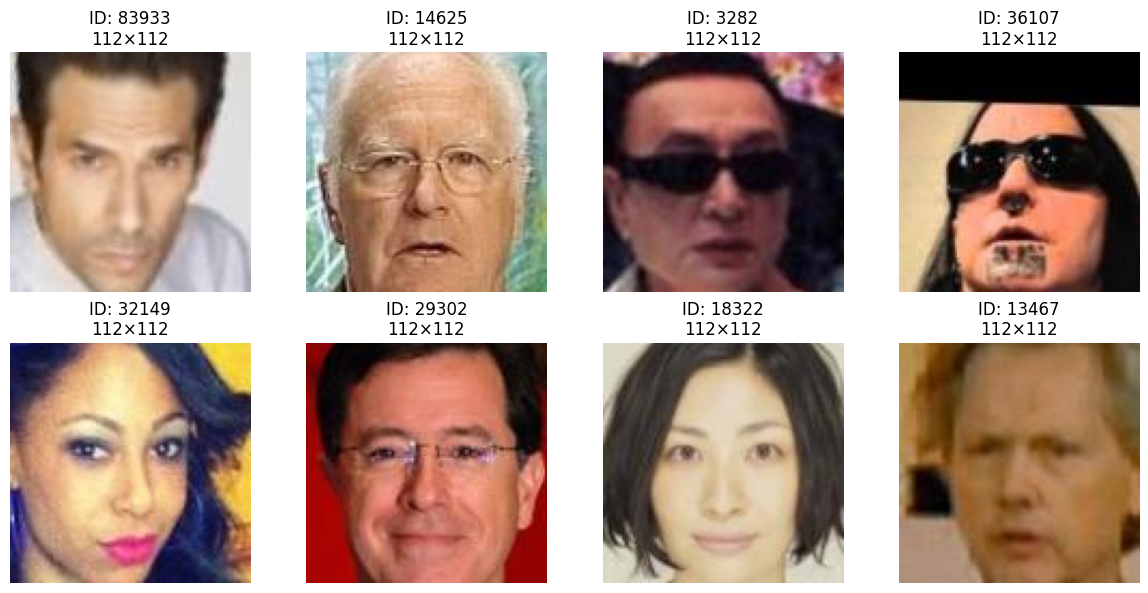

In [21]:
# ============================================================
# CELL 16 — VISUALIZE MS1MV2 ENROLLMENT SAMPLES
# ============================================================

import cv2
import matplotlib.pyplot as plt

ID_KEY = "identity"
PATH_KEY = "image_path"

fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6)
)

axes = axes.ravel()

for i in range(8):

    record = enrollment_records[i]

    identity = record[ID_KEY]
    img_path = record[PATH_KEY]

    img = cv2.imread(img_path)

    if img is None:
        raise RuntimeError(
            f"Could not read image: {img_path}"
        )

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(img_rgb)

    axes[i].set_title(
        f"ID: {identity}\n"
        f"{img.shape[1]}×{img.shape[0]}"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 17 — ARCFACE BATCH PREPROCESSING
# ============================================================

import numpy as np
import cv2


def preprocess_arcface_batch(image_paths):

    images = []

    target_size = tuple(
        recognition_model.input_size
    )

    for path in image_paths:

        img = cv2.imread(str(path))

        if img is None:
            raise RuntimeError(
                f"Failed to read image: {path}"
            )

        if (
            img.shape[1] != target_size[0]
            or img.shape[0] != target_size[1]
        ):
            img = cv2.resize(
                img,
                target_size,
                interpolation=cv2.INTER_LINEAR
            )

        images.append(img)

    blob = cv2.dnn.blobFromImages(
        images,
        scalefactor=1.0 / recognition_model.input_std,
        size=target_size,
        mean=(
            recognition_model.input_mean,
            recognition_model.input_mean,
            recognition_model.input_mean
        ),
        swapRB=True
    )

    return blob.astype(np.float32)


print("Target size :", recognition_model.input_size)
print("Input mean  :", recognition_model.input_mean)
print("Input std   :", recognition_model.input_std)

Target size : (112, 112)
Input mean  : 127.5
Input std   : 127.5


In [24]:
# ============================================================
# CELL 18 — 32-IMAGE ARCFACE GPU SANITY TEST
# ============================================================

import time
import numpy as np


# ------------------------------------------------------------
# Select 32 enrollment images
# ------------------------------------------------------------

test_paths = [
    r["image_path"]
    for r in enrollment_records[:32]
]

assert len(test_paths) == 32


# ------------------------------------------------------------
# Preprocess
# ------------------------------------------------------------

blob = preprocess_arcface_batch(
    test_paths
)

print("=" * 70)
print("ARCFACE GPU SANITY TEST")
print("=" * 70)

print("Input batch shape:", blob.shape)
print("Input dtype      :", blob.dtype)


# ------------------------------------------------------------
# ONNX input
# ------------------------------------------------------------

session = recognition_model.session

input_name = (
    session
    .get_inputs()[0]
    .name
)


# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

for _ in range(3):

    _ = session.run(
        None,
        {
            input_name: blob[:8]
        }
    )


# ------------------------------------------------------------
# Timed inference
# ------------------------------------------------------------

t0 = time.time()

outputs = session.run(
    None,
    {
        input_name: blob
    }
)

elapsed = time.time() - t0


raw_embeddings = outputs[0]


print("\nRaw embedding shape:",
      raw_embeddings.shape)

print(
    "Inference time:",
    f"{elapsed:.4f} sec"
)

print(
    "Throughput:",
    f"{len(test_paths) / elapsed:.2f} images/sec"
)


# ------------------------------------------------------------
# Validate embedding
# ------------------------------------------------------------

assert raw_embeddings.ndim == 2

assert raw_embeddings.shape[0] == 32

assert raw_embeddings.shape[1] == 512, (
    f"Expected 512-D embeddings, "
    f"got {raw_embeddings.shape}"
)


if not np.isfinite(raw_embeddings).all():
    raise RuntimeError(
        "NaN/Inf detected in ArcFace embeddings."
    )


# ------------------------------------------------------------
# L2 normalization
# ------------------------------------------------------------

embedding_norms = np.linalg.norm(
    raw_embeddings,
    axis=1,
    keepdims=True
)

embeddings = (
    raw_embeddings /
    np.clip(
        embedding_norms,
        1e-12,
        None
    )
)


normalized_norms = np.linalg.norm(
    embeddings,
    axis=1
)


print("\nNormalized embedding shape:",
      embeddings.shape)

print(
    "Norm min:",
    f"{normalized_norms.min():.6f}"
)

print(
    "Norm max:",
    f"{normalized_norms.max():.6f}"
)

print(
    "Norm mean:",
    f"{normalized_norms.mean():.6f}"
)


print("\nONNX providers:")

for p in session.get_providers():
    print(" ", p)


print("\n✓ 32-image ArcFace test completed.")

ARCFACE GPU SANITY TEST
Input batch shape: (32, 3, 112, 112)
Input dtype      : float32

Raw embedding shape: (32, 512)
Inference time: 0.2044 sec
Throughput: 156.58 images/sec

Normalized embedding shape: (32, 512)
Norm min: 1.000000
Norm max: 1.000000
Norm mean: 1.000000

ONNX providers:
  CUDAExecutionProvider
  CPUExecutionProvider

✓ 32-image ArcFace test completed.


GENUINE QUERY RECORD STRUCTURE
Number of genuine queries: 120000
First genuine record:
{'identity': '83933', 'image_path': '/kaggle/input/datasets/yakhyokhuja/ms1m-arcface-dataset/ms1m-arcface/83933/5702770.jpg'}

Identities tested: 128
Enrollment/query identical paths: 0

Extracting enrollment embeddings...
Enrollment embeddings: (128, 512)
Extracting genuine-query embeddings...
Query embeddings: (128, 512)

ARCFACE SIMILARITY SANITY CHECK

GENUINE
Mean   : 0.5978
Median : 0.5993
Std    : 0.1669
Min    : 0.0864
Max    : 0.9766

IMPOSTOR
Mean   : 0.0010
Median : 0.0034
Std    : 0.0555
Min    : -0.1315
Max    : 0.1619

Mean genuine-impostor gap: 0.5969
Fraction genuine > paired impostor: 1.0000


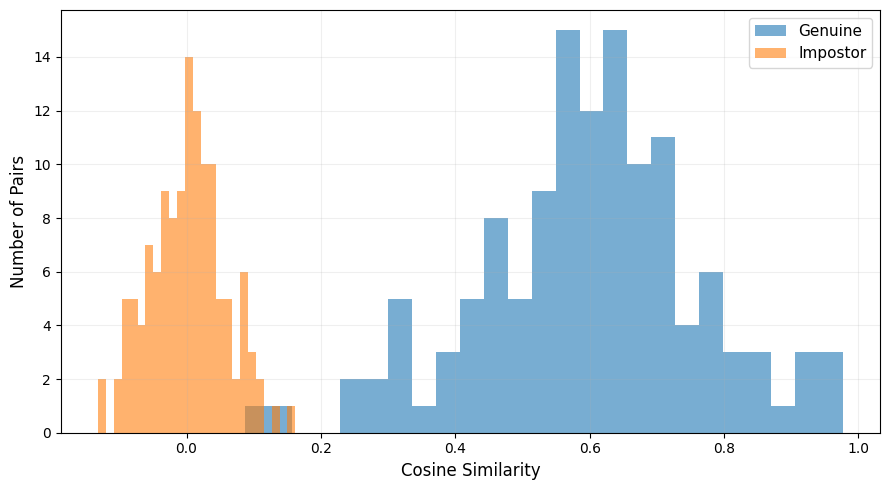

In [25]:
# ============================================================
# CELL 19 — GENUINE VS IMPOSTOR ARCFACE SANITY TEST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper: embed paths
# ------------------------------------------------------------

def arcface_embed_paths(image_paths):

    blob = preprocess_arcface_batch(image_paths)

    session = recognition_model.session
    input_name = session.get_inputs()[0].name

    raw = session.run(
        None,
        {input_name: blob}
    )[0]

    # L2 normalize
    raw = raw.astype(np.float32)

    norms = np.linalg.norm(
        raw,
        axis=1,
        keepdims=True
    )

    emb = raw / np.clip(
        norms,
        1e-12,
        None
    )

    return emb


# ------------------------------------------------------------
# Inspect genuine-query record structure
# ------------------------------------------------------------

print("=" * 70)
print("GENUINE QUERY RECORD STRUCTURE")
print("=" * 70)

print("Number of genuine queries:",
      len(genuine_query_records))

print("First genuine record:")
print(genuine_query_records[0])

print()


# ------------------------------------------------------------
# Build identity -> genuine query path mapping
# ------------------------------------------------------------

genuine_by_id = {}

for record in genuine_query_records:

    identity = str(record["identity"])

    # Automatically handle likely path field names
    if "image_path" in record:
        path = record["image_path"]

    elif "query_path" in record:
        path = record["query_path"]

    elif "path" in record:
        path = record["path"]

    else:
        raise KeyError(
            f"Cannot identify path field. "
            f"Keys = {record.keys()}"
        )

    genuine_by_id.setdefault(
        identity,
        []
    ).append(path)


# ------------------------------------------------------------
# Select identities
# ------------------------------------------------------------

N_TEST_IDS = 128

selected_enrollment = []

for record in enrollment_records:

    identity = str(record["identity"])

    if (
        identity in genuine_by_id
        and len(genuine_by_id[identity]) >= 1
    ):
        selected_enrollment.append(record)

    if len(selected_enrollment) == N_TEST_IDS:
        break


assert len(selected_enrollment) == N_TEST_IDS


enroll_paths = [
    r["image_path"]
    for r in selected_enrollment
]

enroll_ids = [
    str(r["identity"])
    for r in selected_enrollment
]


genuine_paths = [
    genuine_by_id[identity][0]
    for identity in enroll_ids
]


print(
    "Identities tested:",
    len(enroll_ids)
)


# ------------------------------------------------------------
# Verify images are different files
# ------------------------------------------------------------

same_path_count = sum(
    e == q
    for e, q in zip(
        enroll_paths,
        genuine_paths
    )
)

print(
    "Enrollment/query identical paths:",
    same_path_count
)

assert same_path_count == 0, (
    "Enrollment image and genuine query "
    "must be different files."
)


# ------------------------------------------------------------
# Extract embeddings
# ------------------------------------------------------------

print("\nExtracting enrollment embeddings...")

E = arcface_embed_paths(
    enroll_paths
)

print(
    "Enrollment embeddings:",
    E.shape
)


print("Extracting genuine-query embeddings...")

Q = arcface_embed_paths(
    genuine_paths
)

print(
    "Query embeddings:",
    Q.shape
)


# ------------------------------------------------------------
# Genuine cosine similarity
#
# E[i] and Q[i] belong to SAME identity
# ------------------------------------------------------------

genuine_scores = np.sum(
    E * Q,
    axis=1
)


# ------------------------------------------------------------
# Impostor cosine similarity
#
# Circular shift guarantees different identity:
#
# E[i] vs Q[i+1]
# ------------------------------------------------------------

Q_impostor = np.roll(
    Q,
    shift=1,
    axis=0
)

impostor_ids = np.roll(
    np.array(enroll_ids),
    shift=1
)

assert np.all(
    np.array(enroll_ids)
    != impostor_ids
)

impostor_scores = np.sum(
    E * Q_impostor,
    axis=1
)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ARCFACE SIMILARITY SANITY CHECK")
print("=" * 70)

print("\nGENUINE")
print(
    f"Mean   : {genuine_scores.mean():.4f}"
)
print(
    f"Median : {np.median(genuine_scores):.4f}"
)
print(
    f"Std    : {genuine_scores.std():.4f}"
)
print(
    f"Min    : {genuine_scores.min():.4f}"
)
print(
    f"Max    : {genuine_scores.max():.4f}"
)


print("\nIMPOSTOR")
print(
    f"Mean   : {impostor_scores.mean():.4f}"
)
print(
    f"Median : {np.median(impostor_scores):.4f}"
)
print(
    f"Std    : {impostor_scores.std():.4f}"
)
print(
    f"Min    : {impostor_scores.min():.4f}"
)
print(
    f"Max    : {impostor_scores.max():.4f}"
)


gap = (
    genuine_scores.mean()
    - impostor_scores.mean()
)

print(
    "\nMean genuine-impostor gap:",
    f"{gap:.4f}"
)


# ------------------------------------------------------------
# Pairwise ordering sanity metric
# ------------------------------------------------------------

fraction_correct = np.mean(
    genuine_scores
    > impostor_scores
)

print(
    "Fraction genuine > paired impostor:",
    f"{fraction_correct:.4f}"
)


# ------------------------------------------------------------
# Distribution plot
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    genuine_scores,
    bins=25,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    impostor_scores,
    bins=25,
    alpha=0.6,
    label="Impostor"
)

plt.xlabel(
    "Cosine Similarity",
    fontsize=12
)

plt.ylabel(
    "Number of Pairs",
    fontsize=12
)

plt.legend(
    fontsize=11
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# CELL 20 — LOCK EXPERIMENTAL SETS
# ============================================================

from pathlib import Path
import numpy as np
import os

EMBED_DIR = Path(
    "/kaggle/working/ms1mv2_hbf/arcface_embeddings"
)

EMBED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Verify record structure
# ------------------------------------------------------------

for name, records in [
    ("Enrollment", enrollment_records),
    ("Genuine", genuine_query_records),
    ("Impostor", impostor_query_records)
]:
    assert len(records) > 0

    assert "identity" in records[0]
    assert "image_path" in records[0]

    print(
        f"{name:12s}: "
        f"{len(records):,} records"
    )


# ------------------------------------------------------------
# Lock paths / identities
# ------------------------------------------------------------

enrollment_paths = np.array(
    [r["image_path"] for r in enrollment_records],
    dtype=object
)

enrollment_ids = np.array(
    [str(r["identity"]) for r in enrollment_records]
)


genuine_paths = np.array(
    [r["image_path"] for r in genuine_query_records],
    dtype=object
)

genuine_ids = np.array(
    [str(r["identity"]) for r in genuine_query_records]
)


impostor_paths = np.array(
    [r["image_path"] for r in impostor_query_records],
    dtype=object
)

impostor_ids = np.array(
    [str(r["identity"]) for r in impostor_query_records]
)


print("\n" + "=" * 70)
print("LOCKED EXPERIMENT")
print("=" * 70)

print(
    f"Enrollment : {len(enrollment_paths):,}"
)

print(
    f"Genuine    : {len(genuine_paths):,}"
)

print(
    f"Impostor   : {len(impostor_paths):,}"
)

print(
    f"TOTAL      : "
    f"{len(enrollment_paths) + len(genuine_paths) + len(impostor_paths):,}"
)

Enrollment  : 60,000 records
Genuine     : 120,000 records
Impostor    : 51,484 records

LOCKED EXPERIMENT
Enrollment : 60,000
Genuine    : 120,000
Impostor   : 51,484
TOTAL      : 231,484


In [27]:
# ============================================================
# CELL 21 — SAVE IDENTITY ARRAYS
# ============================================================

np.save(
    EMBED_DIR / "enrollment_ids.npy",
    enrollment_ids
)

np.save(
    EMBED_DIR / "genuine_ids.npy",
    genuine_ids
)

np.save(
    EMBED_DIR / "impostor_ids.npy",
    impostor_ids
)

print("Saved identity arrays to:")
print(EMBED_DIR)

Saved identity arrays to:
/kaggle/working/ms1mv2_hbf/arcface_embeddings


In [28]:
# ============================================================
# CELL 22 — CHECKPOINTED ARCFACE EXTRACTION FUNCTION
# ============================================================

import json
import time
import gc
import numpy as np
from numpy.lib.format import open_memmap


EMBED_DIM = 512
BATCH_SIZE = 256


def extract_embeddings_checkpointed(
    image_paths,
    output_file,
    checkpoint_file,
    batch_size=BATCH_SIZE
):

    image_paths = list(image_paths)

    n = len(image_paths)

    output_file = Path(output_file)
    checkpoint_file = Path(checkpoint_file)

    # --------------------------------------------------------
    # Resume state
    # --------------------------------------------------------

    if (
        output_file.exists()
        and checkpoint_file.exists()
    ):

        mmap = np.load(
            output_file,
            mmap_mode="r+"
        )

        with open(
            checkpoint_file,
            "r"
        ) as f:
            state = json.load(f)

        start_idx = int(
            state["completed"]
        )

        print(
            f"Resuming from "
            f"{start_idx:,}/{n:,}"
        )

    else:

        mmap = open_memmap(
            output_file,
            mode="w+",
            dtype=np.float32,
            shape=(n, EMBED_DIM)
        )

        start_idx = 0

        state = {
            "completed": 0,
            "total": n
        }

        with open(
            checkpoint_file,
            "w"
        ) as f:
            json.dump(
                state,
                f
            )

        print(
            f"Starting new extraction: "
            f"{n:,} images"
        )


    assert mmap.shape == (
        n,
        EMBED_DIM
    )


    session = recognition_model.session

    input_name = (
        session
        .get_inputs()[0]
        .name
    )


    # --------------------------------------------------------
    # Extraction
    # --------------------------------------------------------

    t_start = time.time()

    for start in range(
        start_idx,
        n,
        batch_size
    ):

        end = min(
            start + batch_size,
            n
        )

        batch_paths = (
            image_paths[start:end]
        )

        blob = (
            preprocess_arcface_batch(
                batch_paths
            )
        )

        raw = session.run(
            None,
            {
                input_name: blob
            }
        )[0]

        raw = raw.astype(
            np.float32,
            copy=False
        )

        # L2 normalize
        norms = np.linalg.norm(
            raw,
            axis=1,
            keepdims=True
        )

        emb = raw / np.clip(
            norms,
            1e-12,
            None
        )

        # Safety checks
        if not np.isfinite(
            emb
        ).all():

            raise RuntimeError(
                f"NaN/Inf detected "
                f"in batch {start}:{end}"
            )

        mmap[start:end] = emb


        # ----------------------------------------------------
        # Flush every ~4096 images
        # ----------------------------------------------------

        if (
            end % 4096 < batch_size
            or end == n
        ):

            mmap.flush()

            state["completed"] = end

            with open(
                checkpoint_file,
                "w"
            ) as f:
                json.dump(
                    state,
                    f
                )


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            end % 4096 < batch_size
            or end == n
        ):

            elapsed = (
                time.time()
                - t_start
            )

            processed = (
                end
                - start_idx
            )

            rate = (
                processed
                / max(
                    elapsed,
                    1e-9
                )
            )

            remaining = (
                n - end
            )

            eta = (
                remaining
                / max(
                    rate,
                    1e-9
                )
            )

            print(
                f"{end:>8,}/{n:,} "
                f"| {rate:7.2f} img/s "
                f"| ETA {eta/60:6.1f} min"
            )


        del blob
        del raw
        del emb


    mmap.flush()

    del mmap

    gc.collect()


    # --------------------------------------------------------
    # Final validation
    # --------------------------------------------------------

    final = np.load(
        output_file,
        mmap_mode="r"
    )

    norms = np.linalg.norm(
        final,
        axis=1
    )

    print("\nCompleted:")
    print(output_file)

    print(
        "Shape:",
        final.shape
    )

    print(
        "Norm range:",
        float(norms.min()),
        "to",
        float(norms.max())
    )

    return output_file

In [29]:
# ============================================================
# CELL 23 — ENROLLMENT EMBEDDINGS
# ============================================================

enroll_embedding_file = (
    EMBED_DIR /
    "arcface_enrollment_512d.npy"
)

enroll_checkpoint = (
    EMBED_DIR /
    "arcface_enrollment_checkpoint.json"
)


extract_embeddings_checkpointed(
    enrollment_paths,
    enroll_embedding_file,
    enroll_checkpoint,
    batch_size=256
)

Starting new extraction: 60,000 images
   4,096/60,000 |  103.87 img/s | ETA    9.0 min
   8,192/60,000 |  103.16 img/s | ETA    8.4 min
  12,288/60,000 |  102.75 img/s | ETA    7.7 min
  16,384/60,000 |  102.85 img/s | ETA    7.1 min
  20,480/60,000 |  102.43 img/s | ETA    6.4 min
  24,576/60,000 |  102.10 img/s | ETA    5.8 min
  28,672/60,000 |  101.58 img/s | ETA    5.1 min
  32,768/60,000 |  101.17 img/s | ETA    4.5 min
  36,864/60,000 |  100.65 img/s | ETA    3.8 min
  40,960/60,000 |  100.31 img/s | ETA    3.2 min
  45,056/60,000 |  100.42 img/s | ETA    2.5 min
  49,152/60,000 |  100.55 img/s | ETA    1.8 min
  53,248/60,000 |  100.68 img/s | ETA    1.1 min
  57,344/60,000 |  100.78 img/s | ETA    0.4 min
  60,000/60,000 |  100.70 img/s | ETA    0.0 min

Completed:
/kaggle/working/ms1mv2_hbf/arcface_embeddings/arcface_enrollment_512d.npy
Shape: (60000, 512)
Norm range: 0.9999998807907104 to 1.0000001192092896


PosixPath('/kaggle/working/ms1mv2_hbf/arcface_embeddings/arcface_enrollment_512d.npy')

In [30]:
# ============================================================
# CELL 24 — GENUINE QUERY EMBEDDINGS
# ============================================================

genuine_embedding_file = (
    EMBED_DIR /
    "arcface_genuine_512d.npy"
)

genuine_checkpoint = (
    EMBED_DIR /
    "arcface_genuine_checkpoint.json"
)


extract_embeddings_checkpointed(
    genuine_paths,
    genuine_embedding_file,
    genuine_checkpoint,
    batch_size=256
)

Starting new extraction: 120,000 images
   4,096/120,000 |  107.38 img/s | ETA   18.0 min
   8,192/120,000 |  103.73 img/s | ETA   18.0 min
  12,288/120,000 |  104.48 img/s | ETA   17.2 min
  16,384/120,000 |  105.07 img/s | ETA   16.4 min
  20,480/120,000 |  102.79 img/s | ETA   16.1 min
  24,576/120,000 |   93.53 img/s | ETA   17.0 min
  28,672/120,000 |   94.21 img/s | ETA   16.2 min
  32,768/120,000 |   95.19 img/s | ETA   15.3 min
  36,864/120,000 |   96.25 img/s | ETA   14.4 min
  40,960/120,000 |   97.30 img/s | ETA   13.5 min
  45,056/120,000 |   98.07 img/s | ETA   12.7 min
  49,152/120,000 |   98.42 img/s | ETA   12.0 min
  53,248/120,000 |   97.73 img/s | ETA   11.4 min
  57,344/120,000 |   96.45 img/s | ETA   10.8 min
  61,440/120,000 |   95.10 img/s | ETA   10.3 min
  65,536/120,000 |   93.55 img/s | ETA    9.7 min
  69,632/120,000 |   93.57 img/s | ETA    9.0 min
  73,728/120,000 |   94.08 img/s | ETA    8.2 min
  77,824/120,000 |   94.27 img/s | ETA    7.5 min
  81,920/1

PosixPath('/kaggle/working/ms1mv2_hbf/arcface_embeddings/arcface_genuine_512d.npy')

In [31]:
# ============================================================
# CELL 25 — IMPOSTOR QUERY EMBEDDINGS
# ============================================================

impostor_embedding_file = (
    EMBED_DIR /
    "arcface_impostor_512d.npy"
)

impostor_checkpoint = (
    EMBED_DIR /
    "arcface_impostor_checkpoint.json"
)


extract_embeddings_checkpointed(
    impostor_paths,
    impostor_embedding_file,
    impostor_checkpoint,
    batch_size=256
)

Starting new extraction: 51,484 images
   4,096/51,484 |   93.85 img/s | ETA    8.4 min
   8,192/51,484 |   96.15 img/s | ETA    7.5 min
  12,288/51,484 |   94.59 img/s | ETA    6.9 min
  16,384/51,484 |   94.56 img/s | ETA    6.2 min
  20,480/51,484 |   94.00 img/s | ETA    5.5 min
  24,576/51,484 |   93.57 img/s | ETA    4.8 min
  28,672/51,484 |   93.70 img/s | ETA    4.1 min
  32,768/51,484 |   94.15 img/s | ETA    3.3 min
  36,864/51,484 |   94.85 img/s | ETA    2.6 min
  40,960/51,484 |   95.43 img/s | ETA    1.8 min
  45,056/51,484 |   96.05 img/s | ETA    1.1 min
  49,152/51,484 |   96.53 img/s | ETA    0.4 min
  51,484/51,484 |   96.65 img/s | ETA    0.0 min

Completed:
/kaggle/working/ms1mv2_hbf/arcface_embeddings/arcface_impostor_512d.npy
Shape: (51484, 512)
Norm range: 0.9999998807907104 to 1.0000001192092896


PosixPath('/kaggle/working/ms1mv2_hbf/arcface_embeddings/arcface_impostor_512d.npy')

In [32]:
# ============================================================
# CELL 26 — FINAL EMBEDDING AUDIT
# ============================================================

E = np.load(
    EMBED_DIR /
    "arcface_enrollment_512d.npy",
    mmap_mode="r"
)

G = np.load(
    EMBED_DIR /
    "arcface_genuine_512d.npy",
    mmap_mode="r"
)

I = np.load(
    EMBED_DIR /
    "arcface_impostor_512d.npy",
    mmap_mode="r"
)


print("=" * 70)
print("ARCFACE EXTRACTION AUDIT")
print("=" * 70)

print(
    "Enrollment:",
    E.shape,
    E.dtype
)

print(
    "Genuine:",
    G.shape,
    G.dtype
)

print(
    "Impostor:",
    I.shape,
    I.dtype
)

assert E.shape == (
    60000,
    512
)

assert G.shape == (
    120000,
    512
)

assert I.shape == (
    51484,
    512
)


print(
    "\nTotal embeddings:",
    len(E) + len(G) + len(I)
)

print(
    "Expected:",
    231484
)


print("\nMean L2 norms:")

print(
    "Enrollment:",
    np.linalg.norm(
        E[:5000],
        axis=1
    ).mean()
)

print(
    "Genuine:",
    np.linalg.norm(
        G[:5000],
        axis=1
    ).mean()
)

print(
    "Impostor:",
    np.linalg.norm(
        I[:5000],
        axis=1
    ).mean()
)


print(
    "\n✓ ArcFace embedding stage complete."
)

ARCFACE EXTRACTION AUDIT
Enrollment: (60000, 512) float32
Genuine: (120000, 512) float32
Impostor: (51484, 512) float32

Total embeddings: 231484
Expected: 231484

Mean L2 norms:
Enrollment: 1.0
Genuine: 1.0
Impostor: 1.0

✓ ArcFace embedding stage complete.


In [33]:
# ============================================================
# BACKUP ALL IMPORTANT ARCFACE OUTPUTS
# ============================================================

import shutil
from pathlib import Path

source_dir = Path(
    "/kaggle/working/ms1mv2_hbf/arcface_embeddings"
)

backup_dir = Path(
    "/kaggle/working/MS1MV2_ArcFace_Embeddings_FINAL"
)

backup_dir.mkdir(
    parents=True,
    exist_ok=True
)

important_files = [
    "arcface_enrollment_512d.npy",
    "arcface_genuine_512d.npy",
    "arcface_impostor_512d.npy",
    "enrollment_ids.npy",
    "genuine_ids.npy",
    "impostor_ids.npy",
]

for filename in important_files:

    src = source_dir / filename
    dst = backup_dir / filename

    assert src.exists(), f"Missing: {src}"

    shutil.copy2(src, dst)

    print(
        f"✓ {filename:35s} "
        f"{src.stat().st_size / 1024**2:.2f} MB"
    )


zip_path = shutil.make_archive(
    "/kaggle/working/MS1MV2_ArcFace_Embeddings_FINAL",
    "zip",
    backup_dir
)

print("\n" + "=" * 70)
print("BACKUP COMPLETE")
print("=" * 70)
print(zip_path)

✓ arcface_enrollment_512d.npy         117.19 MB
✓ arcface_genuine_512d.npy            234.38 MB
✓ arcface_impostor_512d.npy           100.55 MB
✓ enrollment_ids.npy                  1.14 MB
✓ genuine_ids.npy                     2.29 MB
✓ impostor_ids.npy                    0.98 MB

BACKUP COMPLETE
/kaggle/working/MS1MV2_ArcFace_Embeddings_FINAL.zip


In [34]:
# ============================================================
# CELL 27 — LOAD SAVED ARCFACE EMBEDDINGS
# ============================================================

from pathlib import Path
import numpy as np

EMBED_DIR = Path(
    "/kaggle/working/ms1mv2_hbf/arcface_embeddings"
)

E = np.load(
    EMBED_DIR / "arcface_enrollment_512d.npy",
    mmap_mode="r"
)

G = np.load(
    EMBED_DIR / "arcface_genuine_512d.npy",
    mmap_mode="r"
)

I = np.load(
    EMBED_DIR / "arcface_impostor_512d.npy",
    mmap_mode="r"
)

enrollment_ids = np.load(
    EMBED_DIR / "enrollment_ids.npy"
)

genuine_ids = np.load(
    EMBED_DIR / "genuine_ids.npy"
)

impostor_ids = np.load(
    EMBED_DIR / "impostor_ids.npy"
)

print("=" * 70)
print("INPUT TO PCA / ITQ")
print("=" * 70)

print("Enrollment :", E.shape)
print("Genuine    :", G.shape)
print("Impostor   :", I.shape)

print()
print("Enrollment IDs:", enrollment_ids.shape)
print("Genuine IDs   :", genuine_ids.shape)
print("Impostor IDs  :", impostor_ids.shape)

assert E.shape == (60000, 512)
assert G.shape == (120000, 512)
assert I.shape == (51484, 512)

assert len(enrollment_ids) == len(E)
assert len(genuine_ids) == len(G)
assert len(impostor_ids) == len(I)

print("\n✓ ArcFace data loaded correctly.")

INPUT TO PCA / ITQ
Enrollment : (60000, 512)
Genuine    : (120000, 512)
Impostor   : (51484, 512)

Enrollment IDs: (60000,)
Genuine IDs   : (120000,)
Impostor IDs  : (51484,)

✓ ArcFace data loaded correctly.


In [35]:
# ============================================================
# CELL 28 — FIT PCA ON ENROLLMENT ONLY
# ============================================================

from sklearn.decomposition import PCA
import time

PCA_DIM = 256
SEED = 42

print("=" * 70)
print("PCA TRAINING")
print("=" * 70)

print("Training samples :", E.shape[0])
print("Input dimension  :", E.shape[1])
print("Output dimension :", PCA_DIM)
print()

t0 = time.time()

pca = PCA(
    n_components=PCA_DIM,
    svd_solver="randomized",
    random_state=SEED
)

# Important:
# Fit ONLY using enrollment embeddings.
pca.fit(
    np.asarray(E, dtype=np.float32)
)

elapsed = time.time() - t0

explained = (
    pca.explained_variance_ratio_.sum()
)

print(
    f"PCA fit time: {elapsed:.2f} sec"
)

print(
    f"Explained variance retained: "
    f"{explained * 100:.2f}%"
)

print("PCA components:", pca.components_.shape)
print("PCA mean      :", pca.mean_.shape)

print("\n✓ PCA fitted using enrollment only.")

PCA TRAINING
Training samples : 60000
Input dimension  : 512
Output dimension : 256

PCA fit time: 3.72 sec
Explained variance retained: 81.67%
PCA components: (256, 512)
PCA mean      : (512,)

✓ PCA fitted using enrollment only.


In [36]:
# ============================================================
# CELL 29 — APPLY FROZEN PCA
# ============================================================

def pca_transform_batched(
    X,
    pca_model,
    batch_size=10000
):

    n = len(X)

    Z = np.empty(
        (n, PCA_DIM),
        dtype=np.float32
    )

    for start in range(
        0,
        n,
        batch_size
    ):

        end = min(
            start + batch_size,
            n
        )

        Z[start:end] = (
            pca_model
            .transform(
                np.asarray(
                    X[start:end],
                    dtype=np.float32
                )
            )
            .astype(np.float32)
        )

        print(
            f"{end:>8,}/{n:,}"
        )

    return Z


print("Transforming enrollment...")
E_pca = pca_transform_batched(
    E,
    pca
)

print("\nTransforming genuine queries...")
G_pca = pca_transform_batched(
    G,
    pca
)

print("\nTransforming impostor queries...")
I_pca = pca_transform_batched(
    I,
    pca
)


print("\nShapes:")
print("Enrollment :", E_pca.shape)
print("Genuine    :", G_pca.shape)
print("Impostor   :", I_pca.shape)

assert E_pca.shape == (60000, 256)
assert G_pca.shape == (120000, 256)
assert I_pca.shape == (51484, 256)

Transforming enrollment...
  10,000/60,000
  20,000/60,000
  30,000/60,000
  40,000/60,000
  50,000/60,000
  60,000/60,000

Transforming genuine queries...
  10,000/120,000
  20,000/120,000
  30,000/120,000
  40,000/120,000
  50,000/120,000
  60,000/120,000
  70,000/120,000
  80,000/120,000
  90,000/120,000
 100,000/120,000
 110,000/120,000
 120,000/120,000

Transforming impostor queries...
  10,000/51,484
  20,000/51,484
  30,000/51,484
  40,000/51,484
  50,000/51,484
  51,484/51,484

Shapes:
Enrollment : (60000, 256)
Genuine    : (120000, 256)
Impostor   : (51484, 256)


In [37]:
# ============================================================
# CELL 30 — PCA SIMILARITY SANITY CHECK
# ============================================================

def l2_normalize(X):

    norms = np.linalg.norm(
        X,
        axis=1,
        keepdims=True
    )

    return (
        X /
        np.clip(
            norms,
            1e-12,
            None
        )
    )


# Use first genuine query per identity
genuine_first_index = {}

for idx, identity in enumerate(genuine_ids):

    identity = str(identity)

    if identity not in genuine_first_index:
        genuine_first_index[identity] = idx


test_E = []
test_G = []

N_SANITY = 1000

for e_idx, identity in enumerate(enrollment_ids):

    identity = str(identity)

    if identity in genuine_first_index:

        test_E.append(e_idx)

        test_G.append(
            genuine_first_index[identity]
        )

    if len(test_E) == N_SANITY:
        break


test_E = np.array(test_E)
test_G = np.array(test_G)


A = l2_normalize(
    E_pca[test_E]
)

B = l2_normalize(
    G_pca[test_G]
)


pca_genuine = np.sum(
    A * B,
    axis=1
)


B_wrong = np.roll(
    B,
    1,
    axis=0
)

pca_impostor = np.sum(
    A * B_wrong,
    axis=1
)


print("=" * 70)
print("PCA SANITY CHECK")
print("=" * 70)

print(
    f"Genuine mean : "
    f"{pca_genuine.mean():.4f}"
)

print(
    f"Impostor mean: "
    f"{pca_impostor.mean():.4f}"
)

print(
    f"Mean gap     : "
    f"{pca_genuine.mean() - pca_impostor.mean():.4f}"
)

print(
    "Genuine > paired impostor:",
    f"{np.mean(pca_genuine > pca_impostor):.4f}"
)

PCA SANITY CHECK
Genuine mean : 0.6040
Impostor mean: -0.0015
Mean gap     : 0.6056
Genuine > paired impostor: 0.9900


In [38]:
# ============================================================
# CELL 31 — TRAIN ITQ ON ENROLLMENT ONLY
# ============================================================

import numpy as np
import time

ITQ_ITERATIONS = 50
ITQ_SEED = 42


def train_itq(
    V,
    n_iter=50,
    seed=42
):

    V = np.asarray(
        V,
        dtype=np.float32
    )

    n, d = V.shape

    rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # Random orthogonal initialization
    # --------------------------------------------------------

    R0 = rng.standard_normal(
        (d, d)
    ).astype(np.float32)

    Q, _ = np.linalg.qr(R0)

    R = Q.astype(np.float32)


    print("=" * 70)
    print("ITQ TRAINING")
    print("=" * 70)

    print("Samples    :", n)
    print("Dimensions :", d)
    print("Iterations :", n_iter)
    print()


    t0 = time.time()


    # --------------------------------------------------------
    # ITQ alternating optimization
    # --------------------------------------------------------

    for iteration in range(
        n_iter
    ):

        # Rotate PCA representation
        Z = V @ R

        # Binary quantization in {-1,+1}
        B = np.ones_like(
            Z,
            dtype=np.float32
        )

        B[Z < 0] = -1.0


        # Orthogonal Procrustes:
        # maximize trace(B^T V R)
        C = B.T @ V

        U, _, Vt = np.linalg.svd(
            C,
            full_matrices=False
        )

        R = (
            Vt.T @ U.T
        ).astype(np.float32)


        if (
            iteration == 0
            or (iteration + 1) % 10 == 0
            or iteration + 1 == n_iter
        ):

            quant_error = np.mean(
                (B - Z) ** 2
            )

            print(
                f"Iteration "
                f"{iteration + 1:02d}/{n_iter} "
                f"| quantization error "
                f"{quant_error:.6f}"
            )


    elapsed = time.time() - t0


    print(
        f"\nITQ training time: "
        f"{elapsed:.2f} sec"
    )


    # Orthogonality check
    orth_error = np.linalg.norm(
        R.T @ R
        - np.eye(d)
    )


    print(
        "Orthogonality error:",
        f"{orth_error:.6e}"
    )


    return R


R_itq = train_itq(
    E_pca,
    n_iter=ITQ_ITERATIONS,
    seed=ITQ_SEED
)

ITQ TRAINING
Samples    : 60000
Dimensions : 256
Iterations : 50

Iteration 01/50 | quantization error 0.913041
Iteration 10/50 | quantization error 0.912401
Iteration 20/50 | quantization error 0.912095
Iteration 30/50 | quantization error 0.911930
Iteration 40/50 | quantization error 0.911829
Iteration 50/50 | quantization error 0.911759

ITQ training time: 12.83 sec
Orthogonality error: 7.942890e-06


In [39]:
# ============================================================
# CELL 32 — PCA → ITQ → BINARY CODES
# ============================================================

def apply_itq(
    V,
    R,
    batch_size=10000
):

    n = len(V)
    d = R.shape[0]

    codes = np.empty(
        (n, d),
        dtype=np.uint8
    )

    for start in range(
        0,
        n,
        batch_size
    ):

        end = min(
            start + batch_size,
            n
        )

        rotated = (
            V[start:end] @ R
        )

        codes[start:end] = (
            rotated >= 0
        ).astype(np.uint8)

    return codes


E_bits = apply_itq(
    E_pca,
    R_itq
)

G_bits = apply_itq(
    G_pca,
    R_itq
)

I_bits = apply_itq(
    I_pca,
    R_itq
)


print("=" * 70)
print("ITQ BINARY CODES")
print("=" * 70)

print("Enrollment :", E_bits.shape)
print("Genuine    :", G_bits.shape)
print("Impostor   :", I_bits.shape)

print("\nDtypes:")
print(
    E_bits.dtype,
    G_bits.dtype,
    I_bits.dtype
)

print(
    "\nUnique values:",
    np.unique(E_bits)
)

assert E_bits.shape == (60000, 256)
assert G_bits.shape == (120000, 256)
assert I_bits.shape == (51484, 256)

assert set(
    np.unique(E_bits)
).issubset({0, 1})

print("\n✓ 256-bit ITQ codes generated.")

ITQ BINARY CODES
Enrollment : (60000, 256)
Genuine    : (120000, 256)
Impostor   : (51484, 256)

Dtypes:
uint8 uint8 uint8

Unique values: [0 1]

✓ 256-bit ITQ codes generated.


In [40]:
# ============================================================
# CELL 33 — ITQ BIT-BALANCE AUDIT
# ============================================================

bit_means = E_bits.mean(
    axis=0
)

print("=" * 70)
print("ITQ BIT BALANCE")
print("=" * 70)

print(
    "Mean probability of bit=1:",
    f"{bit_means.mean():.4f}"
)

print(
    "Minimum bit occupancy:",
    f"{bit_means.min():.4f}"
)

print(
    "Maximum bit occupancy:",
    f"{bit_means.max():.4f}"
)

print(
    "Std across bit occupancies:",
    f"{bit_means.std():.4f}"
)

dead_bits = np.sum(
    (bit_means == 0)
    |
    (bit_means == 1)
)

print(
    "Completely dead bits:",
    dead_bits
)

ITQ BIT BALANCE
Mean probability of bit=1: 0.4998
Minimum bit occupancy: 0.4958
Maximum bit occupancy: 0.5037
Std across bit occupancies: 0.0015
Completely dead bits: 0


In [41]:
# ============================================================
# CELL 34 — BINARY-CODE SANITY CHECK
# ============================================================

# Reuse test_E and test_G from Cell 30

A_bits = E_bits[
    test_E
]

B_bits = G_bits[
    test_G
]


# Genuine Hamming distances
genuine_hd = np.mean(
    A_bits != B_bits,
    axis=1
)


# Different-identity comparison
B_wrong = np.roll(
    B_bits,
    1,
    axis=0
)

impostor_hd = np.mean(
    A_bits != B_wrong,
    axis=1
)


print("=" * 70)
print("256-BIT ITQ HAMMING SANITY CHECK")
print("=" * 70)

print("\nGENUINE")
print(
    f"Mean HD   : "
    f"{genuine_hd.mean():.4f}"
)
print(
    f"Median HD : "
    f"{np.median(genuine_hd):.4f}"
)
print(
    f"Min HD    : "
    f"{genuine_hd.min():.4f}"
)
print(
    f"Max HD    : "
    f"{genuine_hd.max():.4f}"
)


print("\nIMPOSTOR")
print(
    f"Mean HD   : "
    f"{impostor_hd.mean():.4f}"
)
print(
    f"Median HD : "
    f"{np.median(impostor_hd):.4f}"
)
print(
    f"Min HD    : "
    f"{impostor_hd.min():.4f}"
)
print(
    f"Max HD    : "
    f"{impostor_hd.max():.4f}"
)


print(
    "\nMean HD separation:",
    f"{impostor_hd.mean() - genuine_hd.mean():.4f}"
)

print(
    "Fraction genuine HD < paired impostor HD:",
    f"{np.mean(genuine_hd < impostor_hd):.4f}"
)

256-BIT ITQ HAMMING SANITY CHECK

GENUINE
Mean HD   : 0.2837
Median HD : 0.2852
Min HD    : 0.0078
Max HD    : 0.5312

IMPOSTOR
Mean HD   : 0.5015
Median HD : 0.5000
Min HD    : 0.3984
Max HD    : 0.5977

Mean HD separation: 0.2179
Fraction genuine HD < paired impostor HD: 0.9860


In [42]:
# ============================================================
# CELL 35 — PCA + ITQ CODE-LENGTH ABLATION
# ============================================================

from sklearn.decomposition import PCA
import numpy as np
import time
import gc

CODE_LENGTHS = [64, 128, 256, 512]

N_SANITY = 5000
SEED = 42
ITQ_ITERATIONS = 50


# ------------------------------------------------------------
# Construct enrollment ↔ genuine test pairs
# ------------------------------------------------------------

genuine_first_index = {}

for idx, identity in enumerate(genuine_ids):

    identity = str(identity)

    if identity not in genuine_first_index:
        genuine_first_index[identity] = idx


e_indices = []
g_indices = []

for e_idx, identity in enumerate(enrollment_ids):

    identity = str(identity)

    if identity in genuine_first_index:

        e_indices.append(e_idx)

        g_indices.append(
            genuine_first_index[identity]
        )

    if len(e_indices) == N_SANITY:
        break


e_indices = np.asarray(e_indices)
g_indices = np.asarray(g_indices)


print(
    "Evaluation pairs:",
    len(e_indices)
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

results = []


for dim in CODE_LENGTHS:

    print("\n" + "=" * 75)
    print(
        f"TESTING {dim}-BIT PCA + ITQ"
    )
    print("=" * 75)

    t0 = time.time()


    # ========================================================
    # PCA
    # ========================================================

    if dim < 512:

        pca_test = PCA(
            n_components=dim,
            svd_solver="randomized",
            random_state=SEED
        )

    else:

        pca_test = PCA(
            n_components=512,
            svd_solver="full"
        )


    pca_test.fit(
        np.asarray(
            E,
            dtype=np.float32
        )
    )


    E_test_pca = (
        pca_test.transform(
            np.asarray(
                E[e_indices],
                dtype=np.float32
            )
        )
        .astype(np.float32)
    )


    G_test_pca = (
        pca_test.transform(
            np.asarray(
                G[g_indices],
                dtype=np.float32
            )
        )
        .astype(np.float32)
    )


    # IMPORTANT:
    # ITQ must train on ALL enrollment vectors

    E_train_pca = (
        pca_test.transform(
            np.asarray(
                E,
                dtype=np.float32
            )
        )
        .astype(np.float32)
    )


    variance = (
        pca_test
        .explained_variance_ratio_
        .sum()
    )


    # ========================================================
    # ITQ
    # ========================================================

    R_test = train_itq(
        E_train_pca,
        n_iter=ITQ_ITERATIONS,
        seed=SEED
    )


    # ========================================================
    # Generate test binary codes
    # ========================================================

    E_test_bits = (
        (E_test_pca @ R_test) >= 0
    ).astype(np.uint8)


    G_test_bits = (
        (G_test_pca @ R_test) >= 0
    ).astype(np.uint8)


    # ========================================================
    # Genuine HD
    # ========================================================

    genuine_hd_test = np.mean(
        E_test_bits != G_test_bits,
        axis=1
    )


    # ========================================================
    # Impostor HD
    # ========================================================

    G_wrong = np.roll(
        G_test_bits,
        1,
        axis=0
    )


    impostor_hd_test = np.mean(
        E_test_bits != G_wrong,
        axis=1
    )


    # ========================================================
    # Separation
    # ========================================================

    separation = (
        impostor_hd_test.mean()
        -
        genuine_hd_test.mean()
    )


    pair_accuracy = np.mean(
        genuine_hd_test
        <
        impostor_hd_test
    )


    # ========================================================
    # Bit balance
    # ========================================================

    train_bits = (
        (E_train_pca @ R_test) >= 0
    ).astype(np.uint8)

    occupancy = (
        train_bits.mean(axis=0)
    )


    elapsed = (
        time.time() - t0
    )


    result = {
        "bits": dim,

        "variance":
            variance,

        "genuine_hd":
            genuine_hd_test.mean(),

        "impostor_hd":
            impostor_hd_test.mean(),

        "separation":
            separation,

        "pair_fraction":
            pair_accuracy,

        "bit_mean":
            occupancy.mean(),

        "bit_min":
            occupancy.min(),

        "bit_max":
            occupancy.max(),

        "time_sec":
            elapsed
    }


    results.append(result)


    print("\nRESULT")
    print(
        f"PCA variance : "
        f"{variance*100:.2f}%"
    )

    print(
        f"Genuine HD   : "
        f"{genuine_hd_test.mean():.4f}"
    )

    print(
        f"Impostor HD  : "
        f"{impostor_hd_test.mean():.4f}"
    )

    print(
        f"HD separation: "
        f"{separation:.4f}"
    )

    print(
        f"Genuine < impostor: "
        f"{pair_accuracy:.4f}"
    )

    print(
        f"Bit mean     : "
        f"{occupancy.mean():.4f}"
    )


    del E_train_pca
    del E_test_pca
    del G_test_pca
    del E_test_bits
    del G_test_bits
    del train_bits

    gc.collect()

Evaluation pairs: 5000

TESTING 64-BIT PCA + ITQ
ITQ TRAINING
Samples    : 60000
Dimensions : 64
Iterations : 50

Iteration 01/50 | quantization error 0.894464
Iteration 10/50 | quantization error 0.894232
Iteration 20/50 | quantization error 0.894065
Iteration 30/50 | quantization error 0.893953
Iteration 40/50 | quantization error 0.893881
Iteration 50/50 | quantization error 0.893829

ITQ training time: 2.30 sec
Orthogonality error: 2.074012e-06

RESULT
PCA variance : 30.48%
Genuine HD   : 0.2808
Impostor HD  : 0.4997
HD separation: 0.2189
Genuine < impostor: 0.9694
Bit mean     : 0.4998

TESTING 128-BIT PCA + ITQ
ITQ TRAINING
Samples    : 60000
Dimensions : 128
Iterations : 50

Iteration 01/50 | quantization error 0.902850
Iteration 10/50 | quantization error 0.902439
Iteration 20/50 | quantization error 0.902199
Iteration 30/50 | quantization error 0.902058
Iteration 40/50 | quantization error 0.901966
Iteration 50/50 | quantization error 0.901899

ITQ training time: 5.04 sec
Orth

In [43]:
# ============================================================
# CELL 36 — CODE-LENGTH ABLATION TABLE
# ============================================================

import pandas as pd

ablation_df = pd.DataFrame(
    results
)

display(
    ablation_df.round(4)
)

,bits,variance,genuine_hd,impostor_hd,separation,pair_fraction,bit_mean,bit_min,bit_max,time_sec
0,64,0.3048,0.2808,0.4997,0.2189,0.9694,0.4998,0.4971,0.5037,4.0390
1,128,0.5135,0.2807,0.5003,0.2196,0.9856,0.4998,0.4961,0.5035,7.3253
2,256,0.8167,0.2849,0.4999,0.2151,0.9898,0.4998,0.4958,0.5037,16.7485
3,512,1.0000,0.2900,0.4995,0.2095,0.9912,0.5001,0.4967,0.5040,36.1268


In [44]:
# ============================================================
# CELL 37 — SAVE FINAL 256-BIT PCA/ITQ CONFIGURATION
# ============================================================

from pathlib import Path
import numpy as np
import joblib

FINAL_DIR = Path(
    "/kaggle/working/ms1mv2_hbf/final_256bit"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Original 256-D PCA
joblib.dump(
    pca,
    FINAL_DIR / "pca_512_to_256.joblib"
)

# Original 256-D ITQ rotation
np.save(
    FINAL_DIR / "itq_rotation_256.npy",
    R_itq
)

# Original binary codes
np.save(
    FINAL_DIR / "enrollment_256bit.npy",
    E_bits
)

np.save(
    FINAL_DIR / "genuine_256bit.npy",
    G_bits
)

np.save(
    FINAL_DIR / "impostor_256bit.npy",
    I_bits
)

# Identity mapping
np.save(
    FINAL_DIR / "enrollment_ids.npy",
    enrollment_ids
)

np.save(
    FINAL_DIR / "genuine_ids.npy",
    genuine_ids
)

np.save(
    FINAL_DIR / "impostor_ids.npy",
    impostor_ids
)

print("Saved final 256-bit configuration.")

for f in sorted(FINAL_DIR.iterdir()):
    print(
        f"{f.name:30s}"
        f"{f.stat().st_size / 1024**2:10.2f} MB"
    )

Saved final 256-bit configuration.
enrollment_256bit.npy              14.65 MB
enrollment_ids.npy                  1.14 MB
genuine_256bit.npy                 29.30 MB
genuine_ids.npy                     2.29 MB
impostor_256bit.npy                12.57 MB
impostor_ids.npy                    0.98 MB
itq_rotation_256.npy                0.25 MB
pca_512_to_256.joblib               0.51 MB


In [45]:
# ============================================================
# CELL 38 — LOAD FROZEN 256-BIT REPRESENTATION
# ============================================================

from pathlib import Path
import numpy as np

FINAL_DIR = Path(
    "/kaggle/working/ms1mv2_hbf/final_256bit"
)

E_bits = np.load(
    FINAL_DIR / "enrollment_256bit.npy",
    mmap_mode="r"
)

G_bits = np.load(
    FINAL_DIR / "genuine_256bit.npy",
    mmap_mode="r"
)

I_bits = np.load(
    FINAL_DIR / "impostor_256bit.npy",
    mmap_mode="r"
)

enrollment_ids = np.load(
    FINAL_DIR / "enrollment_ids.npy"
).astype(str)

genuine_ids = np.load(
    FINAL_DIR / "genuine_ids.npy"
).astype(str)

impostor_ids = np.load(
    FINAL_DIR / "impostor_ids.npy"
).astype(str)

print("=" * 70)
print("FROZEN 256-BIT REPRESENTATION")
print("=" * 70)

print("Enrollment :", E_bits.shape)
print("Genuine    :", G_bits.shape)
print("Impostor   :", I_bits.shape)

assert E_bits.shape == (60000, 256)
assert G_bits.shape == (120000, 256)
assert I_bits.shape == (51484, 256)

print("\n✓ Frozen representation loaded.")

FROZEN 256-BIT REPRESENTATION
Enrollment : (60000, 256)
Genuine    : (120000, 256)
Impostor   : (51484, 256)

✓ Frozen representation loaded.


In [46]:
# ============================================================
# CELL 39 — FIXED VALIDATION / TEST QUERY SPLIT
# ============================================================

from collections import defaultdict

SEED = 42

# ------------------------------------------------------------
# Genuine queries
# ------------------------------------------------------------

genuine_by_id = defaultdict(list)

for idx, identity in enumerate(genuine_ids):
    genuine_by_id[str(identity)].append(idx)


val_genuine_idx = []
test_genuine_idx = []

for identity in enrollment_ids:

    idxs = genuine_by_id[str(identity)]

    assert len(idxs) == 2, (
        f"Expected exactly 2 genuine queries for "
        f"identity {identity}, got {len(idxs)}"
    )

    # deterministic because original records were already fixed
    val_genuine_idx.append(idxs[0])
    test_genuine_idx.append(idxs[1])


val_genuine_idx = np.asarray(
    val_genuine_idx,
    dtype=np.int64
)

test_genuine_idx = np.asarray(
    test_genuine_idx,
    dtype=np.int64
)


# ------------------------------------------------------------
# Impostor split BY IDENTITY
# ------------------------------------------------------------

unique_impostor_ids = np.unique(
    impostor_ids
)

rng = np.random.default_rng(SEED)

unique_impostor_ids = (
    unique_impostor_ids.copy()
)

rng.shuffle(
    unique_impostor_ids
)

split_point = (
    len(unique_impostor_ids) // 2
)

val_impostor_id_set = set(
    unique_impostor_ids[:split_point]
)

test_impostor_id_set = set(
    unique_impostor_ids[split_point:]
)


val_impostor_idx = np.asarray(
    [
        i
        for i, identity
        in enumerate(impostor_ids)
        if identity in val_impostor_id_set
    ],
    dtype=np.int64
)

test_impostor_idx = np.asarray(
    [
        i
        for i, identity
        in enumerate(impostor_ids)
        if identity in test_impostor_id_set
    ],
    dtype=np.int64
)


# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

print("=" * 70)
print("VALIDATION / TEST PROTOCOL")
print("=" * 70)

print("\nVALIDATION")
print(
    " Genuine queries :",
    f"{len(val_genuine_idx):,}"
)
print(
    " Impostor queries:",
    f"{len(val_impostor_idx):,}"
)

print("\nTEST")
print(
    " Genuine queries :",
    f"{len(test_genuine_idx):,}"
)
print(
    " Impostor queries:",
    f"{len(test_impostor_idx):,}"
)

print(
    "\nImpostor-ID overlap:",
    len(
        val_impostor_id_set
        &
        test_impostor_id_set
    )
)

assert set(val_genuine_idx).isdisjoint(
    set(test_genuine_idx)
)

assert val_impostor_id_set.isdisjoint(
    test_impostor_id_set
)

print("\n✓ Validation/test separation established.")

VALIDATION / TEST PROTOCOL

VALIDATION
 Genuine queries : 60,000
 Impostor queries: 25,742

TEST
 Genuine queries : 60,000
 Impostor queries: 25,742

Impostor-ID overlap: 0

✓ Validation/test separation established.


In [47]:
# ============================================================
# CELL 40 — SAVE VALIDATION / TEST INDICES
# ============================================================

SPLIT_DIR = Path(
    "/kaggle/working/ms1mv2_hbf/splits"
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

np.save(
    SPLIT_DIR / "val_genuine_idx.npy",
    val_genuine_idx
)

np.save(
    SPLIT_DIR / "test_genuine_idx.npy",
    test_genuine_idx
)

np.save(
    SPLIT_DIR / "val_impostor_idx.npy",
    val_impostor_idx
)

np.save(
    SPLIT_DIR / "test_impostor_idx.npy",
    test_impostor_idx
)

print("✓ Split saved.")

✓ Split saved.


In [48]:
# ============================================================
# CELL 41 — EMPIRICAL e/P BIT-FLIP DISTRIBUTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P = E_bits.shape[1]

assert P == 256

print("=" * 70)
print("EMPIRICAL ITQ BIT-FLIP ANALYSIS")
print("=" * 70)

print("Code length P       :", P)
print("Enrollment templates:", len(E_bits))
print("Genuine queries     :", len(G_bits))


# ------------------------------------------------------------
# Map identity -> enrollment row
# ------------------------------------------------------------

enrollment_index = {
    str(identity): idx
    for idx, identity
    in enumerate(enrollment_ids)
}


# ------------------------------------------------------------
# Match every genuine query to its enrolled template
# ------------------------------------------------------------

matched_enrollment_indices = np.asarray(
    [
        enrollment_index[str(identity)]
        for identity in genuine_ids
    ],
    dtype=np.int64
)


assert len(
    matched_enrollment_indices
) == len(G_bits)


# ------------------------------------------------------------
# Exact number of flipped bits:
#
# e_i = HammingDistance(enrollment_i, query_i)
# ------------------------------------------------------------

bitflip_counts = np.sum(
    E_bits[matched_enrollment_indices]
    !=
    G_bits,
    axis=1
).astype(np.int16)


# ------------------------------------------------------------
# Normalized bit-flip ratio:
#
# e_i / P
# ------------------------------------------------------------

bitflip_ratios = (
    bitflip_counts.astype(np.float32)
    / P
)


print("\n" + "=" * 70)
print("BIT-FLIP STATISTICS")
print("=" * 70)

print(
    f"Mean e       : "
    f"{bitflip_counts.mean():.2f} bits"
)

print(
    f"Median e     : "
    f"{np.median(bitflip_counts):.2f} bits"
)

print(
    f"Mean e/P     : "
    f"{bitflip_ratios.mean():.4f}"
)

print(
    f"Median e/P   : "
    f"{np.median(bitflip_ratios):.4f}"
)

print(
    f"Std e/P      : "
    f"{bitflip_ratios.std():.4f}"
)

print(
    f"Minimum e/P  : "
    f"{bitflip_ratios.min():.4f}"
)

print(
    f"Maximum e/P  : "
    f"{bitflip_ratios.max():.4f}"
)

EMPIRICAL ITQ BIT-FLIP ANALYSIS
Code length P       : 256
Enrollment templates: 60000
Genuine queries     : 120000

BIT-FLIP STATISTICS
Mean e       : 72.86 bits
Median e     : 73.00 bits
Mean e/P     : 0.2846
Median e/P   : 0.2852
Std e/P      : 0.0748
Minimum e/P  : 0.0000
Maximum e/P  : 0.5977


In [49]:
# ============================================================
# CELL 42 — e/P PERCENTILES
# ============================================================

percentiles = [
    1,
    5,
    10,
    25,
    50,
    75,
    90,
    95,
    97.5,
    99,
    99.5,
    99.9
]

values = np.percentile(
    bitflip_ratios,
    percentiles
)

counts = np.ceil(
    values * P
).astype(int)


ep_table = pd.DataFrame({
    "Percentile": percentiles,
    "e/P": values,
    "Equivalent_e_bits": counts
})

display(
    ep_table.round(4)
)

,Percentile,e/P,Equivalent_e_bits
0,1.0,0.0664,17
1,5.0,0.1602,41
2,10.0,0.2031,52
3,25.0,0.2461,63
4,50.0,0.2852,73
5,75.0,0.3281,84
6,90.0,0.3711,95
7,95.0,0.4023,103
8,97.5,0.4414,113
9,99.0,0.4883,125


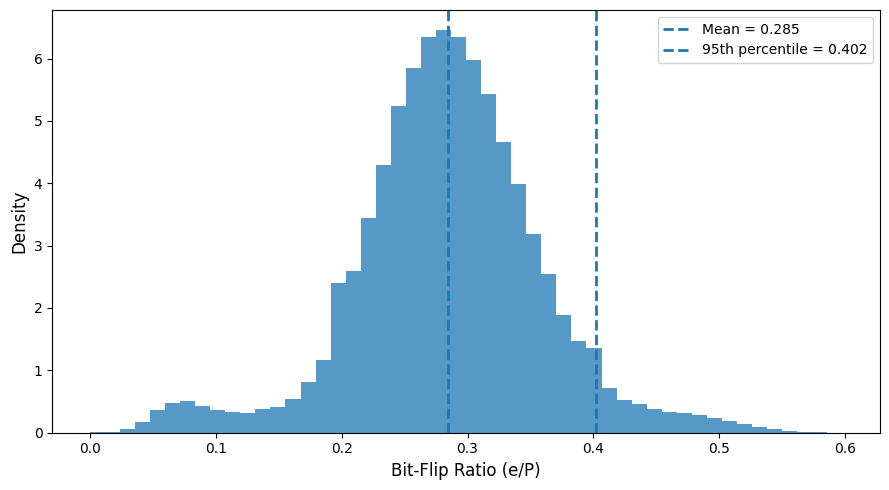

In [50]:
# ============================================================
# CELL 43 — e/P DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    bitflip_ratios,
    bins=50,
    density=True,
    alpha=0.75
)

plt.axvline(
    bitflip_ratios.mean(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean = "
        f"{bitflip_ratios.mean():.3f}"
    )
)

plt.axvline(
    np.percentile(
        bitflip_ratios,
        95
    ),
    linestyle="--",
    linewidth=2,
    label=(
        "95th percentile = "
        f"{np.percentile(bitflip_ratios,95):.3f}"
    )
)

plt.xlabel(
    "Bit-Flip Ratio (e/P)",
    fontsize=12
)

plt.ylabel(
    "Density",
    fontsize=12
)

plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# CELL 44 — PER-QUERY BIT-FLIP ANALYSIS
# ============================================================

from collections import defaultdict

ratios_by_identity = defaultdict(list)

for identity, ratio in zip(
    genuine_ids,
    bitflip_ratios
):
    ratios_by_identity[
        str(identity)
    ].append(float(ratio))


first_query_ratios = []
second_query_ratios = []

for identity in enrollment_ids:

    ratios = ratios_by_identity[
        str(identity)
    ]

    assert len(ratios) == 2

    first_query_ratios.append(
        ratios[0]
    )

    second_query_ratios.append(
        ratios[1]
    )


first_query_ratios = np.asarray(
    first_query_ratios
)

second_query_ratios = np.asarray(
    second_query_ratios
)


print("=" * 70)
print("QUERY-SPECIFIC e/P")
print("=" * 70)

print(
    "Query 1 mean:",
    f"{first_query_ratios.mean():.4f}"
)

print(
    "Query 2 mean:",
    f"{second_query_ratios.mean():.4f}"
)

print(
    "Query 1 95th:",
    f"{np.percentile(first_query_ratios,95):.4f}"
)

print(
    "Query 2 95th:",
    f"{np.percentile(second_query_ratios,95):.4f}"
)

QUERY-SPECIFIC e/P
Query 1 mean: 0.2847
Query 2 mean: 0.2846
Query 1 95th: 0.4023
Query 2 95th: 0.4023


In [53]:
# ============================================================
# CELL 45 — LOCK DATASET-LEVEL BIT-FLIP ERROR RATE
# ============================================================

import numpy as np

P = 256

# Mean e/P over ALL genuine enrollment-query comparisons
MEAN_E_OVER_P = float(
    np.mean(bitflip_ratios)
)

MEAN_E = (
    MEAN_E_OVER_P * P
)

print("=" * 72)
print("DATASET-LEVEL ITQ BIT-FLIP PARAMETER")
print("=" * 72)

print(
    f"Template length P       : {P}"
)

print(
    f"Mean e/P                : {MEAN_E_OVER_P:.6f}"
)

print(
    f"Mean flipped bits e     : {MEAN_E:.4f}"
)

print(
    f"Rounded e               : {round(MEAN_E)}"
)

print()
print(
    "✓ This dataset-level mean e/P will be used "
    "for HBF architecture design."
)

DATASET-LEVEL ITQ BIT-FLIP PARAMETER
Template length P       : 256
Mean e/P                : 0.284610
Mean flipped bits e     : 72.8602
Rounded e               : 73

✓ This dataset-level mean e/P will be used for HBF architecture design.


# Error Rate Tweak here

In [54]:
# ============================================================
# CELL 46 — LOCK HBF / CBF DESIGN INPUTS
# ============================================================

N_ENROLL = len(E_bits)

P = 256

# Empirically measured from genuine ITQ codes
E_OVER_P = MEAN_E_OVER_P

E_MEAN = E_OVER_P * P

# Designer-selected false-positive probability
TARGET_CBF_FPR = 1e-8


print("=" * 72)
print("DYNAMIC HIERARCHICAL CBF — DESIGN INPUTS")
print("=" * 72)

print(
    f"Enrollment templates n  : {N_ENROLL:,}"
)

print(
    f"ITQ template length P    : {P} bits"
)

print(
    f"Dataset mean e/P         : {E_OVER_P:.6f}"
)

print(
    f"Mean bit errors e        : {E_MEAN:.4f}"
)

print(
    f"Target CBF FPR           : {TARGET_CBF_FPR:.1e}"
)

print()
print("Structural constraints:")
print("  • Root level contains exactly ONE CBF.")
print("  • Root CBF receives the complete 256-bit code.")
print("  • Lower levels use calculated code chunks.")
print("  • Every hierarchy node is a Counting Bloom Filter.")
print("  • Hierarchy is derived using dataset-level mean e/P.")
print("  • CBF parameters m and k are calculated from target FPR.")

DYNAMIC HIERARCHICAL CBF — DESIGN INPUTS
Enrollment templates n  : 60,000
ITQ template length P    : 256 bits
Dataset mean e/P         : 0.284610
Mean bit errors e        : 72.8602
Target CBF FPR           : 1.0e-03

Structural constraints:
  • Level 1/root contains exactly ONE CBF.
  • Root CBF uses the complete 256-bit code.
  • Lower levels use calculated code chunks.
  • Every hierarchy node is a COUNTING Bloom filter.
  • Lower-level architecture will be derived from e/P.
  • CBF parameters m and k will be calculated, not copied.


In [55]:
# ============================================================
# CELL 47 — e/P-DRIVEN HIERARCHY CALCULATION
# ============================================================

import numpy as np
import pandas as pd
import math

P = 256
r = E_OVER_P

# Candidate chunk lengths that divide 256 exactly
CHUNK_LENGTHS = [
    256, 128, 64, 32,
    16, 8, 4, 2, 1
]

rows = []

for l in CHUNK_LENGTHS:

    B = P // l

    # Probability that an l-bit chunk contains
    # zero bit errors under the mean e/P model
    p_clean = (1.0 - r) ** l

    # Expected number of completely intact chunks
    expected_clean = B * p_clean

    # Approximate probability that at least one
    # chunk is completely intact
    p_at_least_one = (
        1.0
        -
        (1.0 - p_clean) ** B
    )

    rows.append({
        "chunk_bits": l,
        "num_CBFs": B,
        "P_clean_chunk": p_clean,
        "expected_clean_chunks": expected_clean,
        "P_at_least_one_clean": p_at_least_one
    })


hierarchy_analysis = pd.DataFrame(rows)

print("=" * 85)
print("e/P-DRIVEN CHUNK ANALYSIS")
print("=" * 85)

print(
    f"P                 = {P}"
)

print(
    f"mean e/P          = {r:.6f}"
)

print(
    f"mean e             = {r*P:.4f} bits"
)

print()

display(
    hierarchy_analysis.round(8)
)

e/P-DRIVEN CHUNK ANALYSIS
P                 = 256
mean e/P          = 0.284610
mean e             = 72.8602 bits



,chunk_bits,num_CBFs,P_clean_chunk,expected_clean_chunks,P_at_least_one_clean
0,256,1,0.000000,0.000000,0.000000
1,128,2,0.000000,0.000000,0.000000
2,64,4,0.000000,0.000000,0.000000
3,32,8,0.000022,0.000177,0.000177
4,16,16,0.004706,0.075302,0.072701
5,8,32,0.068603,2.195296,0.897124
6,4,64,0.261922,16.762991,1.000000
7,2,128,0.511783,65.508210,1.000000
8,1,256,0.715390,183.139847,1.000000


In [56]:
# ============================================================
# CELL 48 — EMPIRICAL CHUNK SURVIVAL
# ============================================================

# Corresponding enrollment template for every genuine query
matched_E = E_bits[
    matched_enrollment_indices
]

empirical_rows = []

for l in CHUNK_LENGTHS:

    B = P // l

    enroll_blocks = (
        matched_E
        .reshape(
            len(matched_E),
            B,
            l
        )
    )

    query_blocks = (
        G_bits
        .reshape(
            len(G_bits),
            B,
            l
        )
    )

    # Exact block equality
    clean = np.all(
        enroll_blocks
        ==
        query_blocks,
        axis=2
    )

    clean_count = clean.sum(
        axis=1
    )

    empirical_rows.append({

        "chunk_bits": l,

        "num_CBFs": B,

        "mean_clean_chunks":
            clean_count.mean(),

        "mean_clean_fraction":
            clean.mean(),

        "P_at_least_one_clean":
            np.mean(
                clean_count >= 1
            ),

        "P_at_least_2_clean":
            np.mean(
                clean_count >= 2
            ),

        "P_at_least_3_clean":
            np.mean(
                clean_count >= 3
            ),

        "median_clean_chunks":
            np.median(
                clean_count
            )
    })


empirical_hierarchy = pd.DataFrame(
    empirical_rows
)

print("=" * 85)
print("EMPIRICAL CHUNK SURVIVAL — 120,000 GENUINE QUERIES")
print("=" * 85)

display(
    empirical_hierarchy.round(6)
)

EMPIRICAL CHUNK SURVIVAL — 120,000 GENUINE QUERIES


,chunk_bits,num_CBFs,mean_clean_chunks,mean_clean_fraction,P_at_least_one_clean,P_at_least_2_clean,P_at_least_3_clean,median_clean_chunks
0,256,1,0.000150,0.000150,0.000150,0.000000,0.000000,0.0
1,128,2,0.000333,0.000167,0.000183,0.000150,0.000000,0.0
2,64,4,0.001850,0.000462,0.001308,0.000242,0.000150,0.0
3,32,8,0.024233,0.003029,0.016575,0.005100,0.001383,0.0
4,16,16,0.268925,0.016808,0.135992,0.045817,0.029217,0.0
5,8,32,2.878633,0.089957,0.835558,0.618317,0.416850,2.0
6,4,64,17.743258,0.277238,0.999817,0.998858,0.995983,17.0
7,2,128,66.119683,0.516560,1.000000,1.000000,1.000000,65.0
8,1,256,183.139850,0.715390,1.000000,1.000000,1.000000,183.0


In [57]:
# ============================================================
# CELL 49 — THEORY vs ACTUAL ITQ BEHAVIOR
# ============================================================

comparison = (
    hierarchy_analysis
    .merge(
        empirical_hierarchy,
        on=[
            "chunk_bits",
            "num_CBFs"
        ],
        suffixes=(
            "_theory",
            "_empirical"
        )
    )
)

comparison = comparison[[
    "chunk_bits",
    "num_CBFs",
    "P_clean_chunk",
    "mean_clean_fraction",
    "expected_clean_chunks",
    "mean_clean_chunks",
    "P_at_least_one_clean_theory",
    "P_at_least_one_clean_empirical"
]]

display(
    comparison.round(6)
)

,chunk_bits,num_CBFs,P_clean_chunk,mean_clean_fraction,expected_clean_chunks,mean_clean_chunks,P_at_least_one_clean_theory,P_at_least_one_clean_empirical
0,256,1,0.000000,0.000150,0.000000,0.000150,0.000000,0.000150
1,128,2,0.000000,0.000167,0.000000,0.000333,0.000000,0.000183
2,64,4,0.000000,0.000462,0.000000,0.001850,0.000000,0.001308
3,32,8,0.000022,0.003029,0.000177,0.024233,0.000177,0.016575
4,16,16,0.004706,0.016808,0.075302,0.268925,0.072701,0.135992
5,8,32,0.068603,0.089957,2.195296,2.878633,0.897124,0.835558
6,4,64,0.261922,0.277238,16.762991,17.743258,1.000000,0.999817
7,2,128,0.511783,0.516560,65.508210,66.119683,1.000000,1.000000
8,1,256,0.715390,0.715390,183.139847,183.139850,1.000000,1.000000


# ExP

In [59]:
# ============================================================
# CELL 50 — ERROR-AWARE HIERARCHY ANALYSIS
# Genuine survival vs. impostor block collision
# ============================================================

import numpy as np
import pandas as pd

P = 256
E_OVER_P = MEAN_E_OVER_P

# Candidate block lengths.
# All divide 256 exactly.
BLOCK_LENGTHS = [
    256, 128, 64, 32,
    16, 8, 4
]

# ------------------------------------------------------------
# Genuine pairs
# ------------------------------------------------------------

matched_E = E_bits[
    matched_enrollment_indices
]

# ------------------------------------------------------------
# Impostor pairs
#
# Use real open-set impostor codes.
# Pair each impostor query with an enrolled template.
# This is NOT final FAR evaluation.
# It is only for hierarchy-design collision analysis.
# ------------------------------------------------------------

rng = np.random.default_rng(42)

impostor_enroll_idx = rng.integers(
    low=0,
    high=len(E_bits),
    size=len(I_bits)
)

matched_impostor_E = E_bits[
    impostor_enroll_idx
]


rows = []

for block_bits in BLOCK_LENGTHS:

    num_blocks = P // block_bits

    # ========================================================
    # GENUINE
    # ========================================================

    e_blocks = matched_E.reshape(
        len(matched_E),
        num_blocks,
        block_bits
    )

    g_blocks = G_bits.reshape(
        len(G_bits),
        num_blocks,
        block_bits
    )

    genuine_equal = np.all(
        e_blocks == g_blocks,
        axis=2
    )

    genuine_count = genuine_equal.sum(
        axis=1
    )

    # ========================================================
    # IMPOSTOR
    # ========================================================

    imp_e_blocks = matched_impostor_E.reshape(
        len(matched_impostor_E),
        num_blocks,
        block_bits
    )

    imp_q_blocks = I_bits.reshape(
        len(I_bits),
        num_blocks,
        block_bits
    )

    impostor_equal = np.all(
        imp_e_blocks == imp_q_blocks,
        axis=2
    )

    impostor_count = impostor_equal.sum(
        axis=1
    )

    # ========================================================
    # STORE STATISTICS
    # ========================================================

    rows.append({

        "block_bits":
            block_bits,

        "num_CBFs":
            num_blocks,

        # Genuine statistics
        "genuine_clean_fraction":
            genuine_equal.mean(),

        "genuine_mean_matches":
            genuine_count.mean(),

        "genuine_P_ge_1":
            np.mean(
                genuine_count >= 1
            ),

        "genuine_P_ge_2":
            np.mean(
                genuine_count >= 2
            ),

        # Impostor statistics
        "impostor_collision_fraction":
            impostor_equal.mean(),

        "impostor_mean_matches":
            impostor_count.mean(),

        "impostor_P_ge_1":
            np.mean(
                impostor_count >= 1
            ),

        "impostor_P_ge_2":
            np.mean(
                impostor_count >= 2
            )
    })


hierarchy_tradeoff = pd.DataFrame(
    rows
)

print("=" * 110)
print("ERROR-AWARE HIERARCHY DESIGN")
print("=" * 110)

print(
    f"P                 : {P}"
)

print(
    f"Dataset mean e/P  : {E_OVER_P:.6f} "
    f"({100*E_OVER_P:.2f}%)"
)

print(
    f"Approx. mean e     : {E_OVER_P*P:.2f} bits"
)

print()

display(
    hierarchy_tradeoff.round(8)
)

ERROR-AWARE HIERARCHY DESIGN
P                 : 256
Dataset mean e/P  : 0.284610 (28.46%)
Approx. mean e     : 72.86 bits



,block_bits,num_CBFs,genuine_clean_fraction,genuine_mean_matches,genuine_P_ge_1,genuine_P_ge_2,impostor_collision_fraction,impostor_mean_matches,impostor_P_ge_1,impostor_P_ge_2
0,256,1,0.000150,0.000150,0.000150,0.000000,0.000000,0.000000,0.000000,0.000000
1,128,2,0.000167,0.000333,0.000183,0.000150,0.000000,0.000000,0.000000,0.000000
2,64,4,0.000463,0.001850,0.001308,0.000242,0.000000,0.000000,0.000000,0.000000
3,32,8,0.003029,0.024233,0.016575,0.005100,0.000000,0.000000,0.000000,0.000000
4,16,16,0.016808,0.268925,0.135992,0.045817,0.000010,0.000155,0.000155,0.000000
5,8,32,0.089957,2.878633,0.835558,0.618317,0.003884,0.124291,0.117104,0.006915
6,4,64,0.277238,17.743258,0.999817,0.998858,0.062538,4.002409,0.983607,0.912419


In [60]:
# ============================================================
# CELL 51 — LOCK PROPOSED ERROR-AWARE HIERARCHY
# ============================================================

import numpy as np
import pandas as pd

P = 256

# Root -> leaf
LEVEL_BLOCK_BITS = np.array([
    256,
    128,
    64,
    32,
    16,
    8
], dtype=np.int32)

LEVEL_NUM_CBFS = (
    P // LEVEL_BLOCK_BITS
).astype(np.int32)

TOTAL_LEVELS = len(
    LEVEL_BLOCK_BITS
)

TOTAL_CBFS = int(
    LEVEL_NUM_CBFS.sum()
)


# ------------------------------------------------------------
# Verify complete non-overlapping coverage at every level
# ------------------------------------------------------------

assert np.all(
    LEVEL_BLOCK_BITS *
    LEVEL_NUM_CBFS
    == P
)

assert LEVEL_NUM_CBFS[0] == 1
assert LEVEL_BLOCK_BITS[0] == P


hierarchy_df = pd.DataFrame({

    "level":
        np.arange(TOTAL_LEVELS),

    "block_bits":
        LEVEL_BLOCK_BITS,

    "num_CBFs":
        LEVEL_NUM_CBFS,

    "template_coverage":
        LEVEL_BLOCK_BITS *
        LEVEL_NUM_CBFS
})


print("=" * 72)
print("PROPOSED ERROR-AWARE HIERARCHICAL CBF")
print("=" * 72)

print(f"Template length P       : {P}")
print(f"Mean e/P                : {E_OVER_P:.6f}")
print(f"Target CBF FPR          : {TARGET_CBF_FPR:.1e}")

print()
display(hierarchy_df)

print(
    f"Total levels            : {TOTAL_LEVELS}"
)

print(
    f"Total CBFs              : {TOTAL_CBFS}"
)

print()
print(
    "Root -> leaf block sizes:",
    LEVEL_BLOCK_BITS.tolist()
)

print(
    "Root -> leaf CBF counts:",
    LEVEL_NUM_CBFS.tolist()
)

print()
print(
    "4-bit level excluded because of "
    "excessive empirical impostor collision."
)

PROPOSED ERROR-AWARE HIERARCHICAL CBF
Template length P       : 256
Mean e/P                : 0.284610
Target CBF FPR          : 1.0e-08



,level,block_bits,num_CBFs,template_coverage
0,0,256,1,256
1,1,128,2,256
2,2,64,4,256
3,3,32,8,256
4,4,16,16,256
5,5,8,32,256


Total levels            : 6
Total CBFs              : 63

Root -> leaf block sizes: [256, 128, 64, 32, 16, 8]
Root -> leaf CBF counts: [1, 2, 4, 8, 16, 32]

4-bit level excluded because of excessive empirical impostor collision.


In [61]:
# ============================================================
# CELL 52 — CBF NODE CARDINALITY / MULTIPLICITY AUDIT
# ============================================================

import numpy as np
import pandas as pd

E = np.asarray(E_bits, dtype=np.uint8)

N_ENROLL = len(E)

audit_rows = []


def binary_rows_to_int(blocks):
    """
    Convert binary rows [N, b] to integer values.

    Safe here because maximum block length is 256 bits;
    Python integers handle arbitrary precision.
    """
    return np.array(
        [
            int("".join(row.astype(str)), 2)
            for row in blocks
        ],
        dtype=object
    )


for level, block_bits in enumerate(
    LEVEL_BLOCK_BITS
):

    block_bits = int(block_bits)
    num_cbfs = int(
        LEVEL_NUM_CBFS[level]
    )

    for position in range(num_cbfs):

        start = (
            position * block_bits
        )

        end = (
            start + block_bits
        )

        blocks = E[
            :,
            start:end
        ]

        # ----------------------------------------------------
        # Pack each binary block into bytes.
        #
        # np.unique(..., axis=0) directly gives unique
        # block values without needing integer conversion.
        # ----------------------------------------------------

        unique_blocks, counts = np.unique(
            blocks,
            axis=0,
            return_counts=True
        )

        n_unique = len(
            unique_blocks
        )

        max_multiplicity = int(
            counts.max()
        )

        mean_multiplicity = (
            N_ENROLL /
            n_unique
        )

        singleton_values = int(
            np.sum(counts == 1)
        )

        # Fraction of theoretical block-value space occupied.
        # For large blocks this may be extremely tiny.
        possible_values = (
            2 ** block_bits
        )

        occupancy = (
            n_unique /
            possible_values
        )

        audit_rows.append({

            "level":
                level,

            "position":
                position,

            "block_bits":
                block_bits,

            "enroll_occurrences":
                N_ENROLL,

            "unique_values":
                n_unique,

            "duplicate_occurrences":
                N_ENROLL - n_unique,

            "mean_multiplicity":
                mean_multiplicity,

            "max_multiplicity":
                max_multiplicity,

            "singleton_values":
                singleton_values,

            "value_space_occupancy":
                occupancy
        })


cbf_node_audit = pd.DataFrame(
    audit_rows
)


print("=" * 100)
print("CBF NODE CARDINALITY / MULTIPLICITY AUDIT")
print("=" * 100)

print(
    f"Enrollment templates : {N_ENROLL:,}"
)

print(
    f"Total CBF nodes       : {len(cbf_node_audit)}"
)

print()


# ------------------------------------------------------------
# Per-level summary
# ------------------------------------------------------------

level_summary = (
    cbf_node_audit
    .groupby("level")
    .agg(
        block_bits=(
            "block_bits",
            "first"
        ),

        num_CBFs=(
            "position",
            "count"
        ),

        mean_unique_values=(
            "unique_values",
            "mean"
        ),

        min_unique_values=(
            "unique_values",
            "min"
        ),

        max_unique_values=(
            "unique_values",
            "max"
        ),

        mean_multiplicity=(
            "mean_multiplicity",
            "mean"
        ),

        max_multiplicity=(
            "max_multiplicity",
            "max"
        ),

        mean_value_space_occupancy=(
            "value_space_occupancy",
            "mean"
        )
    )
    .reset_index()
)


display(
    level_summary.round(6)
)

CBF NODE CARDINALITY / MULTIPLICITY AUDIT
Enrollment templates : 60,000
Total CBF nodes       : 63



,level,block_bits,num_CBFs,mean_unique_values,min_unique_values,max_unique_values,mean_multiplicity,max_multiplicity,mean_value_space_occupancy
0,0,256,1,59999.000,59999,59999,1.000017,2,0.000000
1,1,128,2,59999.000,59999,59999,1.000017,2,0.000000
2,2,64,4,59999.000,59999,59999,1.000017,2,0.000000
3,3,32,8,59997.125,59995,59999,1.000048,2,0.000014
4,4,16,16,38980.375,38847,39124,1.539242,9,0.594793
5,5,8,32,256.000,256,256,234.375000,340,1.000000


In [62]:
# ============================================================
# CELL 53 — SHORT-BLOCK CBF DETAILS
# ============================================================

short_block_nodes = (
    cbf_node_audit[
        cbf_node_audit[
            "block_bits"
        ].isin([16, 8])
    ]
    .copy()
)


display(
    short_block_nodes[[
        "level",
        "position",
        "block_bits",
        "unique_values",
        "duplicate_occurrences",
        "mean_multiplicity",
        "max_multiplicity",
        "value_space_occupancy"
    ]].round(6)
)

,level,position,block_bits,unique_values,duplicate_occurrences,mean_multiplicity,max_multiplicity,value_space_occupancy
15,4,0,16,38942,21058,1.540753,7,0.594208
16,4,1,16,38913,21087,1.541901,7,0.593765
17,4,2,16,38867,21133,1.543726,8,0.593063
18,4,3,16,39021,20979,1.537634,7,0.595413
19,4,4,16,39124,20876,1.533586,7,0.596985
20,4,5,16,39086,20914,1.535076,7,0.596405
21,4,6,16,39001,20999,1.538422,7,0.595108
22,4,7,16,39027,20973,1.537397,9,0.595505
23,4,8,16,38847,21153,1.544521,7,0.592758
24,4,9,16,38996,21004,1.538619,9,0.595032


In [63]:
# ============================================================
# CELL 54 — FINALIZE PROPOSED ERROR-AWARE HIERARCHY
# ============================================================

import numpy as np
import pandas as pd

P = 256

# 8-bit level removed:
# all 256 possible values occurred at every 8-bit position.

LEVEL_BLOCK_BITS = np.array([
    256,
    128,
    64,
    32,
    16
], dtype=np.int32)

LEVEL_NUM_CBFS = (
    P // LEVEL_BLOCK_BITS
).astype(np.int32)

TOTAL_LEVELS = len(
    LEVEL_BLOCK_BITS
)

TOTAL_CBFS = int(
    LEVEL_NUM_CBFS.sum()
)

assert np.all(
    LEVEL_BLOCK_BITS *
    LEVEL_NUM_CBFS == P
)

assert TOTAL_CBFS == 31


final_hierarchy_df = pd.DataFrame({
    "level":
        np.arange(TOTAL_LEVELS),

    "block_bits":
        LEVEL_BLOCK_BITS,

    "num_CBFs":
        LEVEL_NUM_CBFS,

    "coverage_bits":
        LEVEL_BLOCK_BITS *
        LEVEL_NUM_CBFS
})


print("=" * 76)
print("FINAL PROPOSED ERROR-AWARE HIERARCHICAL CBF")
print("=" * 76)

print(f"Template length P       : {P}")
print(f"Mean e/P                : {E_OVER_P:.6f}")
print(f"Target CBF FPR          : {TARGET_CBF_FPR:.1e}")

print()

display(final_hierarchy_df)

print(f"Total levels            : {TOTAL_LEVELS}")
print(f"Total CBFs              : {TOTAL_CBFS}")

print()
print(
    "Root -> leaf block sizes:",
    LEVEL_BLOCK_BITS.tolist()
)

print(
    "Root -> leaf CBF counts:",
    LEVEL_NUM_CBFS.tolist()
)

print()
print("Excluded level:")
print(
    "  8-bit blocks -> 32 CBFs: REJECTED "
    "(100% empirical value-space occupancy)"
)

FINAL PROPOSED ERROR-AWARE HIERARCHICAL CBF
Template length P       : 256
Mean e/P                : 0.284610
Target CBF FPR          : 1.0e-08



,level,block_bits,num_CBFs,coverage_bits
0,0,256,1,256
1,1,128,2,256
2,2,64,4,256
3,3,32,8,256
4,4,16,16,256


Total levels            : 5
Total CBFs              : 31

Root -> leaf block sizes: [256, 128, 64, 32, 16]
Root -> leaf CBF counts: [1, 2, 4, 8, 16]

Excluded level:
  8-bit blocks -> 32 CBFs: REJECTED (100% empirical value-space occupancy)


In [64]:
# ============================================================
# CELL 55 — COUNTING BLOOM FILTER DESIGN PARAMETERS
# ============================================================

import math
import pandas as pd

N_CBF_CAPACITY = 60_000
TARGET_CBF_FPR = 1e-8

# Standard Bloom-filter optimum
m_exact = -(
    N_CBF_CAPACITY * math.log(TARGET_CBF_FPR)
) / (math.log(2) ** 2)

k_exact = (
    (m_exact / N_CBF_CAPACITY)
    * math.log(2)
)

# Integer implementation parameters
CBF_M = int(math.ceil(m_exact))
CBF_K = max(
    1,
    int(round(k_exact))
)

# Actual theoretical FPR after integer rounding
actual_fpr = (
    1.0
    -
    math.exp(
        -(CBF_K * N_CBF_CAPACITY)
        / CBF_M
    )
) ** CBF_K


print("=" * 76)
print("COUNTING BLOOM FILTER DESIGN")
print("=" * 76)

print(f"Design capacity n        : {N_CBF_CAPACITY:,}")
print(f"Target FPR               : {TARGET_CBF_FPR:.1e}")

print()
print(f"Theoretical m            : {m_exact:,.3f}")
print(f"Counter positions m      : {CBF_M:,}")

print()
print(f"Theoretical k            : {k_exact:.6f}")
print(f"Hash functions k         : {CBF_K}")

print()
print(f"Actual theoretical FPR   : {actual_fpr:.3e}")

print()
print(f"Number of CBFs           : {TOTAL_CBFS}")
print(
    f"Total counter positions  : "
    f"{TOTAL_CBFS * CBF_M:,}"
)

COUNTING BLOOM FILTER DESIGN
Design capacity n        : 60,000
Target FPR               : 1.0e-08

Theoretical m            : 2,300,414.011
Counter positions m      : 2,300,415

Theoretical k            : 26.575425
Hash functions k         : 27

Actual theoretical FPR   : 1.001e-08

Number of CBFs           : 31
Total counter positions  : 71,312,865


In [65]:
# ============================================================
# CELL 56 — CBF MEMORY REQUIREMENT
# ============================================================

TOTAL_COUNTERS = (
    TOTAL_CBFS * CBF_M
)

memory_rows = []

for dtype_name, bytes_per_counter, max_value in [
    ("uint8",  1, 255),
    ("uint16", 2, 65535),
    ("uint32", 4, 4294967295)
]:

    total_bytes = (
        TOTAL_COUNTERS
        * bytes_per_counter
    )

    memory_rows.append({
        "dtype":
            dtype_name,

        "bytes_per_counter":
            bytes_per_counter,

        "max_counter_value":
            max_value,

        "memory_MB":
            total_bytes / 1e6,

        "memory_MiB":
            total_bytes / (1024 ** 2),

        "memory_GiB":
            total_bytes / (1024 ** 3)
    })


memory_df = pd.DataFrame(
    memory_rows
)

print("=" * 76)
print("COUNTING BLOOM FILTER MEMORY")
print("=" * 76)

print(
    f"Counter positions / CBF : {CBF_M:,}"
)

print(
    f"Total CBFs              : {TOTAL_CBFS}"
)

print(
    f"Total counter positions : {TOTAL_COUNTERS:,}"
)

print()

display(
    memory_df.round(4)
)

COUNTING BLOOM FILTER MEMORY
Counter positions / CBF : 2,300,415
Total CBFs              : 31
Total counter positions : 71,312,865



,dtype,bytes_per_counter,max_counter_value,memory_MB,memory_MiB,memory_GiB
0,uint8,1,255,71.3129,68.0092,0.0664
1,uint16,2,65535,142.6257,136.0185,0.1328
2,uint32,4,4294967295,285.2515,272.0370,0.2657


In [67]:
# ============================================================
# CELL 57 — HASH-LOAD / COUNTER-WIDTH AUDIT
# ============================================================

import numpy as np
import hashlib

def block_to_bytes(block):
    """
    Convert a binary block to a deterministic byte representation.

    Position/level information will be added separately to prevent
    identical bit strings from different hierarchy nodes from being
    treated as the same hash namespace.
    """
    return np.packbits(
        np.asarray(block, dtype=np.uint8)
    ).tobytes()


def hash_pair(data):
    """
    Generate two deterministic 64-bit hash values using SHA-256.
    Double hashing then produces k CBF indices.
    """
    digest = hashlib.sha256(data).digest()

    h1 = int.from_bytes(
        digest[0:8],
        byteorder="little",
        signed=False
    )

    h2 = int.from_bytes(
        digest[8:16],
        byteorder="little",
        signed=False
    )

    # Avoid zero second hash
    if h2 == 0:
        h2 = 0x9E3779B97F4A7C15

    return h1, h2


def cbf_indices(block, level, position, m=CBF_M, k=CBF_K):

    namespace = (
        int(level).to_bytes(2, "little")
        +
        int(position).to_bytes(2, "little")
    )

    data = namespace + block_to_bytes(block)

    h1, h2 = hash_pair(data)

    return np.asarray(
        [
            (h1 + i * h2) % m
            for i in range(k)
        ],
        dtype=np.int64
    )

In [68]:
# ============================================================
# CELL 58 — EMPIRICAL COUNTER-LOAD AUDIT
# ============================================================

counter_audit_rows = []

for level, block_bits in enumerate(
    LEVEL_BLOCK_BITS
):

    block_bits = int(block_bits)
    num_cbfs = int(
        LEVEL_NUM_CBFS[level]
    )

    print(
        f"Auditing level {level}: "
        f"{num_cbfs} CBF(s) × "
        f"{block_bits} bits"
    )

    for position in range(num_cbfs):

        start = (
            position * block_bits
        )

        end = (
            start + block_bits
        )

        # Temporary uint32 array so the audit itself
        # cannot overflow.
        counters = np.zeros(
            CBF_M,
            dtype=np.uint32
        )

        for row in E_bits:

            block = row[start:end]

            idx = cbf_indices(
                block,
                level,
                position
            )

            # Correctly handles the unlikely case that the
            # same element produces duplicate indices.
            np.add.at(
                counters,
                idx,
                1
            )

        max_counter = int(
            counters.max()
        )

        nonzero = int(
            np.count_nonzero(counters)
        )

        counter_audit_rows.append({
            "level":
                level,

            "position":
                position,

            "block_bits":
                block_bits,

            "max_counter":
                max_counter,

            "nonzero_counters":
                nonzero,

            "counter_occupancy":
                nonzero / CBF_M
        })


counter_load_df = pd.DataFrame(
    counter_audit_rows
)

print()
print("=" * 76)
print("COUNTER-LOAD SUMMARY")
print("=" * 76)

counter_level_summary = (
    counter_load_df
    .groupby("level")
    .agg(
        block_bits=(
            "block_bits",
            "first"
        ),

        num_CBFs=(
            "position",
            "count"
        ),

        max_counter=(
            "max_counter",
            "max"
        ),

        mean_counter_occupancy=(
            "counter_occupancy",
            "mean"
        )
    )
    .reset_index()
)

display(
    counter_level_summary.round(6)
)

GLOBAL_MAX_COUNTER = int(
    counter_load_df[
        "max_counter"
    ].max()
)

print(
    f"\nMaximum counter observed anywhere: "
    f"{GLOBAL_MAX_COUNTER}"
)

Auditing level 0: 1 CBF(s) × 256 bits
Auditing level 1: 2 CBF(s) × 128 bits
Auditing level 2: 4 CBF(s) × 64 bits
Auditing level 3: 8 CBF(s) × 32 bits
Auditing level 4: 16 CBF(s) × 16 bits

COUNTER-LOAD SUMMARY


,level,block_bits,num_CBFs,max_counter,mean_counter_occupancy
0,0,256,1,8,0.505556
1,1,128,2,8,0.505641
2,2,64,4,9,0.505435
3,3,32,8,8,0.505611
4,4,16,16,16,0.367131



Maximum counter observed anywhere: 16


In [69]:
# ============================================================
# CELL 59 — COUNTING BLOOM FILTER IMPLEMENTATION
# ============================================================

import numpy as np


class CountingBloomFilter:

    def __init__(
        self,
        m,
        k,
        level,
        position,
        dtype=np.uint8
    ):
        self.m = int(m)
        self.k = int(k)

        self.level = int(level)
        self.position = int(position)

        self.counters = np.zeros(
            self.m,
            dtype=dtype
        )


    def _indices(self, block):

        return cbf_indices(
            block=block,
            level=self.level,
            position=self.position,
            m=self.m,
            k=self.k
        )


    def add(self, block):

        idx = self._indices(block)

        # uint8 overflow protection
        if np.any(
            self.counters[idx] ==
            np.iinfo(self.counters.dtype).max
        ):
            raise OverflowError(
                f"CBF counter overflow at "
                f"level={self.level}, "
                f"position={self.position}"
            )

        np.add.at(
            self.counters,
            idx,
            1
        )


    def contains(self, block):

        idx = self._indices(block)

        return bool(
            np.all(
                self.counters[idx] > 0
            )
        )


    def remove(self, block):
        """
        Safe deletion.

        Only decrement if every required counter is positive.
        """

        idx = self._indices(block)

        if not np.all(
            self.counters[idx] > 0
        ):
            return False

        np.subtract.at(
            self.counters,
            idx,
            1
        )

        return True


print("CountingBloomFilter class defined.")

CountingBloomFilter class defined.


In [70]:
# ============================================================
# CELL 60 — EXACT CBF UPDATE METHODS
# ============================================================

def cbf_add_exact(self, block):

    idx = self._indices(block)

    unique_idx, increments = np.unique(
        idx,
        return_counts=True
    )

    max_value = np.iinfo(
        self.counters.dtype
    ).max

    if np.any(
        self.counters[unique_idx].astype(np.uint64)
        + increments
        > max_value
    ):
        raise OverflowError(
            f"CBF counter overflow at "
            f"level={self.level}, "
            f"position={self.position}"
        )

    self.counters[unique_idx] += (
        increments.astype(
            self.counters.dtype
        )
    )


def cbf_remove_exact(self, block):

    idx = self._indices(block)

    unique_idx, decrements = np.unique(
        idx,
        return_counts=True
    )

    if np.any(
        self.counters[unique_idx]
        <
        decrements
    ):
        return False

    self.counters[unique_idx] -= (
        decrements.astype(
            self.counters.dtype
        )
    )

    return True


CountingBloomFilter.add = cbf_add_exact
CountingBloomFilter.remove = cbf_remove_exact

print("Exact add/remove methods installed.")

Exact add/remove methods installed.


In [71]:
# ============================================================
# CELL 61 — ALLOCATE HIERARCHICAL CBF
# ============================================================

HCBF = []

for level, block_bits in enumerate(
    LEVEL_BLOCK_BITS
):

    n_cbfs = int(
        LEVEL_NUM_CBFS[level]
    )

    level_filters = []

    for position in range(n_cbfs):

        level_filters.append(
            CountingBloomFilter(
                m=CBF_M,
                k=CBF_K,
                level=level,
                position=position,
                dtype=np.uint8
            )
        )

    HCBF.append(
        level_filters
    )


allocated_cbfs = sum(
    len(level)
    for level in HCBF
)

allocated_bytes = sum(
    bf.counters.nbytes
    for level in HCBF
    for bf in level
)


print("=" * 72)
print("HIERARCHICAL CBF ALLOCATION")
print("=" * 72)

print(
    f"Levels                  : {len(HCBF)}"
)

print(
    f"CBFs allocated          : {allocated_cbfs}"
)

print(
    f"Counter positions / CBF : {CBF_M:,}"
)

print(
    f"Hash functions          : {CBF_K}"
)

print(
    f"Counter dtype           : uint8"
)

print(
    f"Allocated memory        : "
    f"{allocated_bytes / (1024**2):.2f} MiB"
)

assert allocated_cbfs == 31

HIERARCHICAL CBF ALLOCATION
Levels                  : 5
CBFs allocated          : 31
Counter positions / CBF : 2,300,415
Hash functions          : 27
Counter dtype           : uint8
Allocated memory        : 68.01 MiB


In [72]:
# ============================================================
# CELL 62 — ENROLL 60,000 TEMPLATES INTO HIERARCHICAL CBF
# ============================================================

import time

start_time = time.time()

N = len(E_bits)

for template_idx, template in enumerate(E_bits):

    for level, block_bits in enumerate(
        LEVEL_BLOCK_BITS
    ):

        block_bits = int(block_bits)

        for position, cbf in enumerate(
            HCBF[level]
        ):

            start = (
                position * block_bits
            )

            end = (
                start + block_bits
            )

            block = template[
                start:end
            ]

            cbf.add(block)


    if (
        (template_idx + 1) % 5000 == 0
        or template_idx == 0
    ):

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Enrolled "
            f"{template_idx + 1:>6,}/{N:,} "
            f"| elapsed = {elapsed:.1f} s"
        )


enrollment_time = (
    time.time()
    - start_time
)


print()
print("=" * 72)
print("ENROLLMENT COMPLETE")
print("=" * 72)

print(
    f"Templates enrolled : {N:,}"
)

print(
    f"CBFs per template  : {TOTAL_CBFS}"
)

print(
    f"Total insertions   : "
    f"{N * TOTAL_CBFS:,}"
)

print(
    f"Enrollment time    : "
    f"{enrollment_time:.2f} sec"
)

print(
    f"Templates/sec      : "
    f"{N / enrollment_time:.2f}"
)

Enrolled      1/60,000 | elapsed = 0.0 s
Enrolled  5,000/60,000 | elapsed = 7.6 s
Enrolled 10,000/60,000 | elapsed = 15.2 s
Enrolled 15,000/60,000 | elapsed = 22.9 s
Enrolled 20,000/60,000 | elapsed = 30.4 s
Enrolled 25,000/60,000 | elapsed = 38.0 s
Enrolled 30,000/60,000 | elapsed = 45.6 s
Enrolled 35,000/60,000 | elapsed = 53.2 s
Enrolled 40,000/60,000 | elapsed = 60.6 s
Enrolled 45,000/60,000 | elapsed = 68.2 s
Enrolled 50,000/60,000 | elapsed = 75.8 s
Enrolled 55,000/60,000 | elapsed = 83.3 s
Enrolled 60,000/60,000 | elapsed = 90.9 s

ENROLLMENT COMPLETE
Templates enrolled : 60,000
CBFs per template  : 31
Total insertions   : 1,860,000
Enrollment time    : 90.86 sec
Templates/sec      : 660.32


In [73]:
# ============================================================
# CELL 63 — POST-ENROLLMENT HIERARCHY AUDIT
# ============================================================

audit = []

for level, level_filters in enumerate(
    HCBF
):

    block_bits = int(
        LEVEL_BLOCK_BITS[level]
    )

    for position, cbf in enumerate(
        level_filters
    ):

        counters = cbf.counters

        audit.append({

            "level":
                level,

            "position":
                position,

            "block_bits":
                block_bits,

            "nonzero":
                np.count_nonzero(
                    counters
                ),

            "occupancy":
                np.count_nonzero(
                    counters
                ) / CBF_M,

            "max_counter":
                int(
                    counters.max()
                ),

            "mean_counter":
                float(
                    counters.mean()
                )
        })


post_enrollment_audit = pd.DataFrame(
    audit
)


post_level_summary = (
    post_enrollment_audit
    .groupby("level")
    .agg(
        block_bits=(
            "block_bits",
            "first"
        ),

        num_CBFs=(
            "position",
            "count"
        ),

        mean_occupancy=(
            "occupancy",
            "mean"
        ),

        max_counter=(
            "max_counter",
            "max"
        ),

        mean_counter=(
            "mean_counter",
            "mean"
        )
    )
    .reset_index()
)


print("=" * 72)
print("POST-ENROLLMENT HIERARCHY AUDIT")
print("=" * 72)

display(
    post_level_summary.round(6)
)

print(
    "Global maximum counter:",
    post_enrollment_audit[
        "max_counter"
    ].max()
)

POST-ENROLLMENT HIERARCHY AUDIT


,level,block_bits,num_CBFs,mean_occupancy,max_counter,mean_counter
0,0,256,1,0.505556,8,0.704221
1,1,128,2,0.505641,8,0.704221
2,2,64,4,0.505435,9,0.704221
3,3,32,8,0.505611,8,0.704221
4,4,16,16,0.367131,16,0.704221


Global maximum counter: 16


In [74]:
# ============================================================
# CELL 64 — VALIDATION / TEST QUERY SPLIT
# ============================================================

import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)


# ------------------------------------------------------------
# Genuine:
# one query per enrolled identity -> validation
# one query per enrolled identity -> test
# ------------------------------------------------------------

genuine_ids_arr = np.asarray(genuine_ids)

val_genuine_idx = []
test_genuine_idx = []

for identity in enrollment_ids:

    idx = np.where(
        genuine_ids_arr == identity
    )[0]

    if len(idx) != 2:
        raise ValueError(
            f"Identity {identity} has "
            f"{len(idx)} genuine queries; expected 2."
        )

    val_genuine_idx.append(
        idx[0]
    )

    test_genuine_idx.append(
        idx[1]
    )


val_genuine_idx = np.asarray(
    val_genuine_idx,
    dtype=np.int64
)

test_genuine_idx = np.asarray(
    test_genuine_idx,
    dtype=np.int64
)


# ------------------------------------------------------------
# Impostors:
# split by ID, NOT image
# ------------------------------------------------------------

impostor_ids_arr = np.asarray(
    impostor_ids
)

unique_impostor_ids = np.unique(
    impostor_ids_arr
)

rng.shuffle(
    unique_impostor_ids
)

split_point = (
    len(unique_impostor_ids) // 2
)

val_impostor_ids = set(
    unique_impostor_ids[
        :split_point
    ]
)

test_impostor_ids = set(
    unique_impostor_ids[
        split_point:
    ]
)


val_impostor_idx = np.asarray(
    [
        i
        for i, identity
        in enumerate(impostor_ids_arr)
        if identity in val_impostor_ids
    ],
    dtype=np.int64
)

test_impostor_idx = np.asarray(
    [
        i
        for i, identity
        in enumerate(impostor_ids_arr)
        if identity in test_impostor_ids
    ],
    dtype=np.int64
)


print("=" * 72)
print("QUERY PARTITIONS")
print("=" * 72)

print(
    f"Validation genuine queries : "
    f"{len(val_genuine_idx):,}"
)

print(
    f"Test genuine queries       : "
    f"{len(test_genuine_idx):,}"
)

print(
    f"Validation impostor IDs    : "
    f"{len(val_impostor_ids):,}"
)

print(
    f"Validation impostor queries: "
    f"{len(val_impostor_idx):,}"
)

print(
    f"Test impostor IDs          : "
    f"{len(test_impostor_ids):,}"
)

print(
    f"Test impostor queries      : "
    f"{len(test_impostor_idx):,}"
)


# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------

assert set(
    val_genuine_idx
).isdisjoint(
    set(test_genuine_idx)
)

assert val_impostor_ids.isdisjoint(
    test_impostor_ids
)

print()
print("✓ No query-index overlap.")
print("✓ No impostor-identity overlap.")

QUERY PARTITIONS
Validation genuine queries : 60,000
Test genuine queries       : 60,000
Validation impostor IDs    : 12,871
Validation impostor queries: 25,742
Test impostor IDs          : 12,871
Test impostor queries      : 25,742

✓ No query-index overlap.
✓ No impostor-identity overlap.


In [76]:
# ============================================================
# CELL 65 — HCBF QUERY SCORING
# ============================================================

import numpy as np
import time


def query_hcbf(template):

    level_scores = []

    for level, block_bits in enumerate(
        LEVEL_BLOCK_BITS
    ):

        block_bits = int(
            block_bits
        )

        level_score = 0

        for position, cbf in enumerate(
            HCBF[level]
        ):

            start = (
                position * block_bits
            )

            end = (
                start + block_bits
            )

            block = template[
                start:end
            ]

            if cbf.contains(block):
                level_score += 1

        level_scores.append(
            level_score
        )

    total_score = int(
        sum(level_scores)
    )

    return total_score, level_scores


def score_dataset(
    templates,
    label=""
):

    total_scores = np.zeros(
        len(templates),
        dtype=np.int16
    )

    level_scores = np.zeros(
        (
            len(templates),
            TOTAL_LEVELS
        ),
        dtype=np.int16
    )

    start_time = time.time()

    for i, template in enumerate(
        templates
    ):

        total, levels = query_hcbf(
            template
        )

        total_scores[i] = total
        level_scores[i] = levels

        if (
            (i + 1) % 5000 == 0
            or i == 0
        ):

            elapsed = (
                time.time()
                - start_time
            )

            print(
                f"{label:20s} "
                f"{i+1:>6,}/{len(templates):,} "
                f"| {elapsed:.1f} sec"
            )

    elapsed = (
        time.time()
        - start_time
    )

    print(
        f"{label} complete: "
        f"{elapsed:.2f} sec"
    )

    return (
        total_scores,
        level_scores
    )

In [77]:
# ============================================================
# CELL 66 — SCORE VALIDATION QUERIES
# ============================================================

val_genuine_scores, val_genuine_levels = (
    score_dataset(
        G_bits[val_genuine_idx],
        label="VAL GENUINE"
    )
)

val_impostor_scores, val_impostor_levels = (
    score_dataset(
        I_bits[val_impostor_idx],
        label="VAL IMPOSTOR"
    )
)


print()
print("=" * 72)
print("VALIDATION SCORE SUMMARY")
print("=" * 72)

print(
    f"Genuine mean   : "
    f"{val_genuine_scores.mean():.4f}"
)

print(
    f"Genuine median : "
    f"{np.median(val_genuine_scores):.4f}"
)

print(
    f"Genuine range  : "
    f"{val_genuine_scores.min()} - "
    f"{val_genuine_scores.max()}"
)

print()

print(
    f"Impostor mean  : "
    f"{val_impostor_scores.mean():.4f}"
)

print(
    f"Impostor median: "
    f"{np.median(val_impostor_scores):.4f}"
)

print(
    f"Impostor range : "
    f"{val_impostor_scores.min()} - "
    f"{val_impostor_scores.max()}"
)

VAL GENUINE               1/60,000 | 0.0 sec
VAL GENUINE           5,000/60,000 | 2.3 sec
VAL GENUINE          10,000/60,000 | 4.8 sec
VAL GENUINE          15,000/60,000 | 7.2 sec
VAL GENUINE          20,000/60,000 | 9.7 sec
VAL GENUINE          25,000/60,000 | 12.2 sec
VAL GENUINE          30,000/60,000 | 14.6 sec
VAL GENUINE          35,000/60,000 | 17.0 sec
VAL GENUINE          40,000/60,000 | 19.5 sec
VAL GENUINE          45,000/60,000 | 21.9 sec
VAL GENUINE          50,000/60,000 | 24.3 sec
VAL GENUINE          55,000/60,000 | 26.7 sec
VAL GENUINE          60,000/60,000 | 29.2 sec
VAL GENUINE complete: 29.17 sec
VAL IMPOSTOR              1/25,742 | 0.0 sec
VAL IMPOSTOR          5,000/25,742 | 2.4 sec
VAL IMPOSTOR         10,000/25,742 | 4.8 sec
VAL IMPOSTOR         15,000/25,742 | 7.2 sec
VAL IMPOSTOR         20,000/25,742 | 9.7 sec
VAL IMPOSTOR         25,000/25,742 | 12.1 sec
VAL IMPOSTOR complete: 12.50 sec

VALIDATION SCORE SUMMARY
Genuine mean   : 9.8166
Genuine median : 10.0

In [78]:
# ============================================================
# CELL 67 — VALIDATION TAR / FAR / FRR THRESHOLD SWEEP
# ============================================================

threshold_rows = []

# Include 32:
# threshold 32 rejects everything.
for threshold in range(
    0,
    TOTAL_CBFS + 2
):

    # Genuine accepted
    tar = np.mean(
        val_genuine_scores >= threshold
    )

    # Genuine rejected
    frr = 1.0 - tar

    # Impostor accepted
    far = np.mean(
        val_impostor_scores >= threshold
    )

    threshold_rows.append({
        "threshold":
            threshold,

        "TAR":
            tar,

        "FAR":
            far,

        "FRR":
            frr,

        "abs_FAR_minus_FRR":
            abs(far - frr)
    })


threshold_df = pd.DataFrame(
    threshold_rows
)


# Discrete HBF EER operating point
eer_idx = (
    threshold_df[
        "abs_FAR_minus_FRR"
    ].idxmin()
)

eer_row = threshold_df.loc[
    eer_idx
]

EER_THRESHOLD = int(
    eer_row["threshold"]
)

VALIDATION_EER = (
    eer_row["FAR"]
    +
    eer_row["FRR"]
) / 2


print("=" * 72)
print("VALIDATION EER OPERATING POINT")
print("=" * 72)

print(
    f"Threshold Nt : "
    f"{EER_THRESHOLD}"
)

print(
    f"TAR          : "
    f"{eer_row['TAR']:.6f}"
)

print(
    f"FAR          : "
    f"{eer_row['FAR']:.6f}"
)

print(
    f"FRR          : "
    f"{eer_row['FRR']:.6f}"
)

print(
    f"EER approx.  : "
    f"{VALIDATION_EER:.6f}"
)

print()

display(
    threshold_df
)

VALIDATION EER OPERATING POINT
Threshold Nt : 10
TAR          : 0.565650
FAR          : 0.548248
FRR          : 0.434350
EER approx.  : 0.491299



,threshold,TAR,FAR,FRR,abs_FAR_minus_FRR
0,0,1.000000,1.000000,0.000000,1.000000
1,1,1.000000,1.000000,0.000000,1.000000
2,2,0.999967,1.000000,0.000033,0.999967
3,3,0.999933,0.999961,0.000067,0.999894
4,4,0.999333,0.999378,0.000667,0.998712
5,5,0.996183,0.995571,0.003817,0.991755
6,6,0.984183,0.984539,0.015817,0.968722
7,7,0.950417,0.949188,0.049583,0.899605
8,8,0.876150,0.871494,0.123850,0.747644
9,9,0.744867,0.735413,0.255133,0.480280


In [79]:
# ============================================================
# CELL 68 — LEVEL-WISE DISCRIMINATION DIAGNOSTIC
# ============================================================

import numpy as np
import pandas as pd

rows = []

for level in range(TOTAL_LEVELS):

    block_bits = int(
        LEVEL_BLOCK_BITS[level]
    )

    num_cbfs = int(
        LEVEL_NUM_CBFS[level]
    )

    g = val_genuine_levels[:, level]
    i = val_impostor_levels[:, level]

    rows.append({

        "level":
            level,

        "block_bits":
            block_bits,

        "num_CBFs":
            num_cbfs,

        "genuine_mean":
            g.mean(),

        "impostor_mean":
            i.mean(),

        "mean_gap":
            g.mean() - i.mean(),

        "genuine_positive_rate":
            np.mean(g > 0),

        "impostor_positive_rate":
            np.mean(i > 0),

        "genuine_full_level":
            np.mean(g == num_cbfs),

        "impostor_full_level":
            np.mean(i == num_cbfs)
    })


level_diagnostic = pd.DataFrame(
    rows
)


print("=" * 95)
print("LEVEL-WISE GENUINE / IMPOSTOR DIAGNOSTIC")
print("=" * 95)

display(
    level_diagnostic.round(6)
)

LEVEL-WISE GENUINE / IMPOSTOR DIAGNOSTIC


,level,block_bits,num_CBFs,genuine_mean,impostor_mean,mean_gap,genuine_positive_rate,impostor_positive_rate,genuine_full_level,impostor_full_level
0,0,256,1,0.000300,0.000078,0.000222,0.000300,0.000078,0.000300,0.000078
1,1,128,2,0.000650,0.000155,0.000495,0.000350,0.000078,0.000300,0.000078
2,2,64,4,0.002533,0.000311,0.002223,0.001533,0.000078,0.000300,0.000078
3,3,32,8,0.026500,0.001437,0.025063,0.017300,0.000622,0.000300,0.000078
4,4,16,16,9.786650,9.708103,0.078547,1.000000,1.000000,0.000867,0.000272


In [80]:
# ============================================================
# CELL 69 — LEVEL-NORMALIZED SCORE DIAGNOSTIC
# ============================================================

denominators = (
    LEVEL_NUM_CBFS
    .astype(np.float64)
)

val_genuine_norm = (
    val_genuine_levels
    / denominators
).sum(axis=1)

val_impostor_norm = (
    val_impostor_levels
    / denominators
).sum(axis=1)


print("=" * 72)
print("LEVEL-NORMALIZED SCORE")
print("=" * 72)

print(
    f"Genuine mean   : "
    f"{val_genuine_norm.mean():.6f}"
)

print(
    f"Genuine median : "
    f"{np.median(val_genuine_norm):.6f}"
)

print(
    f"Impostor mean  : "
    f"{val_impostor_norm.mean():.6f}"
)

print(
    f"Impostor median: "
    f"{np.median(val_impostor_norm):.6f}"
)

print()

print(
    f"Mean separation: "
    f"{val_genuine_norm.mean() - val_impostor_norm.mean():.6f}"
)

LEVEL-NORMALIZED SCORE
Genuine mean   : 0.616236
Genuine median : 0.625000
Impostor mean  : 0.607169
Impostor median: 0.625000

Mean separation: 0.009067


In [81]:
# ============================================================
# CELL 70 — SCORE DISCRIMINATION CHECK
# ============================================================

from sklearn.metrics import roc_auc_score

y_val = np.concatenate([
    np.ones(
        len(val_genuine_scores),
        dtype=np.uint8
    ),
    np.zeros(
        len(val_impostor_scores),
        dtype=np.uint8
    )
])


raw_scores = np.concatenate([
    val_genuine_scores,
    val_impostor_scores
])


normalized_scores = np.concatenate([
    val_genuine_norm,
    val_impostor_norm
])


raw_auc = roc_auc_score(
    y_val,
    raw_scores
)

normalized_auc = roc_auc_score(
    y_val,
    normalized_scores
)


print("=" * 72)
print("VALIDATION DISCRIMINATION")
print("=" * 72)

print(
    f"Raw 31-CBF count AUC       : "
    f"{raw_auc:.6f}"
)

print(
    f"Level-normalized score AUC : "
    f"{normalized_auc:.6f}"
)

VALIDATION DISCRIMINATION
Raw 31-CBF count AUC       : 0.512751
Level-normalized score AUC : 0.513594


In [82]:
# ============================================================
# CELL 71 — ITQ BIT-RELIABILITY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

# Corresponding enrollment code for every genuine query
matched_E = E_bits[
    matched_enrollment_indices
]

# ------------------------------------------------------------
# Per-bit genuine flip probability
# ------------------------------------------------------------

bit_flip_matrix = (
    matched_E != G_bits
)

BIT_ERROR_RATE = (
    bit_flip_matrix.mean(axis=0)
)

BIT_RELIABILITY = (
    1.0 - BIT_ERROR_RATE
)


# ------------------------------------------------------------
# Enrollment bit occupancy
#
# We also care whether a bit is discriminative.
# A perfectly stable bit that is almost always 0 or 1
# carries little identity information.
# ------------------------------------------------------------

BIT_ONE_RATE = (
    E_bits.mean(axis=0)
)

BIT_BALANCE_DEVIATION = np.abs(
    BIT_ONE_RATE - 0.5
)


bit_reliability_df = pd.DataFrame({

    "bit":
        np.arange(P),

    "error_rate":
        BIT_ERROR_RATE,

    "reliability":
        BIT_RELIABILITY,

    "enroll_P1":
        BIT_ONE_RATE,

    "balance_deviation":
        BIT_BALANCE_DEVIATION
})


# Stable first
bit_reliability_sorted = (
    bit_reliability_df
    .sort_values(
        [
            "error_rate",
            "balance_deviation"
        ],
        ascending=[
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


print("=" * 82)
print("ITQ BIT-RELIABILITY ANALYSIS")
print("=" * 82)

print(
    f"Mean bit error rate : "
    f"{BIT_ERROR_RATE.mean():.6f}"
)

print(
    f"Minimum bit error   : "
    f"{BIT_ERROR_RATE.min():.6f}"
)

print(
    f"Maximum bit error   : "
    f"{BIT_ERROR_RATE.max():.6f}"
)

print(
    f"Std. across bits    : "
    f"{BIT_ERROR_RATE.std():.6f}"
)

print()

for q in [
    0, 5, 10, 25,
    50, 75, 90, 95, 100
]:

    print(
        f"{q:>3}% percentile : "
        f"{np.percentile(BIT_ERROR_RATE, q):.6f}"
    )


print()
print("20 MOST RELIABLE BITS")
display(
    bit_reliability_sorted.head(20)
)

print()
print("20 LEAST RELIABLE BITS")
display(
    bit_reliability_sorted.tail(20)
)

ITQ BIT-RELIABILITY ANALYSIS
Mean bit error rate : 0.284610
Minimum bit error   : 0.274242
Maximum bit error   : 0.295183
Std. across bits    : 0.003725

  0% percentile : 0.274242
  5% percentile : 0.278877
 10% percentile : 0.279504
 25% percentile : 0.282381
 50% percentile : 0.284892
 75% percentile : 0.287079
 90% percentile : 0.289233
 95% percentile : 0.290400
100% percentile : 0.295183

20 MOST RELIABLE BITS


,bit,error_rate,reliability,enroll_P1,balance_deviation
0,100,0.274242,0.725758,0.499167,0.000833
1,183,0.275008,0.724992,0.500700,0.000700
2,38,0.275600,0.724400,0.501000,0.001000
3,209,0.276092,0.723908,0.499600,0.000400
4,190,0.276875,0.723125,0.501550,0.001550
5,89,0.277108,0.722892,0.498783,0.001217
6,231,0.277725,0.722275,0.500800,0.000800
7,171,0.277750,0.722250,0.502450,0.002450
8,68,0.278025,0.721975,0.500067,0.000067
9,214,0.278475,0.721525,0.499050,0.000950



20 LEAST RELIABLE BITS


,bit,error_rate,reliability,enroll_P1,balance_deviation
236,95,0.289700,0.710300,0.497133,0.002867
237,26,0.289717,0.710283,0.501183,0.001183
238,244,0.289842,0.710158,0.500333,0.000333
239,185,0.289925,0.710075,0.501833,0.001833
240,199,0.289958,0.710042,0.499000,0.001000
241,212,0.290175,0.709825,0.499033,0.000967
242,20,0.290333,0.709667,0.501067,0.001067
243,225,0.290600,0.709400,0.500033,0.000033
244,187,0.290775,0.709225,0.500283,0.000283
245,32,0.290900,0.709100,0.498050,0.001950


In [83]:
# ============================================================
# CELL 72 — RELIABLE-BIT SUBSET ANALYSIS
# ============================================================

ranked_bits = (
    bit_reliability_sorted[
        "bit"
    ]
    .to_numpy(
        dtype=np.int32
    )
)

subset_rows = []

for K in [
    16,
    32,
    64,
    96,
    128,
    160,
    192,
    256
]:

    selected = ranked_bits[:K]

    genuine_hd = np.mean(
        matched_E[:, selected]
        !=
        G_bits[:, selected],
        axis=1
    )

    # Random enrolled-vs-impostor comparison
    rng = np.random.default_rng(
        42 + K
    )

    imp_idx = rng.integers(
        0,
        len(E_bits),
        size=len(I_bits)
    )

    impostor_hd = np.mean(
        E_bits[
            imp_idx
        ][:, selected]
        !=
        I_bits[:, selected],
        axis=1
    )

    subset_rows.append({

        "K_bits":
            K,

        "mean_genuine_HD":
            genuine_hd.mean(),

        "median_genuine_HD":
            np.median(
                genuine_hd
            ),

        "mean_impostor_HD":
            impostor_hd.mean(),

        "HD_separation":
            (
                impostor_hd.mean()
                -
                genuine_hd.mean()
            ),

        "selected_mean_bit_error":
            BIT_ERROR_RATE[
                selected
            ].mean(),

        "selected_max_bit_error":
            BIT_ERROR_RATE[
                selected
            ].max()
    })


reliable_subset_df = pd.DataFrame(
    subset_rows
)

print("=" * 82)
print("RELIABLE-BIT SUBSET ANALYSIS")
print("=" * 82)

display(
    reliable_subset_df.round(6)
)

RELIABLE-BIT SUBSET ANALYSIS


,K_bits,mean_genuine_HD,median_genuine_HD,mean_impostor_HD,HD_separation,selected_mean_bit_error,selected_max_bit_error
0,16,0.277506,0.250000,0.500373,0.222867,0.277506,0.278958
1,32,0.278440,0.281250,0.500268,0.221828,0.278440,0.279750
2,64,0.279795,0.281250,0.499819,0.220023,0.279795,0.282325
3,96,0.280833,0.281250,0.500143,0.219310,0.280833,0.283500
4,128,0.281674,0.281250,0.500107,0.218434,0.281674,0.284892
5,160,0.282414,0.281250,0.499967,0.217553,0.282414,0.285800
6,192,0.283058,0.281250,0.500240,0.217182,0.283058,0.287067
7,256,0.284610,0.285156,0.499912,0.215302,0.284610,0.295183


In [84]:
# ============================================================
# CELL 73 — DIRECT ITQ HAMMING-DISTANCE SANITY CHECK
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Genuine HD
# ------------------------------------------------------------

genuine_hd = np.mean(
    matched_E != G_bits,
    axis=1
)


# ------------------------------------------------------------
# Impostor HD
# ------------------------------------------------------------

rng = np.random.default_rng(42)

random_enroll_idx = rng.integers(
    low=0,
    high=len(E_bits),
    size=len(I_bits)
)

impostor_hd = np.mean(
    E_bits[random_enroll_idx]
    != I_bits,
    axis=1
)


# Lower HD = more genuine,
# therefore use negative HD for ROC-AUC.
labels = np.concatenate([
    np.ones(len(genuine_hd)),
    np.zeros(len(impostor_hd))
])

scores = np.concatenate([
    -genuine_hd,
    -impostor_hd
])


auc = roc_auc_score(
    labels,
    scores
)


print("=" * 76)
print("DIRECT 256-BIT ITQ HAMMING-DISTANCE SANITY CHECK")
print("=" * 76)

print(
    f"Genuine HD mean       : "
    f"{genuine_hd.mean():.6f}"
)

print(
    f"Genuine HD std        : "
    f"{genuine_hd.std():.6f}"
)

print(
    f"Genuine HD median     : "
    f"{np.median(genuine_hd):.6f}"
)

print()

print(
    f"Impostor HD mean      : "
    f"{impostor_hd.mean():.6f}"
)

print(
    f"Impostor HD std       : "
    f"{impostor_hd.std():.6f}"
)

print(
    f"Impostor HD median    : "
    f"{np.median(impostor_hd):.6f}"
)

print()

print(
    f"ROC-AUC               : "
    f"{auc:.6f}"
)

DIRECT 256-BIT ITQ HAMMING-DISTANCE SANITY CHECK
Genuine HD mean       : 0.284610
Genuine HD std        : 0.074758
Genuine HD median     : 0.285156

Impostor HD mean      : 0.500011
Impostor HD std       : 0.032171
Impostor HD median    : 0.500000

ROC-AUC               : 0.991331


In [85]:
# ============================================================
# CELL 74 — DIRECT HAMMING-DISTANCE EER
# ============================================================

# HD takes values in multiples of 1/P.
thresholds = np.arange(
    0,
    P + 1
) / P


rows = []

for threshold in thresholds:

    # Accept when HD <= threshold
    tar = np.mean(
        genuine_hd <= threshold
    )

    far = np.mean(
        impostor_hd <= threshold
    )

    frr = 1.0 - tar

    rows.append({
        "HD_threshold":
            threshold,

        "TAR":
            tar,

        "FAR":
            far,

        "FRR":
            frr,

        "difference":
            abs(far - frr)
    })


hd_threshold_df = pd.DataFrame(
    rows
)


best_idx = (
    hd_threshold_df[
        "difference"
    ].idxmin()
)

hd_eer_row = (
    hd_threshold_df.loc[
        best_idx
    ]
)

HD_EER = (
    hd_eer_row["FAR"]
    +
    hd_eer_row["FRR"]
) / 2


print("=" * 76)
print("DIRECT ITQ HAMMING-DISTANCE OPERATING POINT")
print("=" * 76)

print(
    f"HD threshold : "
    f"{hd_eer_row['HD_threshold']:.6f}"
)

print(
    f"TAR          : "
    f"{hd_eer_row['TAR']:.6f}"
)

print(
    f"FAR          : "
    f"{hd_eer_row['FAR']:.6f}"
)

print(
    f"FRR          : "
    f"{hd_eer_row['FRR']:.6f}"
)

print(
    f"EER approx.  : "
    f"{HD_EER:.6f}"
)

DIRECT ITQ HAMMING-DISTANCE OPERATING POINT
HD threshold : 0.437500
TAR          : 0.973592
FAR          : 0.029737
FRR          : 0.026408
EER approx.  : 0.028073


In [86]:
# ============================================================
# CELL 75 — BLOCK-LEVEL HAMMING DISTANCE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Genuine correspondence
matched_E = E_bits[
    matched_enrollment_indices
]

# Random impostor correspondence
rng = np.random.default_rng(42)

imp_enroll_idx = rng.integers(
    0,
    len(E_bits),
    size=len(I_bits)
)

matched_I_E = E_bits[
    imp_enroll_idx
]


BLOCK_SIZES = [
    256,
    128,
    64,
    32,
    16
]

rows = []

block_hd_results = {}


for block_bits in BLOCK_SIZES:

    num_blocks = (
        P // block_bits
    )

    # --------------------------------------------------------
    # Reshape into position-specific blocks
    # --------------------------------------------------------

    g_e = matched_E.reshape(
        len(matched_E),
        num_blocks,
        block_bits
    )

    g_q = G_bits.reshape(
        len(G_bits),
        num_blocks,
        block_bits
    )

    i_e = matched_I_E.reshape(
        len(matched_I_E),
        num_blocks,
        block_bits
    )

    i_q = I_bits.reshape(
        len(I_bits),
        num_blocks,
        block_bits
    )


    # --------------------------------------------------------
    # Hamming counts per block
    # --------------------------------------------------------

    genuine_hd_count = np.sum(
        g_e != g_q,
        axis=2
    )

    impostor_hd_count = np.sum(
        i_e != i_q,
        axis=2
    )


    # Flatten all blocks for level-level analysis
    g_flat = genuine_hd_count.ravel()
    i_flat = impostor_hd_count.ravel()


    labels = np.concatenate([
        np.ones(len(g_flat)),
        np.zeros(len(i_flat))
    ])

    # Smaller HD = more genuine
    scores = np.concatenate([
        -g_flat,
        -i_flat
    ])

    auc = roc_auc_score(
        labels,
        scores
    )


    rows.append({

        "block_bits":
            block_bits,

        "num_blocks":
            num_blocks,

        "genuine_mean_HD_bits":
            g_flat.mean(),

        "genuine_mean_HD_norm":
            g_flat.mean() / block_bits,

        "genuine_95pct_HD_bits":
            np.percentile(
                g_flat,
                95
            ),

        "impostor_mean_HD_bits":
            i_flat.mean(),

        "impostor_mean_HD_norm":
            i_flat.mean() / block_bits,

        "block_AUC":
            auc
    })


    block_hd_results[
        block_bits
    ] = {
        "genuine":
            genuine_hd_count,

        "impostor":
            impostor_hd_count
    }


block_hd_df = pd.DataFrame(
    rows
)


print("=" * 95)
print("BLOCK-LEVEL HAMMING DISTANCE ANALYSIS")
print("=" * 95)

display(
    block_hd_df.round(6)
)

BLOCK-LEVEL HAMMING DISTANCE ANALYSIS


,block_bits,num_blocks,genuine_mean_HD_bits,genuine_mean_HD_norm,genuine_95pct_HD_bits,impostor_mean_HD_bits,impostor_mean_HD_norm,block_AUC
0,256,1,72.860150,0.28461,103.0,128.002855,0.500011,0.991331
1,128,2,36.430075,0.28461,53.0,64.001428,0.500011,0.987040
2,64,4,18.215038,0.28461,28.0,32.000714,0.500011,0.973768
3,32,8,9.107519,0.28461,15.0,16.000357,0.500011,0.939192
4,16,16,4.553759,0.28461,8.0,8.000178,0.500011,0.878420


In [87]:
# ============================================================
# CELL 76 — BLOCK-LEVEL HAMMING OPERATING POINTS
# ============================================================

radius_rows = []


for block_bits in BLOCK_SIZES:

    g = block_hd_results[
        block_bits
    ]["genuine"].ravel()

    i = block_hd_results[
        block_bits
    ]["impostor"].ravel()


    best = None


    for radius in range(
        block_bits + 1
    ):

        # Approximate membership:
        # accept block when HD <= radius

        tar = np.mean(
            g <= radius
        )

        far = np.mean(
            i <= radius
        )

        frr = (
            1.0 - tar
        )

        diff = abs(
            far - frr
        )


        candidate = {
            "block_bits":
                block_bits,

            "radius":
                radius,

            "radius_fraction":
                radius / block_bits,

            "TAR":
                tar,

            "FAR":
                far,

            "FRR":
                frr,

            "EER_approx":
                (far + frr) / 2,

            "difference":
                diff
        }


        if (
            best is None
            or diff < best["difference"]
        ):
            best = candidate


    radius_rows.append(
        best
    )


block_radius_df = pd.DataFrame(
    radius_rows
)


print("=" * 95)
print("BLOCK-LEVEL HAMMING OPERATING POINTS")
print("=" * 95)

display(
    block_radius_df.round(6)
)

BLOCK-LEVEL HAMMING OPERATING POINTS


,block_bits,radius,radius_fraction,TAR,FAR,FRR,EER_approx,difference
0,256,112,0.437500,0.973592,0.029737,0.026408,0.028073,0.003329
1,128,54,0.421875,0.960646,0.048957,0.039354,0.044156,0.009603
2,64,26,0.406250,0.930146,0.086114,0.069854,0.077984,0.016260
3,32,12,0.375000,0.849758,0.108456,0.150242,0.129349,0.041786
4,16,6,0.375000,0.825431,0.227472,0.174569,0.201021,0.052903


In [88]:
# ============================================================
# CELL 77 — PACK 256-BIT CODES FOR 1:N HAMMING SEARCH
# ============================================================

import numpy as np

E_packed = np.packbits(
    E_bits.astype(np.uint8),
    axis=1
)

G_packed = np.packbits(
    G_bits.astype(np.uint8),
    axis=1
)

I_packed = np.packbits(
    I_bits.astype(np.uint8),
    axis=1
)

print("=" * 72)
print("PACKED BINARY CODES")
print("=" * 72)

print(
    "Enrollment:",
    E_packed.shape,
    E_packed.dtype
)

print(
    "Genuine   :",
    G_packed.shape,
    G_packed.dtype
)

print(
    "Impostor  :",
    I_packed.shape,
    I_packed.dtype
)

print()

print(
    f"Bytes/code: {E_packed.shape[1]}"
)

assert E_packed.shape == (
    60_000,
    32
)

assert G_packed.shape[1] == 32
assert I_packed.shape[1] == 32

PACKED BINARY CODES
Enrollment: (60000, 32) uint8
Genuine   : (120000, 32) uint8
Impostor  : (51484, 32) uint8

Bytes/code: 32


In [89]:
# ============================================================
# CELL 78 — BATCHED 1:N HAMMING SEARCH
# ============================================================

import numpy as np
import time

# Popcount lookup for every possible byte
POPCOUNT = np.array(
    [
        int(i).bit_count()
        for i in range(256)
    ],
    dtype=np.uint8
)


def watchlist_min_hamming(
    query_packed,
    enrollment_packed,
    batch_size=32,
    label="QUERY"
):

    n_queries = len(
        query_packed
    )

    min_hd = np.empty(
        n_queries,
        dtype=np.uint16
    )

    nearest_idx = np.empty(
        n_queries,
        dtype=np.int32
    )

    start_time = time.time()


    for start in range(
        0,
        n_queries,
        batch_size
    ):

        end = min(
            start + batch_size,
            n_queries
        )

        q = query_packed[
            start:end
        ]

        # Shape:
        # [batch, 60000, 32 bytes]
        xor = np.bitwise_xor(
            q[:, None, :],
            enrollment_packed[None, :, :]
        )

        # Popcount each byte, then sum 32 bytes.
        distances = POPCOUNT[
            xor
        ].sum(
            axis=2,
            dtype=np.uint16
        )

        idx = np.argmin(
            distances,
            axis=1
        )

        row = np.arange(
            end - start
        )

        min_hd[
            start:end
        ] = distances[
            row,
            idx
        ]

        nearest_idx[
            start:end
        ] = idx


        if (
            end % 5000 < batch_size
            or end == n_queries
        ):

            elapsed = (
                time.time()
                - start_time
            )

            print(
                f"{label:16s} "
                f"{end:>6,}/{n_queries:,} "
                f"| {elapsed:.1f} sec"
            )


    return (
        min_hd,
        nearest_idx
    )

In [90]:
# ============================================================
# CELL 79 — 1:N SEARCH SPEED SANITY CHECK
# ============================================================

import time

N_SPEED_TEST = 100

t0 = time.time()

speed_hd, speed_idx = (
    watchlist_min_hamming(
        G_packed[:N_SPEED_TEST],
        E_packed,
        batch_size=16,
        label="SPEED TEST"
    )
)

elapsed = (
    time.time()
    - t0
)


print()
print("=" * 72)
print("1:N SEARCH SPEED TEST")
print("=" * 72)

print(
    f"Queries tested : {N_SPEED_TEST}"
)

print(
    f"Elapsed        : {elapsed:.2f} sec"
)

print(
    f"Queries/sec    : "
    f"{N_SPEED_TEST / elapsed:.2f}"
)

print(
    f"Projected time for 85,742 queries: "
    f"{(85742 / N_SPEED_TEST) * elapsed / 60:.2f} min"
)

SPEED TEST          100/100 | 0.7 sec

1:N SEARCH SPEED TEST
Queries tested : 100
Elapsed        : 0.70 sec
Queries/sec    : 143.71
Projected time for 85,742 queries: 9.94 min


In [91]:
# ============================================================
# CELL 80 — VALIDATION 1:N WATCHLIST HAMMING SEARCH
# ============================================================

import numpy as np
import time

print("=" * 76)
print("VALIDATION 1:N WATCHLIST SEARCH")
print("=" * 76)

# ------------------------------------------------------------
# Validation genuine queries
# ------------------------------------------------------------

VAL_G_PACKED = G_packed[
    val_genuine_idx
]

VAL_I_PACKED = I_packed[
    val_impostor_idx
]


print("\n[1/2] Searching validation genuine queries...")

val_genuine_min_hd, val_genuine_nn_idx = (
    watchlist_min_hamming(
        VAL_G_PACKED,
        E_packed,
        batch_size=32,
        label="VAL GENUINE"
    )
)


print("\n[2/2] Searching validation impostor queries...")

val_impostor_min_hd, val_impostor_nn_idx = (
    watchlist_min_hamming(
        VAL_I_PACKED,
        E_packed,
        batch_size=32,
        label="VAL IMPOSTOR"
    )
)


print()
print("=" * 76)
print("VALIDATION 1:N SEARCH COMPLETE")
print("=" * 76)

print(
    f"Genuine queries : {len(val_genuine_min_hd):,}"
)

print(
    f"Impostor queries: {len(val_impostor_min_hd):,}"
)

print()

print(
    f"Genuine min-HD mean   : "
    f"{val_genuine_min_hd.mean():.3f} bits "
    f"({val_genuine_min_hd.mean()/P:.4f})"
)

print(
    f"Genuine min-HD median : "
    f"{np.median(val_genuine_min_hd):.3f} bits"
)

print(
    f"Impostor min-HD mean  : "
    f"{val_impostor_min_hd.mean():.3f} bits "
    f"({val_impostor_min_hd.mean()/P:.4f})"
)

print(
    f"Impostor min-HD median: "
    f"{np.median(val_impostor_min_hd):.3f} bits"
)

VALIDATION 1:N WATCHLIST SEARCH

[1/2] Searching validation genuine queries...
VAL GENUINE       5,024/60,000 | 35.7 sec
VAL GENUINE      10,016/60,000 | 70.9 sec
VAL GENUINE      15,008/60,000 | 106.1 sec
VAL GENUINE      20,000/60,000 | 141.4 sec
VAL GENUINE      25,024/60,000 | 176.9 sec
VAL GENUINE      30,016/60,000 | 212.0 sec
VAL GENUINE      35,008/60,000 | 247.1 sec
VAL GENUINE      40,000/60,000 | 282.1 sec
VAL GENUINE      45,024/60,000 | 317.5 sec
VAL GENUINE      50,016/60,000 | 352.5 sec
VAL GENUINE      55,008/60,000 | 387.6 sec
VAL GENUINE      60,000/60,000 | 422.8 sec

[2/2] Searching validation impostor queries...
VAL IMPOSTOR      5,024/25,742 | 35.7 sec
VAL IMPOSTOR     10,016/25,742 | 71.1 sec
VAL IMPOSTOR     15,008/25,742 | 106.3 sec
VAL IMPOSTOR     20,000/25,742 | 141.7 sec
VAL IMPOSTOR     25,024/25,742 | 177.3 sec
VAL IMPOSTOR     25,742/25,742 | 182.4 sec

VALIDATION 1:N SEARCH COMPLETE
Genuine queries : 60,000
Impostor queries: 25,742

Genuine min-HD mean 

In [92]:
# ============================================================
# CELL 81 — 1:N IDENTIFICATION / RANK-1 CHECK
# ============================================================

enrollment_id_to_idx = {
    str(identity): idx
    for idx, identity
    in enumerate(enrollment_ids)
}

val_genuine_ids = np.asarray(
    genuine_ids
)[val_genuine_idx]

true_enroll_idx = np.asarray(
    [
        enrollment_id_to_idx[
            str(identity)
        ]
        for identity
        in val_genuine_ids
    ],
    dtype=np.int32
)


# ------------------------------------------------------------
# Distance to the true enrolled identity
# ------------------------------------------------------------

true_xor = np.bitwise_xor(
    VAL_G_PACKED,
    E_packed[true_enroll_idx]
)

val_true_hd = POPCOUNT[
    true_xor
].sum(
    axis=1,
    dtype=np.uint16
)


rank1_correct = (
    val_genuine_nn_idx
    ==
    true_enroll_idx
)

rank1_accuracy = np.mean(
    rank1_correct
)


print("=" * 76)
print("VALIDATION 1:N IDENTIFICATION")
print("=" * 76)

print(
    f"Rank-1 correct          : "
    f"{rank1_correct.sum():,} / "
    f"{len(rank1_correct):,}"
)

print(
    f"Rank-1 identification  : "
    f"{rank1_accuracy:.6f} "
    f"({100*rank1_accuracy:.2f}%)"
)

print()

print(
    f"True-match HD mean     : "
    f"{val_true_hd.mean():.3f} bits "
    f"({val_true_hd.mean()/P:.4f})"
)

print(
    f"Watchlist min-HD mean  : "
    f"{val_genuine_min_hd.mean():.3f} bits "
    f"({val_genuine_min_hd.mean()/P:.4f})"
)

print()

print(
    "Queries where another enrollment template "
    "was closer than the true identity:",
    np.sum(
        val_genuine_min_hd < val_true_hd
    )
)

print(
    "Queries tied at the true-match distance:",
    np.sum(
        val_genuine_min_hd == val_true_hd
    )
)

VALIDATION 1:N IDENTIFICATION
Rank-1 correct          : 51,568 / 60,000
Rank-1 identification  : 0.859467 (85.95%)

True-match HD mean     : 72.872 bits (0.2847)
Watchlist min-HD mean  : 71.048 bits (0.2775)

Queries where another enrollment template was closer than the true identity: 8050
Queries tied at the true-match distance: 51950


In [93]:
# ============================================================
# CELL 82 — VALIDATION OPEN-SET WATCHLIST OPERATING CURVE
# ============================================================

import pandas as pd

rows = []

for threshold_bits in range(
    P + 1
):

    # Any watchlist hit for genuine queries
    detection_tar = np.mean(
        val_genuine_min_hd
        <= threshold_bits
    )

    # Correct identity AND accepted
    correct_id_tar = np.mean(
        (
            val_genuine_min_hd
            <= threshold_bits
        )
        &
        rank1_correct
    )

    # Open-set impostor accepted as watchlisted
    far = np.mean(
        val_impostor_min_hd
        <= threshold_bits
    )

    frr = (
        1.0
        -
        detection_tar
    )

    rows.append({
        "threshold_bits":
            threshold_bits,

        "threshold_norm":
            threshold_bits / P,

        "Detection_TAR":
            detection_tar,

        "Correct_ID_TAR":
            correct_id_tar,

        "FAR":
            far,

        "FRR":
            frr,

        "abs_FAR_minus_FRR":
            abs(
                far - frr
            )
    })


watchlist_curve = pd.DataFrame(
    rows
)


eer_idx = (
    watchlist_curve[
        "abs_FAR_minus_FRR"
    ].idxmin()
)

watchlist_eer_row = (
    watchlist_curve.loc[
        eer_idx
    ]
)

WATCHLIST_EER = (
    watchlist_eer_row["FAR"]
    +
    watchlist_eer_row["FRR"]
) / 2


print("=" * 82)
print("VALIDATION OPEN-SET 1:N WATCHLIST OPERATING POINT")
print("=" * 82)

print(
    f"Threshold            : "
    f"{int(watchlist_eer_row['threshold_bits'])} bits "
    f"({watchlist_eer_row['threshold_norm']:.6f})"
)

print(
    f"Detection TAR        : "
    f"{watchlist_eer_row['Detection_TAR']:.6f}"
)

print(
    f"Correct-ID TAR       : "
    f"{watchlist_eer_row['Correct_ID_TAR']:.6f}"
)

print(
    f"FAR                  : "
    f"{watchlist_eer_row['FAR']:.6f}"
)

print(
    f"FRR                  : "
    f"{watchlist_eer_row['FRR']:.6f}"
)

print(
    f"Discrete EER approx. : "
    f"{WATCHLIST_EER:.6f}"
)

VALIDATION OPEN-SET 1:N WATCHLIST OPERATING POINT
Threshold            : 88 bits (0.343750)
Detection TAR        : 0.854367
Correct-ID TAR       : 0.819867
FAR                  : 0.129982
FRR                  : 0.145633
Discrete EER approx. : 0.137808


In [94]:
# ============================================================
# CELL 83 — PROJECTED BLOCK MATCHING HYPOTHESIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

BLOCK_BITS = 32
PROJECTION_BITS = 16
N_PROJECTIONS = 32

NUM_BLOCKS = P // BLOCK_BITS

# ------------------------------------------------------------
# Fixed random projections
# Same projections used for enrollment and query.
# ------------------------------------------------------------

projections = []

for r in range(N_PROJECTIONS):

    idx = np.sort(
        rng.choice(
            BLOCK_BITS,
            size=PROJECTION_BITS,
            replace=False
        )
    )

    projections.append(idx)

projections = np.asarray(
    projections,
    dtype=np.int16
)

print("Projection matrix:", projections.shape)
print(
    f"{N_PROJECTIONS} projections, "
    f"{PROJECTION_BITS}/{BLOCK_BITS} bits retained"
)

Projection matrix: (32, 16)
32 projections, 16/32 bits retained


In [95]:
# ============================================================
# CELL 84 — PROJECTED MATCH SCORE
# ============================================================

# Genuine correspondence
G_E = matched_E.reshape(
    len(matched_E),
    NUM_BLOCKS,
    BLOCK_BITS
)

G_Q = G_bits.reshape(
    len(G_bits),
    NUM_BLOCKS,
    BLOCK_BITS
)


# Random impostor correspondence
rng_imp = np.random.default_rng(42)

imp_enroll_idx = rng_imp.integers(
    0,
    len(E_bits),
    size=len(I_bits)
)

I_E = E_bits[
    imp_enroll_idx
].reshape(
    len(I_bits),
    NUM_BLOCKS,
    BLOCK_BITS
)

I_Q = I_bits.reshape(
    len(I_bits),
    NUM_BLOCKS,
    BLOCK_BITS
)


def projected_match_score(
    enrolled_blocks,
    query_blocks
):

    scores = np.zeros(
        len(query_blocks),
        dtype=np.int16
    )

    # Maximum:
    # NUM_BLOCKS * N_PROJECTIONS
    for proj in projections:

        matches = np.all(
            enrolled_blocks[:, :, proj]
            ==
            query_blocks[:, :, proj],
            axis=2
        )

        scores += matches.sum(
            axis=1
        )

    return scores


genuine_projection_scores = (
    projected_match_score(
        G_E,
        G_Q
    )
)

impostor_projection_scores = (
    projected_match_score(
        I_E,
        I_Q
    )
)


labels = np.concatenate([
    np.ones(
        len(genuine_projection_scores)
    ),
    np.zeros(
        len(impostor_projection_scores)
    )
])

scores = np.concatenate([
    genuine_projection_scores,
    impostor_projection_scores
])


projection_auc = roc_auc_score(
    labels,
    scores
)


print("=" * 78)
print("PROJECTED BLOCK-MATCHING SANITY CHECK")
print("=" * 78)

print(
    f"Block size              : {BLOCK_BITS}"
)

print(
    f"Projection size         : {PROJECTION_BITS}"
)

print(
    f"Projections / block     : {N_PROJECTIONS}"
)

print(
    f"Blocks / template       : {NUM_BLOCKS}"
)

print(
    f"Maximum score           : "
    f"{NUM_BLOCKS * N_PROJECTIONS}"
)

print()

print(
    f"Genuine mean score      : "
    f"{genuine_projection_scores.mean():.4f}"
)

print(
    f"Genuine median score    : "
    f"{np.median(genuine_projection_scores):.4f}"
)

print(
    f"Impostor mean score     : "
    f"{impostor_projection_scores.mean():.4f}"
)

print(
    f"Impostor median score   : "
    f"{np.median(impostor_projection_scores):.4f}"
)

print()

print(
    f"Projected-match AUC     : "
    f"{projection_auc:.6f}"
)

PROJECTED BLOCK-MATCHING SANITY CHECK
Block size              : 32
Projection size         : 16
Projections / block     : 32
Blocks / template       : 8
Maximum score           : 256

Genuine mean score      : 4.2976
Genuine median score    : 1.0000
Impostor mean score     : 0.0040
Impostor median score   : 0.0000

Projected-match AUC     : 0.758416


In [96]:
# ============================================================
# CELL 85 — PROJECTION LENGTH ABLATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

BLOCK_BITS = 32
NUM_BLOCKS = P // BLOCK_BITS

PROJECTION_LENGTHS = [
    16,
    20,
    24,
    28,
    32
]

N_PROJECTIONS = 32
SEED = 42


# ------------------------------------------------------------
# Use same genuine / random-impostor block arrays
# already created in Cell 84:
#
# G_E, G_Q, I_E, I_Q
# ------------------------------------------------------------

results = []

projection_sets = {}


for projection_bits in PROJECTION_LENGTHS:

    rng = np.random.default_rng(
        SEED + projection_bits
    )

    # Full 32-bit projection has only one unique projection.
    if projection_bits == BLOCK_BITS:

        projections_k = np.arange(
            BLOCK_BITS,
            dtype=np.int16
        )[None, :]

    else:

        seen = set()
        projection_list = []

        while len(projection_list) < N_PROJECTIONS:

            idx = tuple(
                sorted(
                    rng.choice(
                        BLOCK_BITS,
                        size=projection_bits,
                        replace=False
                    ).tolist()
                )
            )

            if idx not in seen:

                seen.add(idx)

                projection_list.append(
                    np.asarray(
                        idx,
                        dtype=np.int16
                    )
                )

        projections_k = np.asarray(
            projection_list
        )


    projection_sets[
        projection_bits
    ] = projections_k


    # --------------------------------------------------------
    # Pairwise genuine / impostor scores
    # --------------------------------------------------------

    g_score = np.zeros(
        len(G_Q),
        dtype=np.int16
    )

    i_score = np.zeros(
        len(I_Q),
        dtype=np.int16
    )


    for proj in projections_k:

        g_matches = np.all(
            G_E[:, :, proj]
            ==
            G_Q[:, :, proj],
            axis=2
        )

        i_matches = np.all(
            I_E[:, :, proj]
            ==
            I_Q[:, :, proj],
            axis=2
        )

        g_score += g_matches.sum(
            axis=1
        )

        i_score += i_matches.sum(
            axis=1
        )


    labels = np.concatenate([
        np.ones(len(g_score)),
        np.zeros(len(i_score))
    ])

    scores = np.concatenate([
        g_score,
        i_score
    ])

    auc = roc_auc_score(
        labels,
        scores
    )


    # --------------------------------------------------------
    # Theoretical key-space size
    # --------------------------------------------------------

    key_space = (
        2 ** projection_bits
    )


    results.append({

        "projection_bits":
            projection_bits,

        "num_projections":
            len(projections_k),

        "key_space":
            key_space,

        "N_enroll_over_keyspace":
            len(E_bits) / key_space,

        "genuine_mean_score":
            g_score.mean(),

        "genuine_median_score":
            np.median(g_score),

        "genuine_zero_rate":
            np.mean(g_score == 0),

        "impostor_mean_score":
            i_score.mean(),

        "impostor_positive_rate":
            np.mean(i_score > 0),

        "pairwise_AUC":
            auc
    })


projection_ablation_df = pd.DataFrame(
    results
)


print("=" * 105)
print("32-BIT BLOCK — PROJECTION LENGTH ABLATION")
print("=" * 105)

display(
    projection_ablation_df.round(6)
)

32-BIT BLOCK — PROJECTION LENGTH ABLATION


,projection_bits,num_projections,key_space,N_enroll_over_keyspace,genuine_mean_score,genuine_median_score,genuine_zero_rate,impostor_mean_score,impostor_positive_rate,pairwise_AUC
0,16,32,65536,0.915527,4.297867,1.0,0.476500,0.00437,0.004079,0.760373
1,20,32,1048576,0.057220,2.436092,0.0,0.746883,0.00035,0.000330,0.626416
2,24,32,16777216,0.003576,1.556358,0.0,0.882917,0.00000,0.000000,0.558542
3,28,32,268435456,0.000224,1.070000,0.0,0.942750,0.00000,0.000000,0.528625
4,32,1,4294967296,0.000014,0.024233,0.0,0.983425,0.00000,0.000000,0.508288


In [97]:
# Find genuine query with the largest number of changed bits

max_idx = np.argmax(bitflip_counts)

print("Maximum changed bits :", bitflip_counts[max_idx])
print("Out of               :", P)
print("Maximum e/P          :", bitflip_ratios[max_idx])
print("Percentage changed   :", bitflip_ratios[max_idx] * 100)
print("Genuine query index  :", max_idx)
print("Identity             :", genuine_ids[max_idx])

Maximum changed bits : 153
Out of               : 256
Maximum e/P          : 0.59765625
Percentage changed   : 59.765625
Genuine query index  : 27736
Identity             : 56100


# Conclusion: Doesn't work

# Actual Experiment

In [98]:
# ============================================================
# CELL 87 — EMPIRICAL GRANULARITY SEARCH
# ============================================================
#
# Goal:
# Search freely over the number of chunks in a 256-bit template.
#
# For every candidate B:
#   - partition 256 bits into B contiguous near-equal chunks
#   - compare genuine enrollment/query pairs
#   - count exactly preserved chunks
#
# This DOES NOT build Bloom filters yet.
# It determines where useful hierarchy levels exist.
# ============================================================

import numpy as np
import pandas as pd

P = E_bits.shape[1]

# Corresponding enrollment template for every genuine query
matched_E = E_bits[
    matched_enrollment_indices
]

assert matched_E.shape == G_bits.shape
assert P == 256


# ------------------------------------------------------------
# Deterministic near-equal partition
# ------------------------------------------------------------

def make_chunks(P, n_chunks):
    """
    Divide P positions into n_chunks contiguous chunks.

    Chunk lengths differ by at most one bit.

    Example:
        P=6, B=3 -> [2,2,2]
        P=6, B=4 -> [2,2,1,1]
    """

    if n_chunks < 1 or n_chunks > P:
        raise ValueError(
            "n_chunks must be between 1 and P"
        )

    base = P // n_chunks
    remainder = P % n_chunks

    lengths = np.full(
        n_chunks,
        base,
        dtype=np.int32
    )

    # First 'remainder' chunks receive one extra bit
    lengths[:remainder] += 1

    boundaries = np.concatenate([
        [0],
        np.cumsum(lengths)
    ])

    chunks = [
        (
            int(boundaries[i]),
            int(boundaries[i + 1])
        )
        for i in range(n_chunks)
    ]

    assert boundaries[-1] == P
    assert sum(
        end - start
        for start, end in chunks
    ) == P

    return chunks


# ------------------------------------------------------------
# Search ALL possible granularities:
#
# B = 1 ... 256 chunks
#
# This gives us complete freedom.
# ------------------------------------------------------------

granularity_rows = []

for B in range(1, P + 1):

    chunks = make_chunks(
        P,
        B
    )

    # Number of exact preserved chunks for every genuine query
    preserved_counts = np.zeros(
        len(G_bits),
        dtype=np.int16
    )

    for start, end in chunks:

        exact_match = np.all(
            matched_E[:, start:end]
            ==
            G_bits[:, start:end],
            axis=1
        )

        preserved_counts += (
            exact_match.astype(np.int16)
        )

    preserved_fraction = (
        preserved_counts / B
    )

    chunk_lengths = np.array([
        end - start
        for start, end in chunks
    ])

    granularity_rows.append({

        "num_chunks":
            B,

        "min_chunk_bits":
            int(chunk_lengths.min()),

        "max_chunk_bits":
            int(chunk_lengths.max()),

        "mean_chunk_bits":
            float(chunk_lengths.mean()),

        "mean_matches":
            float(preserved_counts.mean()),

        "median_matches":
            float(np.median(preserved_counts)),

        "mean_match_fraction":
            float(preserved_fraction.mean()),

        # How many genuine queries have at least this
        # many exact chunk matches?
        "P_ge_1_match":
            float(np.mean(
                preserved_counts >= 1
            )),

        "P_ge_2_matches":
            float(np.mean(
                preserved_counts >= 2
            )),

        "P_ge_3_matches":
            float(np.mean(
                preserved_counts >= 3
            )),

        "P_ge_5_matches":
            float(np.mean(
                preserved_counts >= 5
            )),

        # Distribution of number of surviving chunks
        "match_count_p05":
            float(np.percentile(
                preserved_counts, 5
            )),

        "match_count_p25":
            float(np.percentile(
                preserved_counts, 25
            )),

        "match_count_p50":
            float(np.percentile(
                preserved_counts, 50
            )),

        "match_count_p75":
            float(np.percentile(
                preserved_counts, 75
            )),

        "match_count_p95":
            float(np.percentile(
                preserved_counts, 95
            ))
    })


granularity_df = pd.DataFrame(
    granularity_rows
)


print("=" * 105)
print("EMPIRICAL HIERARCHY GRANULARITY SEARCH")
print("=" * 105)

print(f"Template length P       : {P}")
print(f"Genuine queries         : {len(G_bits):,}")
print(f"Mean e/P                : {MEAN_E_OVER_P:.6f}")
print()

print(
    "Candidate granularities searched:",
    len(granularity_df)
)

print()
print("Search complete.")

EMPIRICAL HIERARCHY GRANULARITY SEARCH
Template length P       : 256
Genuine queries         : 120,000
Mean e/P                : 0.284610

Candidate granularities searched: 256

Search complete.


In [99]:
# ============================================================
# CELL 88 — INSPECT CANDIDATE GRANULARITIES
# ============================================================

# Representative granularities for inspection.
# These are NOT the final selected hierarchy.

inspect_B = [
    1, 2, 3, 4, 5, 6, 8, 10,
    12, 16, 20, 24, 32, 40,
    48, 64, 80, 96, 128,
    160, 192, 224, 256
]

inspection_df = (
    granularity_df[
        granularity_df[
            "num_chunks"
        ].isin(inspect_B)
    ]
    .copy()
)

display(
    inspection_df.round(6)
)

,num_chunks,min_chunk_bits,max_chunk_bits,mean_chunk_bits,mean_matches,median_matches,mean_match_fraction,P_ge_1_match,P_ge_2_matches,P_ge_3_matches,P_ge_5_matches,match_count_p05,match_count_p25,match_count_p50,match_count_p75,match_count_p95
0,1,256,256,256.000000,0.000150,0.0,0.000150,0.000150,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,2,128,128,128.000000,0.000333,0.0,0.000167,0.000183,0.000150,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,3,85,86,85.333333,0.000683,0.0,0.000228,0.000383,0.000150,0.000150,0.000000,0.0,0.0,0.0,0.0,0.0
3,4,64,64,64.000000,0.001850,0.0,0.000462,0.001308,0.000242,0.000150,0.000000,0.0,0.0,0.0,0.0,0.0
4,5,51,52,51.200000,0.004483,0.0,0.000897,0.003658,0.000350,0.000175,0.000150,0.0,0.0,0.0,0.0,0.0
5,6,42,43,42.666667,0.008392,0.0,0.001399,0.006567,0.001075,0.000275,0.000150,0.0,0.0,0.0,0.0,0.0
7,8,32,32,32.000000,0.024233,0.0,0.003029,0.016575,0.005100,0.001383,0.000208,0.0,0.0,0.0,0.0,0.0
9,10,25,26,25.600000,0.052583,0.0,0.005258,0.030625,0.012767,0.005608,0.000642,0.0,0.0,0.0,0.0,0.0
11,12,21,22,21.333333,0.097717,0.0,0.008143,0.051025,0.022167,0.012608,0.002925,0.0,0.0,0.0,0.0,1.0
15,16,16,16,16.000000,0.268925,0.0,0.016808,0.135992,0.045817,0.029217,0.014883,0.0,0.0,0.0,0.0,1.0


In [100]:
# ============================================================
# CELL 89 — GENUINE SURVIVAL MILESTONES
# ============================================================

targets = [
    ("P_ge_1_match", 0.90),
    ("P_ge_1_match", 0.95),
    ("P_ge_1_match", 0.99),

    ("P_ge_2_matches", 0.90),
    ("P_ge_2_matches", 0.95),
    ("P_ge_2_matches", 0.99),

    ("P_ge_3_matches", 0.90),
    ("P_ge_3_matches", 0.95),

    ("P_ge_5_matches", 0.90),
    ("P_ge_5_matches", 0.95),
]

milestones = []

for metric, target in targets:

    valid = granularity_df[
        granularity_df[metric]
        >= target
    ]

    if len(valid) == 0:

        B = None
        row = None

    else:

        row = valid.iloc[0]
        B = int(
            row["num_chunks"]
        )

    milestones.append({

        "criterion":
            metric,

        "target":
            target,

        "first_num_chunks":
            B,

        "chunk_bits_at_that_point":
            (
                None
                if row is None
                else
                f"{int(row['min_chunk_bits'])}"
                f"-"
                f"{int(row['max_chunk_bits'])}"
            )
    })


milestone_df = pd.DataFrame(
    milestones
)

print("=" * 90)
print("GENUINE CHUNK-SURVIVAL MILESTONES")
print("=" * 90)

display(
    milestone_df
)

GENUINE CHUNK-SURVIVAL MILESTONES


,criterion,target,first_num_chunks,chunk_bits_at_that_point
0,P_ge_1_match,0.90,35,7-8
1,P_ge_1_match,0.95,39,6-7
2,P_ge_1_match,0.99,47,5-6
3,P_ge_2_matches,0.90,41,6-7
4,P_ge_2_matches,0.95,45,5-6
5,P_ge_2_matches,0.99,54,4-5
6,P_ge_3_matches,0.90,45,5-6
7,P_ge_3_matches,0.95,50,5-6
8,P_ge_5_matches,0.90,52,4-5
9,P_ge_5_matches,0.95,56,4-5


In [101]:
# ============================================================
# CELL 90 — GENUINE VS IMPOSTOR GRANULARITY DISCRIMINATION
# ============================================================
#
# Purpose:
# For every possible number of chunks B = 1,...,256:
#
#   1. Measure exact chunk preservation for genuine pairs.
#   2. Measure exact chunk agreement for random impostor pairs.
#   3. Measure how well the match count separates the two.
#
# IMPORTANT:
# This is NOT yet a Bloom-filter experiment.
# It isolates the effect of segmentation itself.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

P = E_bits.shape[1]
rng = np.random.default_rng(42)

# ------------------------------------------------------------
# Genuine pairs
# ------------------------------------------------------------

genuine_E = matched_E
genuine_Q = G_bits

assert genuine_E.shape == genuine_Q.shape


# ------------------------------------------------------------
# Random impostor pairs
#
# Pair every impostor query with a randomly selected
# enrollment template.
# ------------------------------------------------------------

random_enroll_idx = rng.integers(
    low=0,
    high=len(E_bits),
    size=len(I_bits)
)

impostor_E = E_bits[random_enroll_idx]
impostor_Q = I_bits

assert impostor_E.shape == impostor_Q.shape


# ------------------------------------------------------------
# Evaluate all granularities
# ------------------------------------------------------------

rows = []

for B in range(1, P + 1):

    chunks = make_chunks(P, B)

    genuine_scores = np.zeros(
        len(genuine_Q),
        dtype=np.int16
    )

    impostor_scores = np.zeros(
        len(impostor_Q),
        dtype=np.int16
    )

    for start, end in chunks:

        # Genuine exact chunk agreement
        genuine_scores += np.all(
            genuine_E[:, start:end]
            ==
            genuine_Q[:, start:end],
            axis=1
        ).astype(np.int16)

        # Random impostor exact chunk agreement
        impostor_scores += np.all(
            impostor_E[:, start:end]
            ==
            impostor_Q[:, start:end],
            axis=1
        ).astype(np.int16)


    # --------------------------------------------------------
    # AUC of this level by itself
    # --------------------------------------------------------

    labels = np.concatenate([
        np.ones(len(genuine_scores)),
        np.zeros(len(impostor_scores))
    ])

    scores = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    auc = roc_auc_score(
        labels,
        scores
    )


    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    chunk_lengths = np.array([
        end - start
        for start, end in chunks
    ])

    rows.append({

        "num_chunks":
            B,

        "min_chunk_bits":
            int(chunk_lengths.min()),

        "max_chunk_bits":
            int(chunk_lengths.max()),

        "genuine_mean":
            float(genuine_scores.mean()),

        "impostor_mean":
            float(impostor_scores.mean()),

        "mean_gap":
            float(
                genuine_scores.mean()
                -
                impostor_scores.mean()
            ),

        "genuine_fraction":
            float(genuine_scores.mean() / B),

        "impostor_fraction":
            float(impostor_scores.mean() / B),

        "fraction_gap":
            float(
                genuine_scores.mean() / B
                -
                impostor_scores.mean() / B
            ),

        "genuine_P_ge_1":
            float(np.mean(genuine_scores >= 1)),

        "impostor_P_ge_1":
            float(np.mean(impostor_scores >= 1)),

        "auc":
            float(auc)
    })


granularity_discrimination_df = pd.DataFrame(rows)


print("=" * 100)
print("GENUINE VS IMPOSTOR GRANULARITY DISCRIMINATION")
print("=" * 100)

display(
    granularity_discrimination_df[
        granularity_discrimination_df[
            "num_chunks"
        ].isin([
            1, 2, 3, 4, 5, 6, 8,
            10, 12, 16, 20, 24,
            32, 35, 39, 40, 41,
            45, 47, 48, 50, 54,
            56, 64, 80, 96,
            128, 160, 192,
            224, 256
        ])
    ].round(6)
)

GENUINE VS IMPOSTOR GRANULARITY DISCRIMINATION


,num_chunks,min_chunk_bits,max_chunk_bits,genuine_mean,impostor_mean,mean_gap,genuine_fraction,impostor_fraction,fraction_gap,genuine_P_ge_1,impostor_P_ge_1,auc
0,1,256,256,0.000150,0.000000,0.000150,0.000150,0.000000,0.000150,0.000150,0.000000,0.500075
1,2,128,128,0.000333,0.000000,0.000333,0.000167,0.000000,0.000167,0.000183,0.000000,0.500092
2,3,85,86,0.000683,0.000000,0.000683,0.000228,0.000000,0.000228,0.000383,0.000000,0.500192
3,4,64,64,0.001850,0.000000,0.001850,0.000462,0.000000,0.000462,0.001308,0.000000,0.500654
4,5,51,52,0.004483,0.000000,0.004483,0.000897,0.000000,0.000897,0.003658,0.000000,0.501829
5,6,42,43,0.008392,0.000000,0.008392,0.001399,0.000000,0.001399,0.006567,0.000000,0.503283
7,8,32,32,0.024233,0.000000,0.024233,0.003029,0.000000,0.003029,0.016575,0.000000,0.508288
9,10,25,26,0.052583,0.000000,0.052583,0.005258,0.000000,0.005258,0.030625,0.000000,0.515312
11,12,21,22,0.097717,0.000000,0.097717,0.008143,0.000000,0.008143,0.051025,0.000000,0.525512
15,16,16,16,0.268925,0.000155,0.268770,0.016808,0.000010,0.016798,0.135992,0.000155,0.567922


In [102]:
# ============================================================
# CELL 91 — RANK GRANULARITIES BY DISCRIMINATION
# ============================================================

top_auc = (
    granularity_discrimination_df
    .sort_values(
        "auc",
        ascending=False
    )
    .head(25)
)

print("=" * 90)
print("TOP 25 GRANULARITIES BY PAIRWISE AUC")
print("=" * 90)

display(
    top_auc.round(6)
)


print("\n" + "=" * 90)
print("TOP 25 GRANULARITIES BY NORMALIZED GENUINE-IMPOSTOR GAP")
print("=" * 90)

top_gap = (
    granularity_discrimination_df
    .sort_values(
        "fraction_gap",
        ascending=False
    )
    .head(25)
)

display(
    top_gap.round(6)
)

TOP 25 GRANULARITIES BY PAIRWISE AUC


,num_chunks,min_chunk_bits,max_chunk_bits,genuine_mean,impostor_mean,mean_gap,genuine_fraction,impostor_fraction,fraction_gap,genuine_P_ge_1,impostor_P_ge_1,auc
255,256,1,1,183.139850,127.997145,55.142705,0.715390,0.499989,0.215401,1.0,1.0,0.991331
254,255,1,2,182.224942,127.245902,54.979040,0.714608,0.499004,0.215604,1.0,1.0,0.991325
253,254,1,2,181.308150,126.494872,54.813278,0.713812,0.498011,0.215800,1.0,1.0,0.991319
252,253,1,2,180.392558,125.745707,54.646851,0.713014,0.497019,0.215995,1.0,1.0,0.991304
251,252,1,2,179.478250,124.996795,54.481455,0.712215,0.496019,0.216196,1.0,1.0,0.991291
250,251,1,2,178.567100,124.246815,54.320285,0.711423,0.495007,0.216415,1.0,1.0,0.991281
249,250,1,2,177.653975,123.496640,54.157335,0.710616,0.493987,0.216629,1.0,1.0,0.991277
248,249,1,2,176.739967,122.745707,53.994259,0.709799,0.492955,0.216844,1.0,1.0,0.991266
247,248,1,2,175.825217,121.995008,53.830209,0.708973,0.491915,0.217057,1.0,1.0,0.991257
246,247,1,2,174.911667,121.242095,53.669572,0.708144,0.490859,0.217286,1.0,1.0,0.991252



TOP 25 GRANULARITIES BY NORMALIZED GENUINE-IMPOSTOR GAP


,num_chunks,min_chunk_bits,max_chunk_bits,genuine_mean,impostor_mean,mean_gap,genuine_fraction,impostor_fraction,fraction_gap,genuine_P_ge_1,impostor_P_ge_1,auc
127,128,2,2,66.119683,31.988598,34.131085,0.516560,0.249911,0.266649,1.0,1.0,0.989760
126,127,2,3,65.319917,31.489084,33.830833,0.514330,0.247946,0.266385,1.0,1.0,0.989697
125,126,2,3,64.526933,30.990347,33.536587,0.512119,0.245955,0.266163,1.0,1.0,0.989679
124,125,2,3,63.731325,30.488967,33.242358,0.509851,0.243912,0.265939,1.0,1.0,0.989629
128,129,1,2,67.033383,32.740696,34.292687,0.519639,0.253804,0.265835,1.0,1.0,0.989779
123,124,2,3,62.939758,29.989783,32.949975,0.507579,0.241853,0.265726,1.0,1.0,0.989560
122,123,2,3,62.145433,29.488501,32.656932,0.505247,0.239744,0.265504,1.0,1.0,0.989540
121,122,2,3,61.353150,28.986501,32.366649,0.502895,0.237594,0.265300,1.0,1.0,0.989515
120,121,2,3,60.552392,28.484150,32.068241,0.500433,0.235406,0.265027,1.0,1.0,0.989457
129,130,1,2,67.945392,33.495397,34.449995,0.522657,0.257657,0.265000,1.0,1.0,0.989797


In [103]:
# ============================================================
# CELL 92 — FINAL EMPIRICAL HIERARCHY + NODE CARDINALITY AUDIT
# ============================================================

import numpy as np
import pandas as pd
import math

# ------------------------------------------------------------
# Selected hierarchy from empirical segmentation experiment
# ------------------------------------------------------------

HIERARCHY_B = [
    1,
    16,
    24,
    32,
    40,
    48,
    56,
    64,
    80,
    96,
    128,
    160,
    192,
    224,
    256
]

TARGET_CBF_FPR = 1e-8


def bloom_params(n, p):
    """
    Standard Bloom-filter sizing formulas.

    n = number of distinct inserted elements
    p = target false-positive probability
    """

    if n <= 0:
        return 0, 0, 0.0

    m_real = -n * np.log(p) / (np.log(2) ** 2)
    m = int(np.ceil(m_real))

    k_real = (m / n) * np.log(2)
    k = max(1, int(np.round(k_real)))

    actual_p = (
        1.0
        -
        np.exp(
            -k * n / m
        )
    ) ** k

    return m, k, actual_p


rows = []

total_counters = 0
total_nodes = 0

for level_idx, B in enumerate(HIERARCHY_B):

    chunks = make_chunks(
        P,
        B
    )

    for position_idx, (start, end) in enumerate(chunks):

        chunk = E_bits[:, start:end]

        # Pack each binary row into bytes so unique values
        # can be counted exactly.
        packed = np.packbits(
            chunk,
            axis=1,
            bitorder="big"
        )

        # Convert rows into fixed binary records.
        row_dtype = np.dtype(
            (np.void, packed.dtype.itemsize * packed.shape[1])
        )

        packed_view = np.ascontiguousarray(
            packed
        ).view(row_dtype).ravel()

        n_unique = np.unique(
            packed_view
        ).size

        m, k, actual_fpr = bloom_params(
            n_unique,
            TARGET_CBF_FPR
        )

        total_counters += m
        total_nodes += 1

        rows.append({

            "level_index":
                level_idx,

            "num_chunks":
                B,

            "position":
                position_idx,

            "start_bit":
                start,

            "end_bit":
                end,

            "chunk_bits":
                end - start,

            "n_enrolled":
                len(E_bits),

            "n_unique":
                n_unique,

            "duplicate_factor":
                len(E_bits) / n_unique,

            "cbf_m":
                m,

            "cbf_k":
                k,

            "actual_theoretical_fpr":
                actual_fpr
        })


node_cardinality_df = pd.DataFrame(
    rows
)


print("=" * 110)
print("EMPIRICAL HIERARCHY — NODE CARDINALITY / CBF SIZING AUDIT")
print("=" * 110)

print("Hierarchy:")
print(HIERARCHY_B)

print()
print("Number of levels :", len(HIERARCHY_B))
print("Total CBF nodes  :", total_nodes)

print()
print("Total counters   :", f"{total_counters:,}")

print(
    "uint8 memory     :",
    f"{total_counters / (1024**2):.2f} MiB"
)

print(
    "uint16 memory    :",
    f"{2 * total_counters / (1024**2):.2f} MiB"
)

print()


# ------------------------------------------------------------
# Level-wise summary
# ------------------------------------------------------------

level_summary = (
    node_cardinality_df
    .groupby(
        [
            "level_index",
            "num_chunks",
            "chunk_bits"
        ],
        as_index=False
    )
    .agg(
        nodes=("position", "count"),

        mean_unique=("n_unique", "mean"),
        min_unique=("n_unique", "min"),
        max_unique=("n_unique", "max"),

        mean_m=("cbf_m", "mean"),
        total_m=("cbf_m", "sum"),

        mean_k=("cbf_k", "mean"),

        mean_duplicate_factor=(
            "duplicate_factor",
            "mean"
        )
    )
)

display(
    level_summary.round(6)
)

EMPIRICAL HIERARCHY — NODE CARDINALITY / CBF SIZING AUDIT
Hierarchy:
[1, 16, 24, 32, 40, 48, 56, 64, 80, 96, 128, 160, 192, 224, 256]

Number of levels : 15
Total CBF nodes  : 1417

Total counters   : 28,559,044
uint8 memory     : 27.24 MiB
uint16 memory    : 54.47 MiB



,level_index,num_chunks,chunk_bits,nodes,mean_unique,min_unique,max_unique,mean_m,total_m,mean_k,mean_duplicate_factor
0,0,1,256,1,59999.000,59999,59999,2300376.00,2300376,27.0,1.000017
1,1,16,16,16,38980.375,38847,39124,1494517.25,23912276,27.0,1.539242
2,2,24,10,8,1024.000,1024,1024,39261.00,314088,27.0,58.593750
3,2,24,11,16,2048.000,2048,2048,78521.00,1256336,27.0,29.296875
4,3,32,8,32,256.000,256,256,9816.00,314112,27.0,234.375000
5,4,40,6,24,64.000,64,64,2454.00,58896,27.0,937.500000
6,4,40,7,16,128.000,128,128,4908.00,78528,27.0,468.750000
7,5,48,5,32,32.000,32,32,1227.00,39264,27.0,1875.000000
8,5,48,6,16,64.000,64,64,2454.00,39264,27.0,937.500000
9,6,56,4,24,16.000,16,16,614.00,14736,27.0,3750.000000


In [104]:
# ============================================================
# CELL 93 — IDEAL GLOBAL-SET HIERARCHY SCREENING
# ============================================================
#
# This simulates the EXACT membership behavior of the
# position-specific HBF/CBF hierarchy.
#
# No Bloom-filter false positives are introduced yet.
#
# For each granularity B:
#
#   Enrollment:
#       At each chunk position j, store ALL chunk values
#       observed across the 60,000 enrolled identities.
#
#   Query:
#       Score +1 if query chunk j occurs anywhere in the
#       corresponding enrollment set.
#
# This is the ideal upper bound for exact CBF membership.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

P = E_bits.shape[1]

rows = []

# We can evaluate every possible B.
for B in range(1, P + 1):

    chunks = make_chunks(P, B)

    genuine_scores = np.zeros(
        len(G_bits),
        dtype=np.int16
    )

    impostor_scores = np.zeros(
        len(I_bits),
        dtype=np.int16
    )

    occupancies = []

    for start, end in chunks:

        width = end - start

        # -----------------------------------------------
        # Convert binary chunk to integer value
        # -----------------------------------------------

        weights = (
            1 << np.arange(
                width - 1,
                -1,
                -1,
                dtype=np.uint64
            )
        )

        E_values = (
            E_bits[:, start:end]
            .astype(np.uint64)
            @ weights
        )

        G_values = (
            G_bits[:, start:end]
            .astype(np.uint64)
            @ weights
        )

        I_values = (
            I_bits[:, start:end]
            .astype(np.uint64)
            @ weights
        )

        # -----------------------------------------------
        # Exact enrolled value set
        # -----------------------------------------------

        enrolled_values = np.unique(E_values)

        value_space = 2 ** width

        occupancies.append(
            len(enrolled_values) / value_space
        )

        # -----------------------------------------------
        # Exact membership
        # -----------------------------------------------

        genuine_scores += np.isin(
            G_values,
            enrolled_values
        ).astype(np.int16)

        impostor_scores += np.isin(
            I_values,
            enrolled_values
        ).astype(np.int16)


    # -----------------------------------------------
    # AUC
    # -----------------------------------------------

    y_true = np.concatenate([
        np.ones(len(genuine_scores)),
        np.zeros(len(impostor_scores))
    ])

    y_score = np.concatenate([
        genuine_scores,
        impostor_scores
    ])

    auc = roc_auc_score(
        y_true,
        y_score
    )


    rows.append({

        "num_chunks":
            B,

        "min_chunk_bits":
            min(e - s for s, e in chunks),

        "max_chunk_bits":
            max(e - s for s, e in chunks),

        "mean_occupancy":
            float(np.mean(occupancies)),

        "genuine_mean":
            float(genuine_scores.mean()),

        "impostor_mean":
            float(impostor_scores.mean()),

        "mean_gap":
            float(
                genuine_scores.mean()
                -
                impostor_scores.mean()
            ),

        "genuine_fraction":
            float(
                genuine_scores.mean() / B
            ),

        "impostor_fraction":
            float(
                impostor_scores.mean() / B
            ),

        "auc":
            float(auc)
    })


global_set_df = pd.DataFrame(rows)


print("=" * 105)
print("IDEAL GLOBAL-SET HIERARCHY DISCRIMINATION")
print("=" * 105)

print(
    "This is exact set membership — "
    "NO Bloom-filter false positives."
)

print()

display(
    global_set_df
    .sort_values(
        "auc",
        ascending=False
    )
    .head(30)
    .round(6)
)

IDEAL GLOBAL-SET HIERARCHY DISCRIMINATION
This is exact set membership — NO Bloom-filter false positives.



,num_chunks,min_chunk_bits,max_chunk_bits,mean_occupancy,genuine_mean,impostor_mean,mean_gap,genuine_fraction,impostor_fraction,auc
11,12,21,22,0.023517,0.397058,0.296558,0.100500,0.033088,0.024713,0.523733
12,13,19,20,0.071617,1.090242,0.972011,0.118231,0.083865,0.074770,0.522426
13,14,18,19,0.176378,2.698217,2.557532,0.140684,0.192730,0.182681,0.521199
10,11,23,24,0.006155,0.145967,0.072994,0.072973,0.013270,0.006636,0.519742
14,15,17,18,0.354199,5.599167,5.465077,0.134090,0.373278,0.364338,0.518006
9,10,25,26,0.001251,0.067900,0.014684,0.053216,0.006790,0.001468,0.515401
15,16,16,16,0.594793,9.794158,9.692487,0.101671,0.612135,0.605780,0.514345
8,9,28,29,0.000174,0.039617,0.003224,0.036392,0.004402,0.000358,0.511387
16,17,15,16,0.818131,14.097342,14.039896,0.057446,0.829255,0.825876,0.510373
7,8,32,32,0.000014,0.025650,0.001515,0.024135,0.003206,0.000189,0.508204


In [105]:
# ============================================================
# NEXT CELL — FULL 512-BIT ITQ REPRESENTATION
# ============================================================
#
# ArcFace: 512-D
# ITQ:     512 bits
#
# IMPORTANT:
# - Fit using ENROLLMENT embeddings only.
# - Genuine/impostor queries are transformed using the
#   frozen enrollment mean and frozen ITQ rotation.
# - Existing 256-bit representation remains untouched.
# ============================================================

import numpy as np

SEED = 42
ITQ_ITERS = 50
P_512 = 512

# ------------------------------------------------------------
# Load original ArcFace embeddings if not already in memory
# ------------------------------------------------------------

EMB_DIR = "/kaggle/working/ms1mv2_hbf/arcface_embeddings"

E_512 = np.load(
    f"{EMB_DIR}/arcface_enrollment_512d.npy"
).astype(np.float32)

G_512 = np.load(
    f"{EMB_DIR}/arcface_genuine_512d.npy"
).astype(np.float32)

I_512 = np.load(
    f"{EMB_DIR}/arcface_impostor_512d.npy"
).astype(np.float32)

print("Enrollment :", E_512.shape)
print("Genuine    :", G_512.shape)
print("Impostor   :", I_512.shape)

assert E_512.shape[1] == 512
assert G_512.shape[1] == 512
assert I_512.shape[1] == 512


# ------------------------------------------------------------
# Center using ENROLLMENT statistics only
# ------------------------------------------------------------

itq512_mean = E_512.mean(
    axis=0,
    keepdims=True
)

E_centered = E_512 - itq512_mean
G_centered = G_512 - itq512_mean
I_centered = I_512 - itq512_mean


# ------------------------------------------------------------
# ITQ initialization
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

R0 = rng.standard_normal(
    (P_512, P_512)
).astype(np.float32)

Q, _ = np.linalg.qr(R0)

R_512 = Q.astype(np.float32)


# ------------------------------------------------------------
# ITQ optimization
# ------------------------------------------------------------

print("\nTraining 512-bit ITQ...")

for iteration in range(ITQ_ITERS):

    Z = E_centered @ R_512

    B = np.where(
        Z >= 0,
        1.0,
        -1.0
    ).astype(np.float32)

    C = B.T @ E_centered

    U, _, Vt = np.linalg.svd(
        C,
        full_matrices=False
    )

    R_512 = (
        Vt.T @ U.T
    ).astype(np.float32)

    if (
        iteration == 0
        or (iteration + 1) % 10 == 0
        or iteration == ITQ_ITERS - 1
    ):

        Z_now = E_centered @ R_512

        B_now = np.where(
            Z_now >= 0,
            1.0,
            -1.0
        )

        qerr = np.mean(
            (B_now - Z_now) ** 2
        )

        print(
            f"Iteration {iteration + 1:02d}/{ITQ_ITERS} "
            f"| quantization error = {qerr:.6f}"
        )


# ------------------------------------------------------------
# Frozen binary transformation
# ------------------------------------------------------------

def itq512_encode(X):

    Xc = X - itq512_mean

    Z = Xc @ R_512

    return (
        Z >= 0
    ).astype(np.uint8)


E_bits_512 = itq512_encode(E_512)
G_bits_512 = itq512_encode(G_512)
I_bits_512 = itq512_encode(I_512)


print("\n" + "=" * 75)
print("512-BIT ITQ COMPLETE")
print("=" * 75)

print("Enrollment bits :", E_bits_512.shape)
print("Genuine bits    :", G_bits_512.shape)
print("Impostor bits   :", I_bits_512.shape)

print(
    "Enrollment bit P(1):",
    f"{E_bits_512.mean():.6f}"
)

print(
    "Dead bits:",
    np.sum(
        (E_bits_512.mean(axis=0) == 0)
        |
        (E_bits_512.mean(axis=0) == 1)
    )
)

Enrollment : (60000, 512)
Genuine    : (120000, 512)
Impostor   : (51484, 512)

Training 512-bit ITQ...
Iteration 01/50 | quantization error = 0.931315
Iteration 10/50 | quantization error = 0.930580
Iteration 20/50 | quantization error = 0.930295
Iteration 30/50 | quantization error = 0.930153
Iteration 40/50 | quantization error = 0.930068
Iteration 50/50 | quantization error = 0.930010

512-BIT ITQ COMPLETE
Enrollment bits : (60000, 512)
Genuine bits    : (120000, 512)
Impostor bits   : (51484, 512)
Enrollment bit P(1): 0.500024
Dead bits: 0


In [106]:
# ============================================================
# NEXT CELL — 512-BIT ITQ STABILITY + BLOCK SURVIVAL ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

P = 512

# ------------------------------------------------------------
# Map every genuine query to its corresponding enrollment code
# ------------------------------------------------------------

# Reuse the mapping already created in the previous experiment.
# matched_enrollment_indices contains the enrollment row
# corresponding to each genuine query.

matched_E_512 = E_bits_512[
    matched_enrollment_indices
]

assert matched_E_512.shape == G_bits_512.shape


# ------------------------------------------------------------
# 1. Genuine bit-flip statistics
# ------------------------------------------------------------

genuine_flips_512 = np.sum(
    matched_E_512 != G_bits_512,
    axis=1
)

genuine_ratio_512 = (
    genuine_flips_512 / P
)

print("=" * 85)
print("512-BIT ITQ — GENUINE BIT-FLIP ANALYSIS")
print("=" * 85)

print(
    f"Mean changed bits       : "
    f"{genuine_flips_512.mean():.3f} / {P}"
)

print(
    f"Mean e/P                : "
    f"{genuine_ratio_512.mean():.6f}"
)

print(
    f"Mean preserved fraction : "
    f"{1 - genuine_ratio_512.mean():.6f}"
)

print(
    f"Median changed bits     : "
    f"{np.median(genuine_flips_512):.1f}"
)

print(
    f"Std changed bits        : "
    f"{genuine_flips_512.std():.3f}"
)

print(
    f"Minimum changed bits    : "
    f"{genuine_flips_512.min()}"
)

print(
    f"Maximum changed bits    : "
    f"{genuine_flips_512.max()}"
)

print()

for q in [1, 5, 25, 50, 75, 95, 99]:

    print(
        f"P{q:02d} changed bits       : "
        f"{np.percentile(genuine_flips_512, q):.1f}"
    )


# ------------------------------------------------------------
# 2. Random-pair impostor Hamming distance
# ------------------------------------------------------------

rng = np.random.default_rng(42)

random_E_idx = rng.integers(
    0,
    len(E_bits_512),
    size=len(I_bits_512)
)

random_E_512 = E_bits_512[
    random_E_idx
]

impostor_flips_512 = np.sum(
    random_E_512 != I_bits_512,
    axis=1
)

impostor_ratio_512 = (
    impostor_flips_512 / P
)

print("\n" + "=" * 85)
print("512-BIT ITQ — RANDOM-PAIR HAMMING SEPARATION")
print("=" * 85)

print(
    f"Genuine HD mean     : "
    f"{genuine_ratio_512.mean():.6f}"
)

print(
    f"Genuine HD median   : "
    f"{np.median(genuine_ratio_512):.6f}"
)

print(
    f"Impostor HD mean    : "
    f"{impostor_ratio_512.mean():.6f}"
)

print(
    f"Impostor HD median  : "
    f"{np.median(impostor_ratio_512):.6f}"
)


# Similarity score = negative Hamming distance
labels = np.concatenate([
    np.ones(len(genuine_ratio_512)),
    np.zeros(len(impostor_ratio_512))
])

scores = np.concatenate([
    -genuine_ratio_512,
    -impostor_ratio_512
])

auc_512 = roc_auc_score(
    labels,
    scores
)

print(
    f"Pairwise ROC-AUC    : "
    f"{auc_512:.6f}"
)


# ------------------------------------------------------------
# 3. Exact block survival
# ------------------------------------------------------------

block_sizes = [
    8,
    16,
    24,
    32,
    48,
    64,
    128,
    256,
    512
]

rows = []

for block_bits in block_sizes:

    # Require exact division for this diagnostic
    if P % block_bits != 0:
        continue

    B = P // block_bits

    genuine_counts = np.zeros(
        len(G_bits_512),
        dtype=np.int16
    )

    impostor_counts = np.zeros(
        len(I_bits_512),
        dtype=np.int16
    )

    for j in range(B):

        start = j * block_bits
        end = start + block_bits

        genuine_counts += np.all(
            matched_E_512[:, start:end]
            ==
            G_bits_512[:, start:end],
            axis=1
        ).astype(np.int16)

        impostor_counts += np.all(
            random_E_512[:, start:end]
            ==
            I_bits_512[:, start:end],
            axis=1
        ).astype(np.int16)

    block_labels = np.concatenate([
        np.ones(len(genuine_counts)),
        np.zeros(len(impostor_counts))
    ])

    block_scores = np.concatenate([
        genuine_counts,
        impostor_counts
    ])

    block_auc = roc_auc_score(
        block_labels,
        block_scores
    )

    rows.append({

        "block_bits":
            block_bits,

        "num_blocks":
            B,

        "genuine_mean_matches":
            genuine_counts.mean(),

        "impostor_mean_matches":
            impostor_counts.mean(),

        "genuine_P_ge_1":
            np.mean(genuine_counts >= 1),

        "impostor_P_ge_1":
            np.mean(impostor_counts >= 1),

        "auc":
            block_auc
    })


block_survival_512 = pd.DataFrame(rows)

print("\n" + "=" * 85)
print("512-BIT ITQ — EXACT BLOCK SURVIVAL")
print("=" * 85)

display(
    block_survival_512.round(6)
)

512-BIT ITQ — GENUINE BIT-FLIP ANALYSIS
Mean changed bits       : 148.453 / 512
Mean e/P                : 0.289947
Mean preserved fraction : 0.710053
Median changed bits     : 149.0
Std changed bits        : 37.465
Minimum changed bits    : 0
Maximum changed bits    : 291

P01 changed bits       : 34.0
P05 changed bits       : 86.0
P25 changed bits       : 129.0
P50 changed bits       : 149.0
P75 changed bits       : 169.0
P95 changed bits       : 207.0
P99 changed bits       : 249.0

512-BIT ITQ — RANDOM-PAIR HAMMING SEPARATION
Genuine HD mean     : 0.289947
Genuine HD median   : 0.291016
Impostor HD mean    : 0.499847
Impostor HD median  : 0.500000
Pairwise ROC-AUC    : 0.992676

512-BIT ITQ — EXACT BLOCK SURVIVAL


,block_bits,num_blocks,genuine_mean_matches,impostor_mean_matches,genuine_P_ge_1,impostor_P_ge_1,auc
0,8,64,5.517117,0.254739,0.933258,0.225021,0.943331
1,16,32,0.520742,0.000427,0.200467,0.000427,0.600035
2,32,16,0.049358,0.000000,0.024983,0.000000,0.512492
3,64,8,0.003817,0.000000,0.002583,0.000000,0.501292
4,128,4,0.000608,0.000000,0.000158,0.000000,0.500079
5,256,2,0.000300,0.000000,0.000150,0.000000,0.500075
6,512,1,0.000150,0.000000,0.000150,0.000000,0.500075


In [107]:
# ============================================================
# 2048-BIT MULTI-ROTATION ITQ
# ============================================================
#
# Pipeline:
#
#   ArcFace 512-D
#       |
#       +--> ITQ rotation 1 --> 512 bits
#       +--> ITQ rotation 2 --> 512 bits
#       +--> ITQ rotation 3 --> 512 bits
#       +--> ITQ rotation 4 --> 512 bits
#
# Concatenation:
#
#       4 x 512 = 2048 bits
#
# IMPORTANT:
# - Enrollment embeddings only are used to fit ITQ.
# - Query embeddings never fit the rotations.
# - Existing 256-bit representation remains untouched.
# ============================================================

import os
import numpy as np

SEED = 42
ITQ_ITERS = 50

N_ROTATIONS = 4
BITS_PER_ROTATION = 512
P_2048 = N_ROTATIONS * BITS_PER_ROTATION

assert P_2048 == 2048


# ------------------------------------------------------------
# Load original ArcFace embeddings
# ------------------------------------------------------------

EMB_DIR = "/kaggle/working/ms1mv2_hbf/arcface_embeddings"

E_arc = np.load(
    f"{EMB_DIR}/arcface_enrollment_512d.npy"
).astype(np.float32)

G_arc = np.load(
    f"{EMB_DIR}/arcface_genuine_512d.npy"
).astype(np.float32)

I_arc = np.load(
    f"{EMB_DIR}/arcface_impostor_512d.npy"
).astype(np.float32)


print("Enrollment :", E_arc.shape)
print("Genuine    :", G_arc.shape)
print("Impostor   :", I_arc.shape)

assert E_arc.shape[1] == 512
assert G_arc.shape[1] == 512
assert I_arc.shape[1] == 512


# ------------------------------------------------------------
# Enrollment-only centering
# ------------------------------------------------------------

itq2048_mean = E_arc.mean(
    axis=0,
    keepdims=True
).astype(np.float32)

E_c = E_arc - itq2048_mean
G_c = G_arc - itq2048_mean
I_c = I_arc - itq2048_mean


# ------------------------------------------------------------
# ITQ training function
# ------------------------------------------------------------

def train_itq_rotation(
    X,
    seed,
    n_iter=50
):

    rng = np.random.default_rng(seed)

    # Random orthogonal initialization
    A = rng.standard_normal(
        (X.shape[1], X.shape[1])
    ).astype(np.float32)

    Q, _ = np.linalg.qr(A)

    R = Q.astype(np.float32)

    qerr_history = []

    for iteration in range(n_iter):

        # Rotate
        Z = X @ R

        # Binary target {-1,+1}
        B = np.where(
            Z >= 0,
            1.0,
            -1.0
        ).astype(np.float32)

        # Orthogonal Procrustes update
        C = B.T @ X

        U, _, Vt = np.linalg.svd(
            C,
            full_matrices=False
        )

        R = (
            Vt.T @ U.T
        ).astype(np.float32)

        # Quantization error
        Z_new = X @ R

        B_new = np.where(
            Z_new >= 0,
            1.0,
            -1.0
        )

        qerr = np.mean(
            (B_new - Z_new) ** 2
        )

        qerr_history.append(
            float(qerr)
        )

        if (
            iteration == 0
            or (iteration + 1) % 10 == 0
            or iteration == n_iter - 1
        ):
            print(
                f"    Iteration "
                f"{iteration + 1:02d}/{n_iter}"
                f" | qerr={qerr:.6f}"
            )

    return R, qerr_history


# ------------------------------------------------------------
# Train four independent ITQ rotations
# ------------------------------------------------------------

R_2048 = []
qerr_2048 = []

for r in range(N_ROTATIONS):

    rotation_seed = SEED + r

    print("\n" + "=" * 70)
    print(
        f"TRAINING ITQ ROTATION "
        f"{r + 1}/{N_ROTATIONS}"
    )
    print(
        f"Seed: {rotation_seed}"
    )
    print("=" * 70)

    R, history = train_itq_rotation(
        E_c,
        seed=rotation_seed,
        n_iter=ITQ_ITERS
    )

    R_2048.append(R)
    qerr_2048.append(history)


# ------------------------------------------------------------
# Encode with all four rotations
# ------------------------------------------------------------

def encode_multi_itq(X_centered, rotations):

    codes = []

    for R in rotations:

        Z = X_centered @ R

        bits = (
            Z >= 0
        ).astype(np.uint8)

        codes.append(bits)

    return np.concatenate(
        codes,
        axis=1
    )


print("\nEncoding enrollment...")
E_bits_2048 = encode_multi_itq(
    E_c,
    R_2048
)

print("Encoding genuine queries...")
G_bits_2048 = encode_multi_itq(
    G_c,
    R_2048
)

print("Encoding impostor queries...")
I_bits_2048 = encode_multi_itq(
    I_c,
    R_2048
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert E_bits_2048.shape == (
    len(E_arc),
    2048
)

assert G_bits_2048.shape == (
    len(G_arc),
    2048
)

assert I_bits_2048.shape == (
    len(I_arc),
    2048
)


bit_prob = E_bits_2048.mean(
    axis=0
)

dead_bits = np.sum(
    (bit_prob == 0)
    |
    (bit_prob == 1)
)


print("\n" + "=" * 80)
print("2048-BIT ITQ REPRESENTATION COMPLETE")
print("=" * 80)

print(
    "Enrollment :",
    E_bits_2048.shape
)

print(
    "Genuine    :",
    G_bits_2048.shape
)

print(
    "Impostor   :",
    I_bits_2048.shape
)

print()

print(
    "Overall P(bit=1) :",
    f"{bit_prob.mean():.6f}"
)

print(
    "Min P(bit=1)     :",
    f"{bit_prob.min():.6f}"
)

print(
    "Max P(bit=1)     :",
    f"{bit_prob.max():.6f}"
)

print(
    "Std P(bit=1)     :",
    f"{bit_prob.std():.6f}"
)

print(
    "Dead bits        :",
    int(dead_bits)
)

Enrollment : (60000, 512)
Genuine    : (120000, 512)
Impostor   : (51484, 512)

TRAINING ITQ ROTATION 1/4
Seed: 42
    Iteration 01/50 | qerr=0.931315
    Iteration 10/50 | qerr=0.930580
    Iteration 20/50 | qerr=0.930295
    Iteration 30/50 | qerr=0.930153
    Iteration 40/50 | qerr=0.930068
    Iteration 50/50 | qerr=0.930010

TRAINING ITQ ROTATION 2/4
Seed: 43
    Iteration 01/50 | qerr=0.931314
    Iteration 10/50 | qerr=0.930576
    Iteration 20/50 | qerr=0.930290
    Iteration 30/50 | qerr=0.930150
    Iteration 40/50 | qerr=0.930067
    Iteration 50/50 | qerr=0.930011

TRAINING ITQ ROTATION 3/4
Seed: 44
    Iteration 01/50 | qerr=0.931311
    Iteration 10/50 | qerr=0.930574
    Iteration 20/50 | qerr=0.930286
    Iteration 30/50 | qerr=0.930147
    Iteration 40/50 | qerr=0.930063
    Iteration 50/50 | qerr=0.930006

TRAINING ITQ ROTATION 4/4
Seed: 45
    Iteration 01/50 | qerr=0.931315
    Iteration 10/50 | qerr=0.930580
    Iteration 20/50 | qerr=0.930295
    Iteration 30/50 |

In [108]:
# ============================================================
# 2048-BIT ITQ — STABILITY, REDUNDANCY, AND BLOCK SURVIVAL
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

P = 2048
SECTION = 512
N_SECTIONS = 4

# ------------------------------------------------------------
# 1. Match genuine queries to enrollment identities
# ------------------------------------------------------------

matched_E_2048 = E_bits_2048[matched_enrollment_indices]

assert matched_E_2048.shape == G_bits_2048.shape


# ------------------------------------------------------------
# 2. Genuine bit-flip analysis
# ------------------------------------------------------------

genuine_flips_2048 = np.sum(
    matched_E_2048 != G_bits_2048,
    axis=1
)

genuine_hd_2048 = genuine_flips_2048 / P

print("=" * 90)
print("2048-BIT ITQ — GENUINE BIT-FLIP ANALYSIS")
print("=" * 90)

print(f"Mean changed bits       : {genuine_flips_2048.mean():.3f} / {P}")
print(f"Mean e/P                : {genuine_hd_2048.mean():.6f}")
print(f"Mean preserved fraction : {1-genuine_hd_2048.mean():.6f}")
print(f"Median changed bits     : {np.median(genuine_flips_2048):.1f}")
print(f"Std changed bits        : {genuine_flips_2048.std():.3f}")
print(f"Minimum changed bits    : {genuine_flips_2048.min()}")
print(f"Maximum changed bits    : {genuine_flips_2048.max()}")

for q in [1, 5, 25, 50, 75, 95, 99]:
    print(
        f"P{q:02d} changed bits       : "
        f"{np.percentile(genuine_flips_2048, q):.1f}"
    )


# ------------------------------------------------------------
# 3. Random impostor pair baseline
# ------------------------------------------------------------

rng = np.random.default_rng(42)

random_E_idx = rng.integers(
    0,
    len(E_bits_2048),
    size=len(I_bits_2048)
)

random_E_2048 = E_bits_2048[random_E_idx]

impostor_flips_2048 = np.sum(
    random_E_2048 != I_bits_2048,
    axis=1
)

impostor_hd_2048 = impostor_flips_2048 / P

labels = np.concatenate([
    np.ones(len(genuine_hd_2048)),
    np.zeros(len(impostor_hd_2048))
])

scores = np.concatenate([
    -genuine_hd_2048,
    -impostor_hd_2048
])

auc_2048 = roc_auc_score(labels, scores)

print("\n" + "=" * 90)
print("2048-BIT ITQ — HAMMING SEPARATION")
print("=" * 90)

print(f"Genuine HD mean    : {genuine_hd_2048.mean():.6f}")
print(f"Genuine HD median  : {np.median(genuine_hd_2048):.6f}")
print(f"Impostor HD mean   : {impostor_hd_2048.mean():.6f}")
print(f"Impostor HD median : {np.median(impostor_hd_2048):.6f}")
print(f"Pairwise ROC-AUC   : {auc_2048:.6f}")


# ------------------------------------------------------------
# 4. Per-rotation genuine stability
# ------------------------------------------------------------

rotation_rows = []

for r in range(N_SECTIONS):

    s = r * SECTION
    e = s + SECTION

    flips = np.sum(
        matched_E_2048[:, s:e] !=
        G_bits_2048[:, s:e],
        axis=1
    )

    rotation_rows.append({
        "rotation": r + 1,
        "mean_flips": flips.mean(),
        "mean_e_over_P": (flips / SECTION).mean(),
        "median_flips": np.median(flips),
        "std_flips": flips.std()
    })

rotation_df = pd.DataFrame(rotation_rows)

print("\n" + "=" * 90)
print("PER-ROTATION GENUINE STABILITY")
print("=" * 90)

display(rotation_df.round(6))


# ------------------------------------------------------------
# 5. Cross-rotation redundancy
#
# Compare Hamming-distance behavior of each rotation across
# the SAME genuine query pairs.
#
# If correlations are extremely high, the four rotations are
# largely providing redundant evidence.
# ------------------------------------------------------------

rotation_hd = np.zeros(
    (len(G_bits_2048), N_SECTIONS),
    dtype=np.float32
)

for r in range(N_SECTIONS):

    s = r * SECTION
    e = s + SECTION

    rotation_hd[:, r] = np.mean(
        matched_E_2048[:, s:e] !=
        G_bits_2048[:, s:e],
        axis=1
    )

corr = np.corrcoef(
    rotation_hd,
    rowvar=False
)

corr_df = pd.DataFrame(
    corr,
    index=[f"R{i+1}" for i in range(N_SECTIONS)],
    columns=[f"R{i+1}" for i in range(N_SECTIONS)]
)

print("\n" + "=" * 90)
print("CROSS-ROTATION HD CORRELATION")
print("=" * 90)

display(corr_df.round(6))


# ------------------------------------------------------------
# 6. Exact block survival
# ------------------------------------------------------------

block_sizes = [
    8,
    16,
    24,
    32,
    48,
    64,
    128,
    256,
    512
]

rows = []

for block_bits in block_sizes:

    # Use only sizes that divide 2048 exactly.
    if P % block_bits != 0:
        continue

    B = P // block_bits

    genuine_counts = np.zeros(
        len(G_bits_2048),
        dtype=np.int16
    )

    impostor_counts = np.zeros(
        len(I_bits_2048),
        dtype=np.int16
    )

    for j in range(B):

        s = j * block_bits
        e = s + block_bits

        genuine_counts += np.all(
            matched_E_2048[:, s:e] ==
            G_bits_2048[:, s:e],
            axis=1
        ).astype(np.int16)

        impostor_counts += np.all(
            random_E_2048[:, s:e] ==
            I_bits_2048[:, s:e],
            axis=1
        ).astype(np.int16)

    y = np.concatenate([
        np.ones(len(genuine_counts)),
        np.zeros(len(impostor_counts))
    ])

    score = np.concatenate([
        genuine_counts,
        impostor_counts
    ])

    auc = roc_auc_score(y, score)

    rows.append({
        "block_bits": block_bits,
        "num_blocks": B,

        "genuine_mean_matches":
            genuine_counts.mean(),

        "impostor_mean_matches":
            impostor_counts.mean(),

        "genuine_P_ge_1":
            np.mean(genuine_counts >= 1),

        "impostor_P_ge_1":
            np.mean(impostor_counts >= 1),

        "genuine_P_ge_5":
            np.mean(genuine_counts >= 5),

        "impostor_P_ge_5":
            np.mean(impostor_counts >= 5),

        "auc":
            auc
    })

block_survival_2048 = pd.DataFrame(rows)

print("\n" + "=" * 90)
print("2048-BIT ITQ — EXACT PAIRWISE BLOCK SURVIVAL")
print("=" * 90)

display(block_survival_2048.round(6))

2048-BIT ITQ — GENUINE BIT-FLIP ANALYSIS
Mean changed bits       : 593.684 / 2048
Mean e/P                : 0.289885
Mean preserved fraction : 0.710115
Median changed bits     : 596.0
Std changed bits        : 147.101
Minimum changed bits    : 0
Maximum changed bits    : 1143
P01 changed bits       : 139.0
P05 changed bits       : 350.0
P25 changed bits       : 520.0
P50 changed bits       : 596.0
P75 changed bits       : 675.0
P95 changed bits       : 818.0
P99 changed bits       : 993.0

2048-BIT ITQ — HAMMING SEPARATION
Genuine HD mean    : 0.289885
Genuine HD median  : 0.291016
Impostor HD mean   : 0.499898
Impostor HD median : 0.500000
Pairwise ROC-AUC   : 0.993668

PER-ROTATION GENUINE STABILITY


,rotation,mean_flips,mean_e_over_P,median_flips,std_flips
0,1,148.453108,0.289947,149.0,37.464801
1,2,148.441833,0.289925,149.0,37.494282
2,3,148.408108,0.289860,149.0,37.426221
3,4,148.381192,0.289807,149.0,37.473283



CROSS-ROTATION HD CORRELATION


,R1,R2,R3,R4
R1,1.000000,0.951308,0.951340,0.951355
R2,0.951308,1.000000,0.951441,0.951408
R3,0.951340,0.951441,1.000000,0.951387
R4,0.951355,0.951408,0.951387,1.000000



2048-BIT ITQ — EXACT PAIRWISE BLOCK SURVIVAL


,block_bits,num_blocks,genuine_mean_matches,impostor_mean_matches,genuine_P_ge_1,impostor_P_ge_1,genuine_P_ge_5,impostor_P_ge_5,auc
0,8,256,22.082617,1.018647,0.992442,0.625146,0.925983,0.005905,0.983965
1,16,128,2.084417,0.001806,0.447583,0.001806,0.069083,0.000000,0.723091
2,32,64,0.197942,0.000000,0.042042,0.000000,0.016300,0.000000,0.521021
3,64,32,0.015375,0.000000,0.007650,0.000000,0.000208,0.000000,0.503825
4,128,16,0.002550,0.000000,0.000300,0.000000,0.000150,0.000000,0.500150
5,256,8,0.001200,0.000000,0.000150,0.000000,0.000150,0.000000,0.500075
6,512,4,0.000600,0.000000,0.000150,0.000000,0.000000,0.000000,0.500075


In [110]:
# ============================================================
# 2048-BIT ITQ — IDEAL GLOBAL MEMBERSHIP SCREEN
# ============================================================
#
# PURPOSE
# -------
# Before constructing Bloom filters, test the BEST-CASE HBF:
#
# For every chunk position:
#   - store the exact set of chunk values observed among
#     all 60,000 enrollment templates
#   - query genuine and impostor templates
#   - count how many chunk positions return membership
#
# There are ZERO Bloom-filter false positives here.
#
# Therefore:
#   if a hierarchy level fails here,
#   a real BF/CBF cannot rescue it.
#
# Use VALIDATION queries only.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Validation subsets
# ------------------------------------------------------------

G_val_2048 = G_bits_2048[val_genuine_idx]

# If you already created val_impostor_idx, use it.
I_val_2048 = I_bits_2048[val_impostor_idx]

matched_E_val_2048 = matched_E_2048[val_genuine_idx]


print("Enrollment :", E_bits_2048.shape)
print("Val genuine:", G_val_2048.shape)
print("Val impostor:", I_val_2048.shape)


# ------------------------------------------------------------
# Convert a binary chunk to an integer
#
# Maximum chunk size tested below is < 64 bits.
# ------------------------------------------------------------

# def binary_chunk_to_uint64(X):

#     L = X.shape[1]

#     assert L <= 63

#     weights = (
#         np.uint64(1)
#         << np.arange(
#             L - 1,
#             -1,
#             -1,
#             dtype=np.uint64
#         )
#     )

#     return (
#         X.astype(np.uint64) @ weights
#     )

def binary_chunk_to_uint64(X):
    """
    Convert binary rows to uint64 integers.

    Supports chunk lengths from 1 through 64 bits.
    """
    L = X.shape[1]

    assert 1 <= L <= 64, f"Unsupported chunk length: {L}"

    values = np.zeros(
        X.shape[0],
        dtype=np.uint64
    )

    # Shift-and-OR avoids the problematic 2**63 / 2**64
    # weight construction.
    for j in range(L):
        values = (
            (values << np.uint64(1))
            |
            X[:, j].astype(np.uint64)
        )

    return values


# ------------------------------------------------------------
# Near-equal contiguous segmentation
#
# Example:
# P = 2048, B = 100
#
# gives chunks of approximately 20-21 bits.
# ------------------------------------------------------------

def make_chunk_boundaries(P, B):

    base = P // B
    rem = P % B

    lengths = np.full(
        B,
        base,
        dtype=int
    )

    lengths[:rem] += 1

    starts = np.concatenate([
        [0],
        np.cumsum(lengths)[:-1]
    ])

    ends = np.cumsum(lengths)

    return starts, ends, lengths


# ------------------------------------------------------------
# Candidate hierarchy granularities
#
# These deliberately concentrate around the expected
# transition between:
#
#   long / non-saturated / brittle
#
# and
#
#   short / stable / saturated
#
# ------------------------------------------------------------

B_values = [
    32,     # ~64 bits
    40,     # ~51 bits
    48,     # ~42-43 bits
    56,     # ~36-37 bits
    64,     # 32 bits
    72,     # ~28-29 bits
    80,     # ~25-26 bits
    88,     # ~23-24 bits
    96,     # ~21-22 bits
    104,    # ~19-20 bits
    112,    # ~18-19 bits
    120,    # ~17-18 bits
    128,    # 16 bits
    144,    # ~14-15 bits
    160,    # ~12-13 bits
    192,    # ~10-11 bits
    256     # 8 bits
]


results = []


# ------------------------------------------------------------
# Exact global membership experiment
# ------------------------------------------------------------

for B in B_values:

    starts, ends, lengths = make_chunk_boundaries(
        2048,
        B
    )

    genuine_score = np.zeros(
        len(G_val_2048),
        dtype=np.int16
    )

    impostor_score = np.zeros(
        len(I_val_2048),
        dtype=np.int16
    )

    occupancy = []

    for start, end in zip(starts, ends):

        L = end - start

        # --------------------------------------------
        # Enrollment values at this positional chunk
        # --------------------------------------------

        E_values = binary_chunk_to_uint64(
            E_bits_2048[:, start:end]
        )

        enrolled_values = np.unique(
            E_values
        )


        # --------------------------------------------
        # Occupancy of theoretical value space
        # --------------------------------------------

        possible = 2 ** L

        occupancy.append(
            len(enrolled_values) / possible
        )


        # --------------------------------------------
        # Genuine validation membership
        # --------------------------------------------

        G_values = binary_chunk_to_uint64(
            G_val_2048[:, start:end]
        )

        genuine_score += np.isin(
            G_values,
            enrolled_values,
            assume_unique=False
        ).astype(np.int16)


        # --------------------------------------------
        # Impostor validation membership
        # --------------------------------------------

        I_values = binary_chunk_to_uint64(
            I_val_2048[:, start:end]
        )

        impostor_score += np.isin(
            I_values,
            enrolled_values,
            assume_unique=False
        ).astype(np.int16)


    # ------------------------------------------------
    # AUC
    # ------------------------------------------------

    y = np.concatenate([
        np.ones(len(genuine_score)),
        np.zeros(len(impostor_score))
    ])

    scores = np.concatenate([
        genuine_score,
        impostor_score
    ])

    auc = roc_auc_score(
        y,
        scores
    )


    results.append({

        "B":
            B,

        "min_chunk_bits":
            int(lengths.min()),

        "max_chunk_bits":
            int(lengths.max()),

        "mean_occupancy":
            float(np.mean(occupancy)),

        "max_occupancy":
            float(np.max(occupancy)),

        "genuine_mean":
            float(genuine_score.mean()),

        "impostor_mean":
            float(impostor_score.mean()),

        "mean_gap":
            float(
                genuine_score.mean()
                -
                impostor_score.mean()
            ),

        "genuine_P_ge_1":
            float(
                np.mean(genuine_score >= 1)
            ),

        "impostor_P_ge_1":
            float(
                np.mean(impostor_score >= 1)
            ),

        "auc":
            float(auc)
    })

    print(
        f"B={B:3d}"
        f" | bits={lengths.min():2d}-{lengths.max():2d}"
        f" | occ={np.mean(occupancy):.6f}"
        f" | G={genuine_score.mean():8.3f}"
        f" | I={impostor_score.mean():8.3f}"
        f" | gap={genuine_score.mean()-impostor_score.mean():8.3f}"
        f" | AUC={auc:.6f}"
    )


global_screen_2048 = pd.DataFrame(
    results
)


print("\n" + "=" * 105)
print("2048-BIT ITQ — IDEAL 60K GLOBAL MEMBERSHIP")
print("=" * 105)

display(
    global_screen_2048
    .sort_values(
        "auc",
        ascending=False
    )
    .round(6)
)

Enrollment : (60000, 2048)
Val genuine: (60000, 2048)
Val impostor: (25742, 2048)


/tmp/ipykernel_282/3003481378.py:216: RuntimeWarning: divide by zero encountered in scalar divide
  len(enrolled_values) / possible


B= 32 | bits=64-64 | occ=inf | G=   0.020 | I=   0.003 | gap=   0.017 | AUC=0.503722
B= 40 | bits=51-52 | occ=0.000000 | G=   0.043 | I=   0.004 | gap=   0.038 | AUC=0.508019
B= 48 | bits=42-43 | occ=0.000000 | G=   0.080 | I=   0.006 | gap=   0.075 | AUC=0.512349
B= 56 | bits=36-37 | occ=0.000001 | G=   0.136 | I=   0.008 | gap=   0.128 | AUC=0.516437
B= 64 | bits=32-32 | occ=0.000014 | G=   0.210 | I=   0.012 | gap=   0.199 | AUC=0.521194
B= 72 | bits=28-29 | occ=0.000174 | G=   0.328 | I=   0.028 | gap=   0.299 | AUC=0.528304
B= 80 | bits=25-26 | occ=0.001251 | G=   0.560 | I=   0.134 | gap=   0.425 | AUC=0.536489
B= 88 | bits=23-24 | occ=0.006153 | G=   1.228 | I=   0.641 | gap=   0.587 | AUC=0.545066
B= 96 | bits=21-22 | occ=0.023492 | G=   3.329 | I=   2.572 | gap=   0.758 | AUC=0.543251
B=104 | bits=19-20 | occ=0.071466 | G=   9.173 | I=   8.238 | gap=   0.934 | AUC=0.541186
B=112 | bits=18-19 | occ=0.175545 | G=  22.343 | I=  21.309 | gap=   1.034 | AUC=0.538042
B=120 | bits=17

,B,min_chunk_bits,max_chunk_bits,mean_occupancy,max_occupancy,genuine_mean,impostor_mean,mean_gap,genuine_P_ge_1,impostor_P_ge_1,auc
7,88,23,24,0.006153,0.007126,1.228133,0.640782,0.587352,0.525967,0.462396,0.545066
8,96,21,22,0.023492,0.028181,3.329450,2.571556,0.757894,0.935167,0.925219,0.543251
9,104,19,20,0.071466,0.107878,9.172717,8.238404,0.934313,0.999900,0.999767,0.541186
10,112,18,19,0.175545,0.203526,22.342817,21.309067,1.033750,1.000000,1.000000,0.538042
6,80,25,26,0.001251,0.001787,0.559700,0.134216,0.425484,0.180367,0.112190,0.536489
11,120,17,18,0.351426,0.364105,45.830933,44.807513,1.023420,1.000000,1.000000,0.535159
12,128,16,16,0.588225,0.592514,79.189183,78.405097,0.784087,1.000000,1.000000,0.530849
5,72,28,29,0.000174,0.000223,0.327583,0.028436,0.299147,0.072367,0.016277,0.528304
4,64,32,32,0.000014,0.000014,0.210400,0.011693,0.198707,0.044350,0.001981,0.521194
13,144,14,15,0.933563,0.969543,135.790133,135.609937,0.180196,1.000000,1.000000,0.518722


# Experiment on New Dataset

In [ ]:
# ============================================================
# CELL 18 — Locate and audit Pins Face Recognition
# ============================================================

from pathlib import Path
from collections import Counter
import os

print("=" * 80)
print("PINS FACE RECOGNITION — DATASET AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# Find dataset automatically
# ------------------------------------------------------------

search_roots = [
    Path("/kaggle/input"),
]

pins_root = None

for search_root in search_roots:

    for path in search_root.rglob("*"):

        if (
            path.is_dir()
            and path.name == "105_classes_pins_dataset"
        ):
            pins_root = path
            break

    if pins_root is not None:
        break


if pins_root is None:
    raise FileNotFoundError(
        "Could not find 105_classes_pins_dataset "
        "under /kaggle/input."
    )


print(f"\nDataset root:\n{pins_root}")


# ------------------------------------------------------------
# Supported image formats
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ------------------------------------------------------------
# Discover identity folders
# ------------------------------------------------------------

identity_dirs = sorted([
    p
    for p in pins_root.iterdir()
    if p.is_dir()
])


print("\n" + "=" * 80)
print("IDENTITIES")
print("=" * 80)

print(
    f"Number of identity folders: "
    f"{len(identity_dirs)}"
)


# ------------------------------------------------------------
# Count images per identity
# ------------------------------------------------------------

identity_to_images = {}

for identity_dir in identity_dirs:

    images = sorted([
        p
        for p in identity_dir.iterdir()
        if (
            p.is_file()
            and p.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ])

    identity_to_images[
        identity_dir.name
    ] = images


counts = {
    identity: len(images)
    for identity, images
    in identity_to_images.items()
}


total_images = sum(
    counts.values()
)


print(
    f"Total unique images: "
    f"{total_images}"
)

print(
    f"Minimum images/identity: "
    f"{min(counts.values())}"
)

print(
    f"Maximum images/identity: "
    f"{max(counts.values())}"
)

print(
    f"Mean images/identity: "
    f"{total_images / len(counts):.2f}"
)


# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FIRST 20 IDENTITIES")
print("=" * 80)

for identity in list(
    counts.keys()
)[:20]:

    print(
        f"{identity:<35} "
        f"{counts[identity]:4d} images"
    )


# ------------------------------------------------------------
# Determine whether 30,000 unique images are possible
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("30,000-IMAGE ENROLLMENT CHECK")
print("=" * 80)

TARGET_ENROLLMENT = 30000

if total_images >= TARGET_ENROLLMENT:

    print(
        "✓ Dataset contains enough unique images "
        "for 30,000-image enrollment."
    )

else:

    shortage = (
        TARGET_ENROLLMENT
        - total_images
    )

    print(
        "Dataset does NOT contain 30,000 "
        "unique images."
    )

    print(
        f"Available : {total_images}"
    )

    print(
        f"Target    : {TARGET_ENROLLMENT}"
    )

    print(
        f"Shortage  : {shortage}"
    )

    print(
        "\nWe will NOT duplicate images merely "
        "to force the enrollment count to 30,000."
    )


print("\n✓ Pins dataset audit complete.")

PINS FACE RECOGNITION — DATASET AUDIT
